# COMP9417 Air Quality Regression
**Author:** chenghao xie

**Goal:** Multi-pollutant, multi-horizon regression using the prepared data pack.

In [6]:
# Environment & versions
%matplotlib inline

import platform, os
print("Python:", platform.python_version())
print("CWD:", os.getcwd())

Python: 3.10.19
CWD: C:\Users\20100\Downloads\COMP9417_GoodJob-main\COMP9417_GoodJob-main


In [8]:
# Imports
import os, sys, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")

# seaborn style
try:
    import seaborn as sns
    sns.set()
except Exception:
    pass

# XGBoost / LightGBM (won't crash if absent)
try:
    import xgboost as xgb
    XGB_OK = True
except Exception:
    XGB_OK = False
try:
    import lightgbm as lgb
    LGB_OK = True
except Exception:
    LGB_OK = False

import sklearn, numpy, pandas
print("numpy:", numpy.__version__, "pandas:", pandas.__version__, "sklearn:", sklearn.__version__)
print("XGBoost available:", XGB_OK, "LightGBM available:", LGB_OK)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

numpy: 1.26.4 pandas: 2.1.4 sklearn: 1.3.2
XGBoost available: False LightGBM available: False


In [9]:
#Data pack path & loader
PACK_DIR = Path("clean_data/airquality_prepared")
assert PACK_DIR.exists(), f"Pack not found: {PACK_DIR.resolve()}"

# basic file presence checks
required = [
    "cleaned.parquet",
    "splits.json",
    "features/trees/X.parquet",
    "features/trees/y.parquet",
    "features/nn/X.parquet",
    "features/nn/y.parquet",
    "loader.py",
]
for rel in required:
    p = PACK_DIR / rel
    assert p.exists(), f"Missing: {rel}"

# enable 'from loader import load_pack'
sys.path.append(str(PACK_DIR))
from loader import load_pack

print("Pack OK at:", PACK_DIR.resolve())

Pack OK at: C:\Users\20100\Downloads\COMP9417_GoodJob-main\COMP9417_GoodJob-main\clean_data\airquality_prepared


In [10]:
# Quick pack sanity info
# show sizes of parquet files to ensure they are non-empty
for rel in ["features/trees/X.parquet", "features/trees/y.parquet",
            "features/nn/X.parquet", "features/nn/y.parquet"]:
    p = PACK_DIR / rel
    print(rel, "size:", p.stat().st_size, "bytes")

features/trees/X.parquet size: 3111937 bytes
features/trees/y.parquet size: 11369 bytes
features/nn/X.parquet size: 3450516 bytes
features/nn/y.parquet size: 11369 bytes


In [12]:
# Load data (trees pack first)
X_tr, yreg_tr, ycls_tr = load_pack(str(PACK_DIR), pack="trees", split="train")
X_va, yreg_va, ycls_va = load_pack(str(PACK_DIR), pack="trees", split="val")
X_te, yreg_te, ycls_te = load_pack(str(PACK_DIR), pack="trees", split="test")

print("X shapes:", X_tr.shape, X_va.shape, X_te.shape)
print("yreg shapes:", yreg_tr.shape, yreg_va.shape, yreg_te.shape)
print("ycls shapes:", ycls_tr.shape, ycls_va.shape, ycls_te.shape)

X shapes: (5664, 185) (1422, 185) (2247, 185)
yreg shapes: (5664,) (1422,) (2247,)
ycls shapes: (5664,) (1422,) (2247,)


In [13]:
# Artifacts & splits
artifacts = json.loads((PACK_DIR/"artifacts.json").read_text())
splits = json.loads((PACK_DIR/"splits.json").read_text())

print("lags:", artifacts.get("lags"))
print("rolls:", artifacts.get("rolls"))
print("horizons_h:", artifacts.get("horizons_h"))  # may be present depending on pack
print("feature_base_cols (sample):", artifacts.get("feature_base_cols", [])[:8])

print("split lengths:",
      len(splits["train"]), len(splits["val"]), len(splits["test"]))

lags: [1, 2, 3, 6, 12, 24]
rolls: [3, 6, 12, 24]
horizons_h: None
feature_base_cols (sample): []
split lengths: 5664 1422 2247


In [14]:
# Peek cleaned table for pollutant columns
cleaned_path = PACK_DIR / "cleaned.parquet"
df_clean = pd.read_parquet(cleaned_path)

pollutants = [c for c in df_clean.columns if "(GT)" in c and "__" not in c]
print("Detected pollutants:", pollutants)
df_clean[pollutants].describe().T.iloc[:, :6]

Detected pollutants: ['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']


,count,mean,std,min,25%,50%
CO(GT),9357.0,2.079213,1.278211,0.1,1.2,1.8
NMHC(GT),9357.0,150.000000,0.000000,150.0,150.0,150.0
C6H6(GT),9357.0,9.992059,7.227388,0.1,4.6,8.2
NOx(GT),9357.0,231.034520,179.285167,2.0,112.0,180.0
NO2(GT),9357.0,112.310035,43.689122,2.0,86.0,109.0


In [15]:
from pathlib import Path
import json
import numpy as np
import pandas as pd

# 1) point to the prepared pack
PACK_DIR = Path(r"C:\Users\20100\Downloads\COMP9417_GoodJob-main\COMP9417_GoodJob-main\clean_data\airquality_prepared")

# 2) load artifacts to get lags -> MIN_LAG (= max lag used when building features)
with open(PACK_DIR / "artifacts.json", "r", encoding="utf-8") as f:
    artifacts = json.load(f)

LAGS = artifacts["lags"]               # e.g. [1,2,3,6,12,24]
MIN_LAG = max(LAGS)                    # = 24

# 3) load splits
with open(PACK_DIR / "splits.json", "r", encoding="utf-8") as f:
   splits = json.loads((PACK_DIR/"splits.json").read_text())
print("Split composition:")
for split_name, indices in splits.items():
    print(f"  {split_name}: {len(indices)} samples")
    
df_clean = pd.read_parquet(PACK_DIR / "cleaned.parquet")
df_clean['year'] = df_clean['timestamp'].dt.year
print("\nData years distribution:")
print(df_clean['year'].value_counts().sort_index())
idx_train = np.array(splits["train"])
idx_val   = np.array(splits["val"])
idx_test  = np.array(splits["test"])

# 4) load cleaned df if not loaded yet
df_clean = pd.read_parquet(PACK_DIR / "cleaned.parquet")

print("MIN_LAG =", MIN_LAG, "LAGS =", LAGS)
print("split sizes:", len(idx_train), len(idx_val), len(idx_test))

Split composition:
  train: 5664 samples
  val: 1422 samples
  test: 2247 samples

Data years distribution:
year
2004    7110
2005    2247
Name: count, dtype: int64
MIN_LAG = 24 LAGS = [1, 2, 3, 6, 12, 24]
split sizes: 5664 1422 2247


In [16]:
# === Build multi-pollutant, multi-horizon targets (with alignment masks) ===
# This cell assumes the following are already defined from earlier cells:
# - PACK_DIR, df_clean, artifacts (for lags), MIN_LAG
# - splits, idx_train, idx_val, idx_test
# - X_tr, X_va, X_te  (features from the prepared pack;)
import numpy as np
import pandas as pd

# 1) Define pollutants and horizons (exclude NMHC(GT) as a constant target)
ALL_POLS = ['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']
# keep only those present in df_clean and non-constant
POLLUTANTS = [p for p in ALL_POLS if p in df_clean.columns and df_clean[p].nunique() > 1 and p != 'NMHC(GT)']
HORIZONS   = [1, 6, 12, 24]

print(f"Using pollutants: {POLLUTANTS}")
print(f"Horizons (hours ahead): {HORIZONS}")

# 2) Load splits from the prepared pack
splits = json.loads((PACK_DIR/"splits.json").read_text())

# Create index arrays for each split
idx_train = np.array(splits["train"])
idx_val = np.array(splits["val"])
idx_test = np.array(splits["test"])

print(f"Split sizes from prepared pack: train={len(idx_train)}, val={len(idx_val)}, test={len(idx_test)}")

# 3) Build TARGETS dict with proper alignment
TARGETS = {}
df_clean = pd.read_parquet(PACK_DIR / "cleaned.parquet")
N = len(df_clean)

for p in POLLUTANTS:
    TARGETS[p] = {}
    series = df_clean[p].to_numpy()
    print(f"\nPollutant: {p}")

    for h in HORIZONS:
        # For time t row (from prepared pack), predict value at t+h in raw cleaned table
        # The prepared pack indices already account for MIN_LAG trimming
        
        # Target indices: prepared pack index + MIN_LAG + horizon
        tgt_idx_tr = idx_train + MIN_LAG + h
        tgt_idx_va = idx_val + MIN_LAG + h
        tgt_idx_te = idx_test + MIN_LAG + h

        # Check if target indices are within bounds
        valid_tr = (tgt_idx_tr < N)
        valid_va = (tgt_idx_va < N)
        valid_te = (tgt_idx_te < N)

        # Get target values
        y_tr = series[tgt_idx_tr[valid_tr]]
        y_va = series[tgt_idx_va[valid_va]]
        y_te = series[tgt_idx_te[valid_te]]

        # Remove NaNs if any
        nan_tr = ~np.isnan(y_tr)
        nan_va = ~np.isnan(y_va)
        nan_te = ~np.isnan(y_te)

        # Create masks that match the length of the original splits
        # Initialize masks with False
        train_mask = np.zeros(len(idx_train), dtype=bool)
        val_mask = np.zeros(len(idx_val), dtype=bool)
        test_mask = np.zeros(len(idx_test), dtype=bool)
        
        # Set True for valid and non-NaN samples
        train_mask[valid_tr] = nan_tr
        val_mask[valid_va] = nan_va
        test_mask[valid_te] = nan_te

        TARGETS[p][h] = {
            'train': y_tr[nan_tr],
            'val': y_va[nan_va],
            'test': y_te[nan_te],
            # Masks for aligning with prepared pack features
            'train_mask': train_mask,
            'val_mask': val_mask,
            'test_mask': test_mask
        }

        kept_tr = TARGETS[p][h]['train'].shape[0]
        kept_va = TARGETS[p][h]['val'].shape[0]
        kept_te = TARGETS[p][h]['test'].shape[0]

        print(f"  +{h:>2}h: train={kept_tr}, val={kept_va}, test={kept_te}")

print("\n✓ Built TARGETS with alignment masks.")

# 4) Helper to fetch aligned (X, y) for a split
def get_xy(pollutant: str, horizon: int, split: str):
    """
    Return (X_subset, y_subset) aligned for the given pollutant, horizon, and split.
    split in {'train','val','test'}
    """
    assert pollutant in TARGETS and horizon in TARGETS[pollutant], "Unknown pollutant or horizon"
    masks = TARGETS[pollutant][horizon]
    
    if split == 'train':
        Xb = X_tr
        yb = masks['train']
        mb = masks['train_mask']
    elif split == 'val':
        Xb = X_va
        yb = masks['val']
        mb = masks['val_mask']
    elif split == 'test':
        Xb = X_te
        yb = masks['test']
        mb = masks['test_mask']
    else:
        raise ValueError("split must be one of {'train','val','test'}")

    # Align X by boolean mask; y is already filtered
    if isinstance(Xb, pd.DataFrame):
        X_aligned = Xb[mb]
    else:
        X_aligned = Xb[mb]
            
    return X_aligned, yb

print("Helper ready: get_xy(pollutant, horizon, split) -> (X, y)")

# 5) Verify alignment
print("\nVerifying alignment...")
for p in POLLUTANTS[:1]:  # Test with first pollutant
    for h in HORIZONS[:1]:  # Test with first horizon
        try:
            X_test, y_test = get_xy(p, h, "test")
            print(f"✓ {p} @ {h}h: X.shape={X_test.shape}, y.shape={y_test.shape}")
            print(f"  Mask length: {len(TARGETS[p][h]['test_mask'])}, X_te length: {len(X_te)}")
        except Exception as e:
            print(f"✗ {p} @ {h}h: Error - {e}")

Using pollutants: ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']
Horizons (hours ahead): [1, 6, 12, 24]
Split sizes from prepared pack: train=5664, val=1422, test=2247

Pollutant: CO(GT)
  + 1h: train=5664, val=1422, test=2246
  + 6h: train=5664, val=1422, test=2241
  +12h: train=5664, val=1422, test=2235
  +24h: train=5664, val=1422, test=2223

Pollutant: C6H6(GT)
  + 1h: train=5664, val=1422, test=2246
  + 6h: train=5664, val=1422, test=2241
  +12h: train=5664, val=1422, test=2235
  +24h: train=5664, val=1422, test=2223

Pollutant: NOx(GT)
  + 1h: train=5664, val=1422, test=2246
  + 6h: train=5664, val=1422, test=2241
  +12h: train=5664, val=1422, test=2235
  +24h: train=5664, val=1422, test=2223

Pollutant: NO2(GT)
  + 1h: train=5664, val=1422, test=2246
  + 6h: train=5664, val=1422, test=2241
  +12h: train=5664, val=1422, test=2235
  +24h: train=5664, val=1422, test=2223

✓ Built TARGETS with alignment masks.
Helper ready: get_xy(pollutant, horizon, split) -> (X, y)

Verifying alignm

In [14]:
# Naive (persistence) baseline for all pollutants & horizons


import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def _rmse(y_true, y_pred):
    m = ~(np.isnan(y_true) | np.isnan(y_pred))
    return np.sqrt(mean_squared_error(y_true[m], y_pred[m])) if m.any() else np.nan

def _mae(y_true, y_pred):
    m = ~(np.isnan(y_true) | np.isnan(y_pred))
    return mean_absolute_error(y_true[m], y_pred[m]) if m.any() else np.nan

def _mape(y_true, y_pred):
    m = ~(np.isnan(y_true) | np.isnan(y_pred) | (y_true == 0))
    return (np.mean(np.abs((y_true[m] - y_pred[m]) / y_true[m])) * 100) if m.any() else np.nan

rows = []
print("="*60)
print("Naive baseline (persistence):  ẑ(t+h) = y(t)")
print("="*60)

for p in POLLUTANTS:
    print(f"\nPollutant: {p}")
    for h in HORIZONS:
        # aligned true y for test
        y_true = TARGETS[p][h]['test']
        # use TARGETS' test_mask to find the corresponding t indices
        test_mask = TARGETS[p][h]['test_mask']
        
        if len(y_true) == 0:
            print(f"  {h:>2}h: no valid samples, skip")
            continue
            
        # FIX: Directly get the indices where test_mask is True
        # test_mask is the same length as df_clean, so we can use it directly
        valid_indices = np.where(test_mask)[0]
        
        if len(valid_indices) == 0:
            print(f"  {h:>2}h: no valid indices, skip")
            continue
            
        # For persistence prediction: y_pred = y(t) at the same positions as features
        # The test_mask already points to the correct feature positions (time t)
        # So we can directly use these positions to get y(t) from df_clean
        y_pred = df_clean[p].iloc[valid_indices].to_numpy()

        # Ensure lengths match
        if len(y_true) != len(y_pred):
            min_len = min(len(y_true), len(y_pred))
            y_true = y_true[:min_len]
            y_pred = y_pred[:min_len]

        rmse = _rmse(y_true, y_pred)
        mae  = _mae(y_true, y_pred)
        mape = _mape(y_true, y_pred)
        r2   = r2_score(y_true, y_pred) if len(y_true) > 0 else np.nan

        rows.append({
            "model": "Naive",
            "pollutant": p,
            "horizon_h": h,
            "RMSE": rmse,
            "MAE": mae,
            "MAPE(%)": mape,
            "R2": r2,
            "n_test": len(y_true)
        })
        print(f"  {h:>2}h: RMSE={rmse:.4f}  MAE={mae:.4f}  MAPE={mape:.2f}%  R²={r2:.4f}  n={len(y_true)}")

baseline_df = pd.DataFrame(rows).sort_values(["pollutant","horizon_h"])
display(baseline_df)

Naive baseline (persistence):  ẑ(t+h) = y(t)

Pollutant: CO(GT)
   1h: RMSE=1.9042  MAE=1.4615  MAPE=126.66%  R²=-1.0766  n=2246
   6h: RMSE=1.8644  MAE=1.4307  MAPE=124.95%  R²=-0.9871  n=2241
  12h: RMSE=1.9401  MAE=1.5046  MAPE=127.44%  R²=-1.1478  n=2235
  24h: RMSE=1.8862  MAE=1.4362  MAPE=122.98%  R²=-1.0249  n=2223

Pollutant: C6H6(GT)
   1h: RMSE=10.2899  MAE=8.0617  MAPE=233.95%  R²=-1.6053  n=2246
   6h: RMSE=10.1904  MAE=8.0282  MAPE=260.90%  R²=-1.5500  n=2241
  12h: RMSE=10.5363  MAE=8.2405  MAPE=249.76%  R²=-1.7218  n=2235
  24h: RMSE=10.2785  MAE=7.9658  MAPE=229.58%  R²=-1.5794  n=2223

Pollutant: NOx(GT)
   1h: RMSE=275.9635  MAE=201.0801  MAPE=63.88%  R²=-0.9990  n=2246
   6h: RMSE=270.6285  MAE=199.5207  MAPE=65.92%  R²=-0.9192  n=2241
  12h: RMSE=277.4706  MAE=206.8653  MAPE=69.38%  R²=-1.0146  n=2235
  24h: RMSE=273.8190  MAE=199.6095  MAPE=62.99%  R²=-0.9607  n=2223

Pollutant: NO2(GT)
   1h: RMSE=75.5422  MAE=59.7876  MAPE=43.57%  R²=-1.2902  n=2246
   6h: RMSE=7

,model,pollutant,horizon_h,RMSE,MAE,MAPE(%),R2,n_test
4,Naive,C6H6(GT),1,10.289946,8.061665,233.950052,-1.605312,2246
5,Naive,C6H6(GT),6,10.190392,8.028246,260.896344,-1.550036,2241
6,Naive,C6H6(GT),12,10.536306,8.240537,249.758648,-1.721807,2235
7,Naive,C6H6(GT),24,10.278519,7.965812,229.579167,-1.579400,2223
0,Naive,CO(GT),1,1.904160,1.461532,126.657304,-1.076586,2246
1,Naive,CO(GT),6,1.864443,1.430656,124.954826,-0.987075,2241
2,Naive,CO(GT),12,1.940127,1.504564,127.444041,-1.147833,2235
3,Naive,CO(GT),24,1.886197,1.436212,122.983899,-1.024903,2223
12,Naive,NO2(GT),1,75.542157,59.787622,43.574571,-1.290234,2246
13,Naive,NO2(GT),6,75.825774,61.037483,45.756283,-1.303894,2241


In [15]:
# Linear-family models (LR / Ridge / Lasso / ElasticNet)
# All comments in English

import time
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

def _rmse(y_true, y_pred):
    """Root Mean Squared Error with NaN-safe mask."""
    m = ~(np.isnan(y_true) | np.isnan(y_pred))
    return np.sqrt(mean_squared_error(y_true[m], y_pred[m])) if m.any() else np.nan

def _mae(y_true, y_pred):
    """Mean Absolute Error with NaN-safe mask."""
    m = ~(np.isnan(y_true) | np.isnan(y_pred))
    return mean_absolute_error(y_true[m], y_pred[m]) if m.any() else np.nan

def _mape(y_true, y_pred):
    """Mean Absolute Percentage Error (exclude zeros and NaNs)."""
    m = ~(np.isnan(y_true) | np.isnan(y_pred) | (y_true == 0))
    return (np.mean(np.abs((y_true[m] - y_pred[m]) / y_true[m])) * 100) if m.any() else np.nan

rmse_scorer = make_scorer(_rmse, greater_is_better=False)

LINEAR_MODELS = {
    "LinearRegression": {"cls": LinearRegression, "grid": {}},
    "Ridge":            {"cls": Ridge,           "grid": {"alpha":[0.1, 1.0, 10.0, 100.0]}},
    "Lasso":            {"cls": Lasso,           "grid": {"alpha":[0.001, 0.01, 0.1, 1.0], "max_iter":[2000]}},
    "ElasticNet":       {"cls": ElasticNet,      "grid": {"alpha":[0.01, 0.1, 1.0], "l1_ratio":[0.3, 0.5, 0.7], "max_iter":[2000]}},
}

rows = []
print("="*60)
print("Linear family: LR / Ridge / Lasso / ElasticNet")
print("="*60)

for p in POLLUTANTS:
    print(f"\nPollutant: {p}")
    for h in HORIZONS:

        # Helper: fetch aligned X/y per split using masks from TARGETS
        def get_xy(split):
            if split == "train":
                m = TARGETS[p][h]["train_mask"]
                Xb = X_tr[m].values
                yb = TARGETS[p][h]["train"]
            elif split == "val":
                m = TARGETS[p][h]["val_mask"]
                Xb = X_va[m].values
                yb = TARGETS[p][h]["val"]
            else:  # "test"
                m = TARGETS[p][h]["test_mask"]
                Xb = X_te[m].values
                yb = TARGETS[p][h]["test"]
            good = ~np.isnan(yb)
            return Xb[good], yb[good]

        Xtr, ytr = get_xy("train")
        Xva, yva = get_xy("val")
        Xte, yte = get_xy("test")

        if len(ytr) == 0 or len(yva) == 0 or len(yte) == 0:
            print(f"  {h:>2}h: empty split, skip")
            continue

        # Combine train+val for a single-fold PredefinedSplit (val is the fold=0)
        Xtrval = np.vstack([Xtr, Xva])
        ytrval = np.hstack([ytr, yva])
        split_index = [-1]*len(Xtr) + [0]*len(Xva)
        ps = PredefinedSplit(test_fold=split_index)

        for name, cfg in LINEAR_MODELS.items():
            grid = cfg["grid"]
            est  = cfg["cls"]()

            if grid:  # hyperparameter search via GridSearchCV on (train+val)
                gs = GridSearchCV(
                    estimator=est,
                    param_grid=grid,
                    scoring=rmse_scorer,
                    cv=ps,
                    n_jobs=-1,
                    refit=True,
                    verbose=0
                )
                t0 = time.time()
                gs.fit(Xtrval, ytrval)
                fit_time = time.time() - t0
                model = gs.best_estimator_
                bestp = gs.best_params_
            else:     # plain fit without hyperparameters (LinearRegression)
                t0 = time.time()
                model = est.fit(Xtr, ytr)
                fit_time = time.time() - t0
                bestp = {}

            # Evaluate on test
            yhat = model.predict(Xte)
            rmse = _rmse(yte, yhat)
            mae  = _mae(yte, yhat)
            mape = _mape(yte, yhat)
            m = ~(np.isnan(yte) | np.isnan(yhat))
            r2 = r2_score(yte[m], yhat[m]) if m.any() else np.nan

            rows.append({
                "model": name,
                "pollutant": p,
                "horizon_h": h,
                "RMSE": rmse,
                "MAE": mae,
                "MAPE(%)": mape,
                "R2": r2,
                "fit_time_s": fit_time,
                "best_params": bestp
            })
            print(f"  {h:>2}h | {name:16s}  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}  time={fit_time:.2f}s")

linear_df = pd.DataFrame(rows).sort_values(["pollutant","horizon_h","model"])
display(linear_df)

Linear family: LR / Ridge / Lasso / ElasticNet

Pollutant: CO(GT)
   1h | LinearRegression  RMSE=0.6787  MAE=0.5113  R²=0.7362  time=0.06s
   1h | Ridge             RMSE=0.6780  MAE=0.5138  R²=0.7367  time=3.61s
   1h | Lasso             RMSE=0.6726  MAE=0.5081  R²=0.7409  time=4.37s
   1h | ElasticNet        RMSE=0.6833  MAE=0.5193  R²=0.7326  time=4.96s
   6h | LinearRegression  RMSE=1.1242  MAE=0.8649  R²=0.2775  time=0.01s
   6h | Ridge             RMSE=1.1480  MAE=0.9266  R²=0.2466  time=1.98s
   6h | Lasso             RMSE=1.2296  MAE=1.0110  R²=0.1358  time=4.55s
   6h | ElasticNet        RMSE=1.2042  MAE=0.9850  R²=0.1710  time=4.95s
  12h | LinearRegression  RMSE=1.1030  MAE=0.8285  R²=0.3058  time=0.01s
  12h | Ridge             RMSE=1.1421  MAE=0.9154  R²=0.2557  time=0.15s
  12h | Lasso             RMSE=1.1909  MAE=0.9462  R²=0.1908  time=1.16s
  12h | ElasticNet        RMSE=1.1714  MAE=0.9235  R²=0.2171  time=1.41s
  24h | LinearRegression  RMSE=1.0833  MAE=0.8100  R²=0.33

,model,pollutant,horizon_h,RMSE,MAE,MAPE(%),R2,fit_time_s,best_params
19,ElasticNet,C6H6(GT),1,3.231134,2.329300,48.466935,0.743112,3.335217,"{'alpha': 0.1, 'l1_ratio': 0.3, 'max_iter': 2000}"
18,Lasso,C6H6(GT),1,3.186626,2.248035,47.858338,0.750141,2.594666,"{'alpha': 0.1, 'max_iter': 2000}"
16,LinearRegression,C6H6(GT),1,3.391844,2.525410,54.863466,0.716923,0.013171,{}
17,Ridge,C6H6(GT),1,3.326733,2.473043,52.394089,0.727686,0.154709,{'alpha': 100.0}
23,ElasticNet,C6H6(GT),6,5.186343,4.061928,106.266030,0.339478,3.065593,"{'alpha': 0.1, 'l1_ratio': 0.7, 'max_iter': 2000}"
...,...,...,...,...,...,...,...,...,...
41,Ridge,NOx(GT),12,166.111523,117.982707,43.238475,0.277956,0.153771,{'alpha': 0.1}
47,ElasticNet,NOx(GT),24,166.493442,118.500401,42.800419,0.275097,3.801135,"{'alpha': 0.01, 'l1_ratio': 0.7, 'max_iter': 2..."
46,Lasso,NOx(GT),24,165.319983,118.250933,43.143260,0.285279,3.252363,"{'alpha': 0.001, 'max_iter': 2000}"
44,LinearRegression,NOx(GT),24,200.620604,145.686705,44.707235,-0.052536,0.013155,{}


In [16]:
# Re-define helper: get_xy(pollutant, horizon, split)
# - Aligns X and y for given pollutant & horizon using masks built earlier in TARGETS
# - Drops NaNs from y and applies the same mask to X
# - Expects global X_tr, X_va, X_te and TARGETS to exist

import numpy as np

def get_xy(pollutant, horizon, split):
    # pick X block by split
    X_block = {"train": X_tr, "val": X_va, "test": X_te}[split]
    # pick y vector by (pollutant, horizon, split)
    y_vec   = TARGETS[pollutant][horizon][split]
    # boolean mask to align rows (handles out-of-range drops)
    m_align = TARGETS[pollutant][horizon][f"{split}_mask"]

    # align X to valid rows
    X_aligned = X_block[m_align]
    y_aligned = y_vec

    # drop NaNs in y (and mirror on X)
    m_nan = ~np.isnan(y_aligned)
    return X_aligned[m_nan], y_aligned[m_nan]

# quick smoke test (optional): should print two shapes, same n_rows
_Xt, _yt = get_xy("CO(GT)", 1, "train")
print("Smoke test:", _Xt.shape, _yt.shape)

Smoke test: (5664, 185) (5664,)


In [17]:
# Tree family: DecisionTree (CART), RandomForest, ExtraTrees, GradientBoosting (sklearn)
# - Trains per (pollutant, horizon) on TRAIN, evaluates on TEST
# - Uses simple, reasonably small hyperparams so it runs fast and stably
# - Relies on get_xy(pollutant, horizon, split) defined earlier

from time import time
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def _rmse(y_true, y_pred):
    m = ~(np.isnan(y_true) | np.isnan(y_pred))
    return np.sqrt(mean_squared_error(y_true[m], y_pred[m])) if m.any() else np.nan

def _mae(y_true, y_pred):
    m = ~(np.isnan(y_true) | np.isnan(y_pred))
    return mean_absolute_error(y_true[m], y_pred[m]) if m.any() else np.nan

def _mape(y_true, y_pred):
    m = ~(np.isnan(y_true) | np.isnan(y_pred)) & (y_true != 0)
    return (np.mean(np.abs((y_true[m] - y_pred[m]) / y_true[m])) * 100) if m.any() else np.nan

TREE_SPECS = [
    ("DecisionTree",  DecisionTreeRegressor, dict(max_depth=12, random_state=42)),
    ("RandomForest",  RandomForestRegressor, dict(n_estimators=300, max_depth=None, n_jobs=-1, random_state=42)),
    ("ExtraTrees",    ExtraTreesRegressor,   dict(n_estimators=400, max_depth=None, n_jobs=-1, random_state=42)),
    ("GBDT",          GradientBoostingRegressor, dict(n_estimators=400, learning_rate=0.05, max_depth=3, random_state=42)),
]

tree_rows = []
print("="*60)
print("Tree family: CART / RF / ExtraTrees / GBDT (sklearn)")
print("="*60)

for pollutant in POLLUTANTS:
    print(f"\nPollutant: {pollutant}")
    for h in HORIZONS:
        # Fetch aligned data
        X_tr_, y_tr_ = get_xy(pollutant, h, "train")
        X_va_, y_va_ = get_xy(pollutant, h, "val")
        X_te_, y_te_ = get_xy(pollutant, h, "test")

        # Concatenate train+val (trees don't need the val split unless tuning)
        X_fit = np.vstack([X_tr_, X_va_])
        y_fit = np.hstack([y_tr_, y_va_])

        for name, cls, params in TREE_SPECS:
            start = time()
            model = cls(**params)
            model.fit(X_fit, y_fit)
            fit_time = time() - start

            y_pred = model.predict(X_te_)
            row = {
                "model": name,
                "pollutant": pollutant,
                "horizon_h": h,
                "RMSE": _rmse(y_te_, y_pred),
                "MAE": _mae(y_te_, y_pred),
                "MAPE(%)": _mape(y_te_, y_pred),
                "R2": r2_score(y_te_, y_pred),
                "fit_time_s": fit_time,
                "n_train": len(y_fit),
                "n_test": len(y_te_),
            }
            tree_rows.append(row)
            print(f"  {h:>3}h | {name:<13} RMSE={row['RMSE']:.4f}  MAE={row['MAE']:.4f}  R²={row['R2']:.4f}  time={fit_time:.2f}s")

tree_df = pd.DataFrame(tree_rows)
print("\nTop-10 by R²:")
display(tree_df.sort_values(["R2"], ascending=False).head(10))

Tree family: CART / RF / ExtraTrees / GBDT (sklearn)

Pollutant: CO(GT)
    1h | DecisionTree  RMSE=0.9602  MAE=0.6452  R²=0.4719  time=0.36s
    1h | RandomForest  RMSE=0.6477  MAE=0.4723  R²=0.7598  time=6.30s
    1h | ExtraTrees    RMSE=0.6270  MAE=0.4518  R²=0.7748  time=2.96s
    1h | GBDT          RMSE=0.6516  MAE=0.4930  R²=0.7568  time=38.80s
    6h | DecisionTree  RMSE=1.5845  MAE=1.1554  R²=-0.4352  time=0.44s
    6h | RandomForest  RMSE=1.1319  MAE=0.8928  R²=0.2676  time=6.98s
    6h | ExtraTrees    RMSE=1.0907  MAE=0.8285  R²=0.3200  time=2.87s
    6h | GBDT          RMSE=1.1093  MAE=0.8572  R²=0.2965  time=40.34s
   12h | DecisionTree  RMSE=1.4830  MAE=1.0565  R²=-0.2550  time=0.38s
   12h | RandomForest  RMSE=1.1332  MAE=0.8897  R²=0.2672  time=7.32s
   12h | ExtraTrees    RMSE=1.1310  MAE=0.8882  R²=0.2701  time=3.57s
   12h | GBDT          RMSE=1.1949  MAE=0.9359  R²=0.1853  time=44.92s
   24h | DecisionTree  RMSE=1.6724  MAE=1.2252  R²=-0.5919  time=0.40s
   24h | Ran

,model,pollutant,horizon_h,RMSE,MAE,MAPE(%),R2,fit_time_s,n_train,n_test
17,RandomForest,C6H6(GT),1,2.760255,1.822578,32.725604,0.812530,7.885740,7086,2246
18,ExtraTrees,C6H6(GT),1,2.771435,1.818978,32.561166,0.811008,4.614176,7086,2246
33,RandomForest,NOx(GT),1,86.881022,63.396695,26.117625,0.801865,8.640431,7086,2246
19,GBDT,C6H6(GT),1,2.851981,1.952739,40.718724,0.799863,43.629519,7086,2246
34,ExtraTrees,NOx(GT),1,87.541442,62.306157,24.485576,0.798841,4.157488,7086,2246
35,GBDT,NOx(GT),1,88.142535,63.876826,27.463409,0.796069,44.981683,7086,2246
51,GBDT,NO2(GT),1,23.048229,17.001674,14.248783,0.786805,45.501235,7086,2246
2,ExtraTrees,CO(GT),1,0.627031,0.451796,41.455784,0.774824,2.956227,7086,2246
49,RandomForest,NO2(GT),1,23.889137,17.374087,13.690375,0.770965,8.732475,7086,2246
50,ExtraTrees,NO2(GT),1,24.358607,17.907756,14.074083,0.761874,4.239666,7086,2246


In [18]:
# ======================================================
# MLP (scaled features) + LinearSVR (fast SVR)
# - Uses the "nn" pack (StandardScaler applied) for neural/linear margin models
# - Trains per (pollutant, horizon) on TRAIN+VAL, evaluates on TEST
# - Saves full results to outputs/results/mlp_svr_results.csv
# ======================================================

import os
import json
import time
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.neural_network import MLPRegressor
from sklearn.svm import LinearSVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1) Load scaled features pack ("nn")
PACK_DIR = Path("clean_data/airquality_prepared")
import sys
sys.path.append(str(PACK_DIR))
from loader import load_pack

X_tr_nn, yreg_tr_nn, ycls_tr_nn = load_pack(str(PACK_DIR), pack="nn", split="train")
X_va_nn, yreg_va_nn, ycls_va_nn = load_pack(str(PACK_DIR), pack="nn", split="val")
X_te_nn, yreg_te_nn, ycls_te_nn = load_pack(str(PACK_DIR), pack="nn", split="test")

# Sanity prints (short)
print("Scaled features loaded (pack='nn'):")
print("  X shapes:", X_tr_nn.shape, X_va_nn.shape, X_te_nn.shape)
print("  yreg shapes:", yreg_tr_nn.shape, yreg_va_nn.shape, yreg_te_nn.shape)

# 2) Helper to align X/y for (pollutant, horizon, split) using TARGETS masks
def get_xy_nn(*, pollutant, horizon, split):
    """
    Return (X, y) aligned for the scaled 'nn' pack,
    using masks from TARGETS[pollutant][horizon][split_mask].
    """
    assert split in ("train", "val", "test")
    y_vec = TARGETS[pollutant][horizon][split]
    mask = TARGETS[pollutant][horizon][f"{split}_mask"]

    if split == "train":
        X_base = X_tr_nn
    elif split == "val":
        X_base = X_va_nn
    else:
        X_base = X_te_nn

    # Apply mask, then drop any NaNs in y
    X_sel = X_base[mask]
    y_sel = y_vec
    ok = ~np.isnan(y_sel)
    return (X_sel[ok], y_sel[ok])

# 3) Metrics helpers
def _rmse(y_true, y_pred):
    m = ~(np.isnan(y_true) | np.isnan(y_pred))
    return np.sqrt(mean_squared_error(y_true[m], y_pred[m])) if m.any() else np.nan

def _mae(y_true, y_pred):
    m = ~(np.isnan(y_true) | np.isnan(y_pred))
    return mean_absolute_error(y_true[m], y_pred[m]) if m.any() else np.nan

def _mape(y_true, y_pred):
    m = ~(np.isnan(y_true) | np.isnan(y_pred)) & (y_true != 0)
    return (np.mean(np.abs((y_true[m] - y_pred[m]) / y_true[m])) * 100) if m.any() else np.nan

# 4) Model specs (kept modest for stability/speed)
MLP_SPEC = dict(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    learning_rate_init=1e-3,
    batch_size=256,
    max_iter=400,
    early_stopping=True,
    n_iter_no_change=20,
    random_state=42,
    verbose=False,
)

LINEAR_SVR_SPEC = dict(
    epsilon=0.0,        # keep simple; you can tune to 0.1 later
    C=1.0,
    loss="squared_epsilon_insensitive",
    max_iter=5000,
    random_state=42,
)

rows = []
print("="*60)
print("MLP (scaled) + LinearSVR on scaled features (pack='nn')")
print("="*60)

for pollutant in POLLUTANTS:
    print(f"\nPollutant: {pollutant}")
    for h in HORIZONS:
        # Fetch aligned X/y for each split
        X_tr_, y_tr_ = get_xy_nn(pollutant=pollutant, horizon=h, split="train")
        X_va_, y_va_ = get_xy_nn(pollutant=pollutant, horizon=h, split="val")
        X_te_, y_te_ = get_xy_nn(pollutant=pollutant, horizon=h, split="test")

        # Concatenate TRAIN+VAL for final fitting
        X_fit = np.vstack([X_tr_, X_va_])
        y_fit = np.hstack([y_tr_, y_va_])

        # 4.1) MLP
        t0 = time.time()
        mlp = MLPRegressor(**MLP_SPEC)
        mlp.fit(X_fit, y_fit)
        t_mlp = time.time() - t0
        y_pred_mlp = mlp.predict(X_te_)

        row_mlp = {
            "model": "MLP",
            "pollutant": pollutant,
            "horizon_h": h,
            "RMSE": _rmse(y_te_, y_pred_mlp),
            "MAE": _mae(y_te_, y_pred_mlp),
            "MAPE(%)": _mape(y_te_, y_pred_mlp),
            "R2": r2_score(y_te_, y_pred_mlp),
            "fit_time_s": t_mlp,
            "n_train": len(y_fit),
            "n_test": len(y_te_),
            "params": str(MLP_SPEC),
        }
        rows.append(row_mlp)
        print(f"  {h:>3}h | MLP         RMSE={row_mlp['RMSE']:.4f}  MAE={row_mlp['MAE']:.4f}  R²={row_mlp['R2']:.4f}  time={t_mlp:.2f}s")

        # 4.2) LinearSVR (fast, linear kernel)
        t0 = time.time()
        lsvr = LinearSVR(**LINEAR_SVR_SPEC)
        lsvr.fit(X_fit, y_fit)
        t_svr = time.time() - t0
        y_pred_svr = lsvr.predict(X_te_)

        row_svr = {
            "model": "LinearSVR",
            "pollutant": pollutant,
            "horizon_h": h,
            "RMSE": _rmse(y_te_, y_pred_svr),
            "MAE": _mae(y_te_, y_pred_svr),
            "MAPE(%)": _mape(y_te_, y_pred_svr),
            "R2": r2_score(y_te_, y_pred_svr),
            "fit_time_s": t_svr,
            "n_train": len(y_fit),
            "n_test": len(y_te_),
            "params": str(LINEAR_SVR_SPEC),
        }
        rows.append(row_svr)
        print(f"  {h:>3}h | LinearSVR  RMSE={row_svr['RMSE']:.4f}  MAE={row_svr['MAE']:.4f}  R²={row_svr['R2']:.4f}  time={t_svr:.2f}s")

# 5) Collect & save
mlp_svr_df = pd.DataFrame(rows)
print("\nTop-10 by R² (MLP/SVR mix):")
display(mlp_svr_df.sort_values("R2", ascending=False).head(10))

# Ensure output folder exists
out_dir = Path("outputs/results")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "mlp_svr_results.csv"
mlp_svr_df.to_csv(out_path, index=False)
print(f"Saved: {out_path}")

Scaled features loaded (pack='nn'):
  X shapes: (5664, 185) (1422, 185) (2247, 185)
  yreg shapes: (5664,) (1422,) (2247,)
MLP (scaled) + LinearSVR on scaled features (pack='nn')

Pollutant: CO(GT)
    1h | MLP         RMSE=0.6496  MAE=0.4805  R²=0.7583  time=1.42s
    1h | LinearSVR  RMSE=0.6752  MAE=0.5136  R²=0.7389  time=0.43s
    6h | MLP         RMSE=1.1789  MAE=0.9164  R²=0.2055  time=2.09s
    6h | LinearSVR  RMSE=1.1287  MAE=0.9114  R²=0.2717  time=0.52s
   12h | MLP         RMSE=1.4345  MAE=1.1483  R²=-0.1741  time=2.61s
   12h | LinearSVR  RMSE=1.1415  MAE=0.9149  R²=0.2564  time=0.49s
   24h | MLP         RMSE=1.9950  MAE=1.6382  R²=-1.2653  time=2.68s
   24h | LinearSVR  RMSE=1.2155  MAE=0.9800  R²=0.1591  time=0.52s

Pollutant: C6H6(GT)
    1h | MLP         RMSE=3.2936  MAE=2.4587  R²=0.7331  time=2.06s
    1h | LinearSVR  RMSE=3.4187  MAE=2.5815  R²=0.7124  time=0.38s
    6h | MLP         RMSE=10.6875  MAE=8.5214  R²=-1.8049  time=5.66s
    6h | LinearSVR  RMSE=5.5969  M

,model,pollutant,horizon_h,RMSE,MAE,MAPE(%),R2,fit_time_s,n_train,n_test,params
17,LinearSVR,NOx(GT),1,91.040033,65.262121,27.382343,0.782441,0.434398,7086,2246,"{'epsilon': 0.0, 'C': 1.0, 'loss': 'squared_ep..."
25,LinearSVR,NO2(GT),1,23.707987,17.836596,15.335114,0.774425,0.433223,7086,2246,"{'epsilon': 0.0, 'C': 1.0, 'loss': 'squared_ep..."
0,MLP,CO(GT),1,0.649586,0.480478,38.014361,0.758333,1.415126,7086,2246,"{'hidden_layer_sizes': (128, 64), 'activation'..."
24,MLP,NO2(GT),1,24.864166,18.719171,16.121967,0.751887,3.482478,7086,2246,"{'hidden_layer_sizes': (128, 64), 'activation'..."
16,MLP,NOx(GT),1,98.083142,70.375986,25.428397,0.747477,5.124329,7086,2246,"{'hidden_layer_sizes': (128, 64), 'activation'..."
1,LinearSVR,CO(GT),1,0.675156,0.513623,45.903785,0.738933,0.434391,7086,2246,"{'epsilon': 0.0, 'C': 1.0, 'loss': 'squared_ep..."
8,MLP,C6H6(GT),1,3.293550,2.458671,51.400953,0.733092,2.055630,7086,2246,"{'hidden_layer_sizes': (128, 64), 'activation'..."
9,LinearSVR,C6H6(GT),1,3.418703,2.581479,55.617118,0.712422,0.375472,7086,2246,"{'epsilon': 0.0, 'C': 1.0, 'loss': 'squared_ep..."
27,LinearSVR,NO2(GT),6,38.463914,30.095866,26.004011,0.407162,0.485631,7086,2241,"{'epsilon': 0.0, 'C': 1.0, 'loss': 'squared_ep..."
29,LinearSVR,NO2(GT),12,39.319386,30.193805,24.166818,0.380870,0.567548,7086,2235,"{'epsilon': 0.0, 'C': 1.0, 'loss': 'squared_ep..."


Saved: outputs\results\mlp_svr_results.csv


In [19]:
# Merge any available results into a single all_results, then save to CSV
from pathlib import Path
import pandas as pd
import numpy as np

res_dir = Path("outputs") / "results"
res_dir.mkdir(parents=True, exist_ok=True)

frames = []

# 1) Try in-memory DataFrames first
for name in ["baseline_df", "linear_df", "tree_df", "mlp_svr_df"]:
    if name in globals() and isinstance(globals()[name], pd.DataFrame) and len(globals()[name]) > 0:
        frames.append(globals()[name].copy())

# 2) Also try disk CSVs (only if not already appended from memory or to supplement)
# Adjust file names here if yours differ
candidate_csvs = [
    res_dir / "baseline_results.csv",
    res_dir / "linear_results.csv",
    res_dir / "tree_results.csv",
    res_dir / "mlp_svr_results.csv",   
]
for p in candidate_csvs:
    if p.exists():
        try:
            df = pd.read_csv(p)
            frames.append(df)
        except Exception as e:
            print(f"Skip reading {p.name}: {e}")

if not frames:
    raise RuntimeError("No result frames found in memory or on disk. Please run your model cells first.")

# 3) Concatenate & normalize columns
all_results = pd.concat(frames, ignore_index=True)

# Ensure horizon_h numeric exists (handle cases where only 'horizon' like '1h' is present)
if "horizon_h" not in all_results.columns:
    if "horizon" in all_results.columns:
        all_results["horizon_h"] = (
            all_results["horizon"].astype(str).str.replace("h","",regex=False).astype(int)
        )
    else:
        # if missing, try infer from other naming
        raise RuntimeError("Cannot find 'horizon_h' or 'horizon' column to infer horizons.")

# Standardize expected cols if missing
for col in ["RMSE","MAE","R2"]:
    if col not in all_results.columns:
        all_results[col] = np.nan
if "MAPE(%)" not in all_results.columns and "MAPE" in all_results.columns:
    all_results.rename(columns={"MAPE":"MAPE(%)"}, inplace=True)
if "model" not in all_results.columns:
    raise RuntimeError("Merged results missing 'model' column; check upstream result frames.")

# Coerce numerics
for c in ["RMSE","MAE","R2","MAPE(%)","fit_time_s","horizon_h"]:
    if c in all_results.columns:
        all_results[c] = pd.to_numeric(all_results[c], errors="coerce")

# 4) Drop exact duplicates (optional)
all_results = all_results.drop_duplicates(subset=[c for c in all_results.columns if c in ["model","pollutant","horizon_h","RMSE","MAE","R2"]])

# 5) Save merged file
merged_path = res_dir / "all_results_merged.csv"
all_results.to_csv(merged_path, index=False)
print(f"✓ Merged {len(frames)} frame(s), total rows = {len(all_results)}")
print(f"✓ Saved merged results to: {merged_path}")

✓ Merged 5 frame(s), total rows = 195
✓ Saved merged results to: outputs\results\all_results_merged.csv


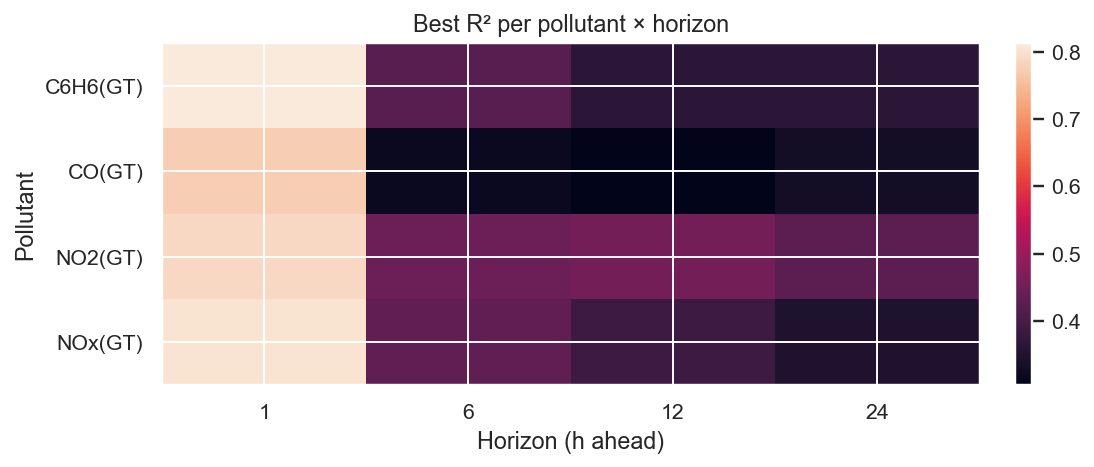

✓ Saved: outputs\figures\analysis\best_R2_heatmap.png


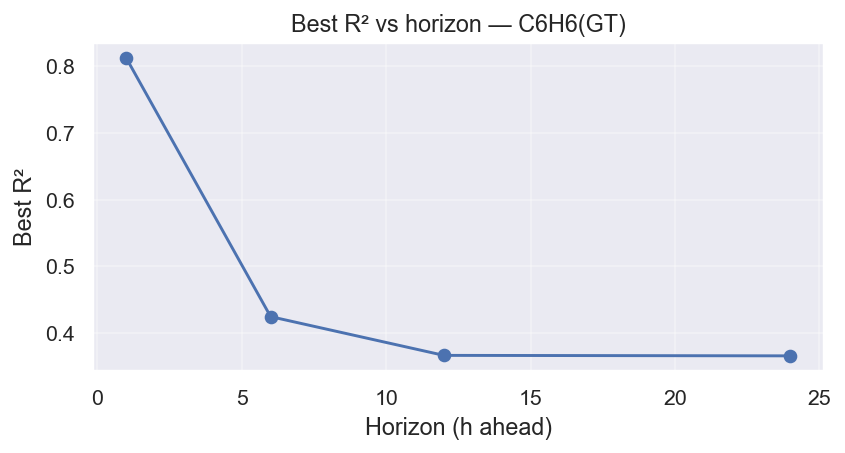

✓ Saved: outputs\figures\analysis\best_R2_curve_C6H6.png


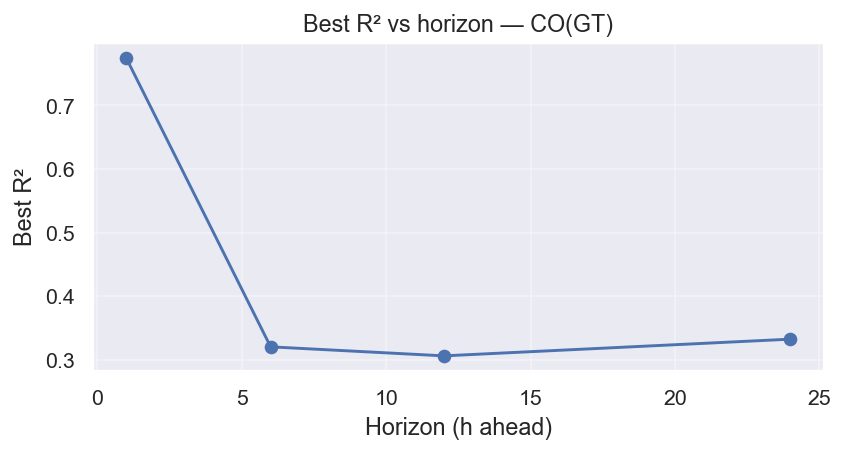

✓ Saved: outputs\figures\analysis\best_R2_curve_CO.png


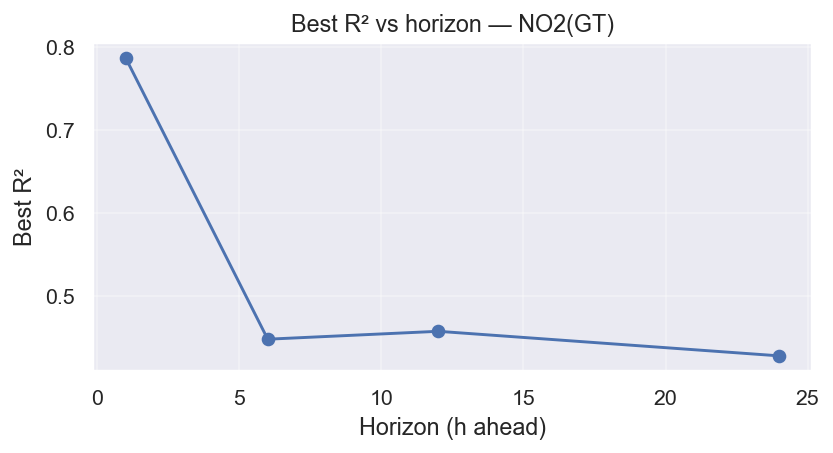

✓ Saved: outputs\figures\analysis\best_R2_curve_NO2.png


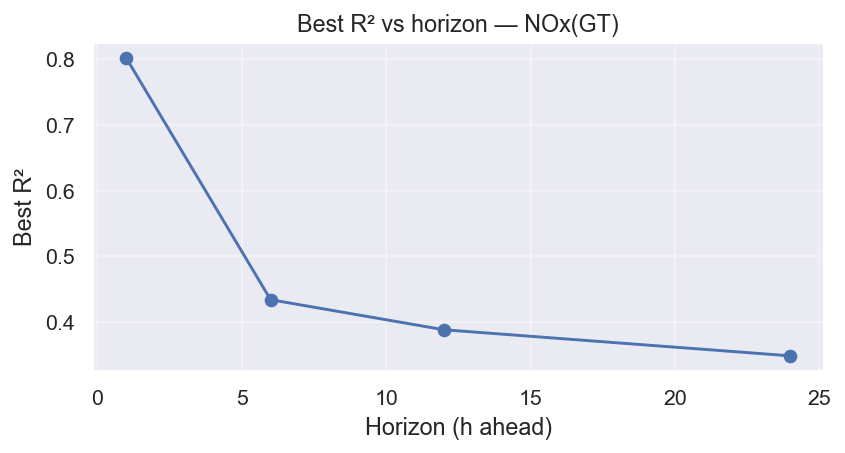

✓ Saved: outputs\figures\analysis\best_R2_curve_NOx.png


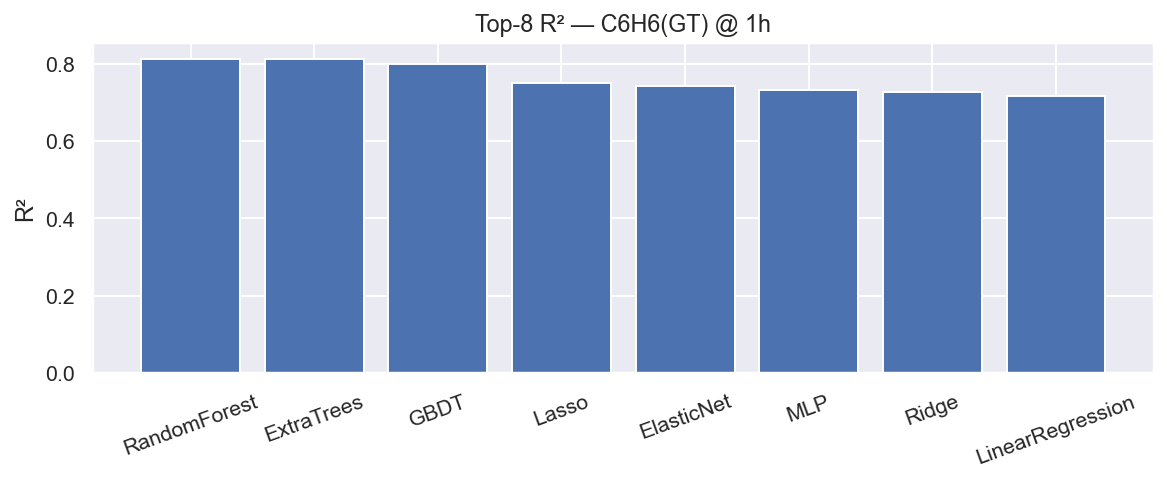

✓ Saved: outputs\figures\analysis\top8_models_C6H6_1h.png


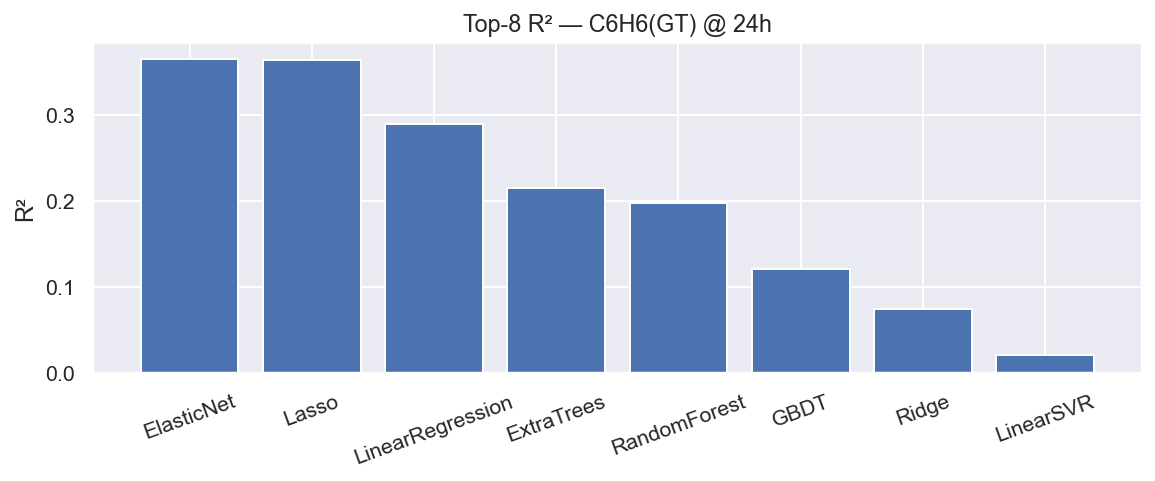

✓ Saved: outputs\figures\analysis\top8_models_C6H6_24h.png


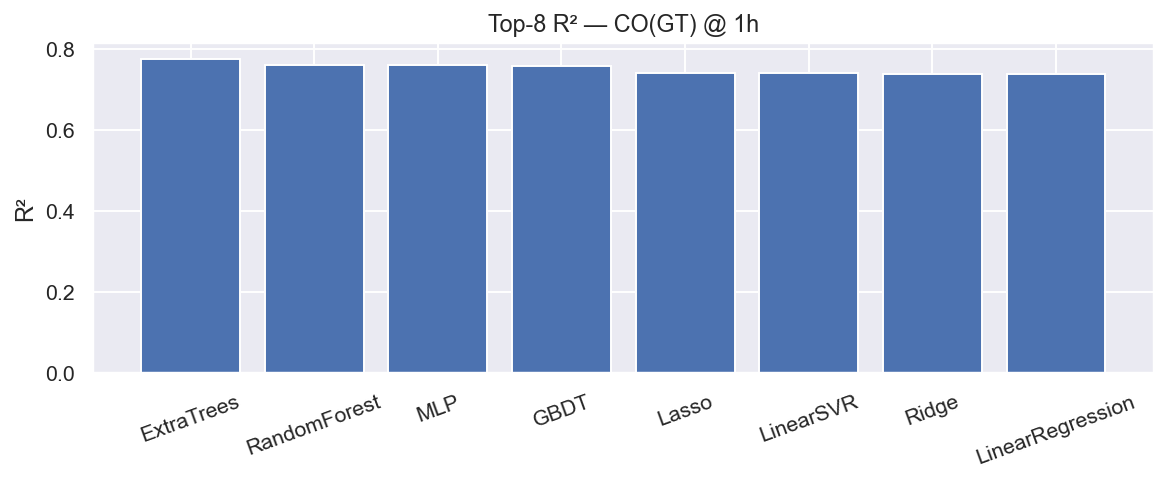

✓ Saved: outputs\figures\analysis\top8_models_CO_1h.png


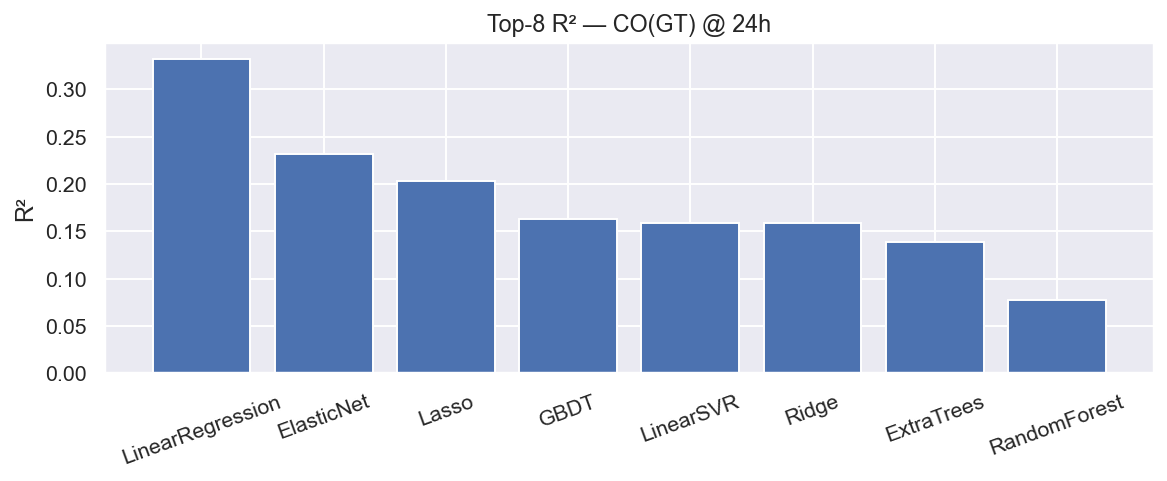

✓ Saved: outputs\figures\analysis\top8_models_CO_24h.png


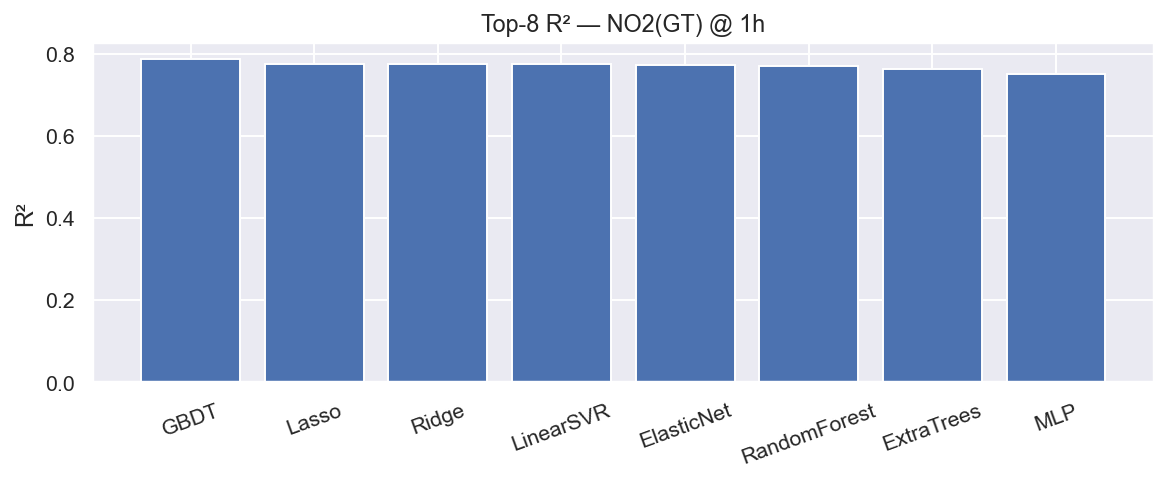

✓ Saved: outputs\figures\analysis\top8_models_NO2_1h.png


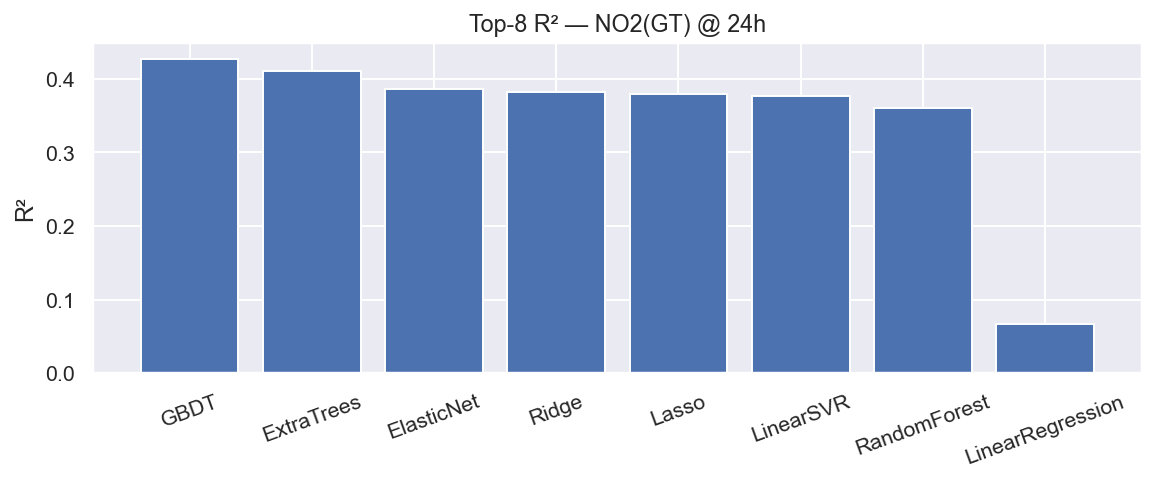

✓ Saved: outputs\figures\analysis\top8_models_NO2_24h.png


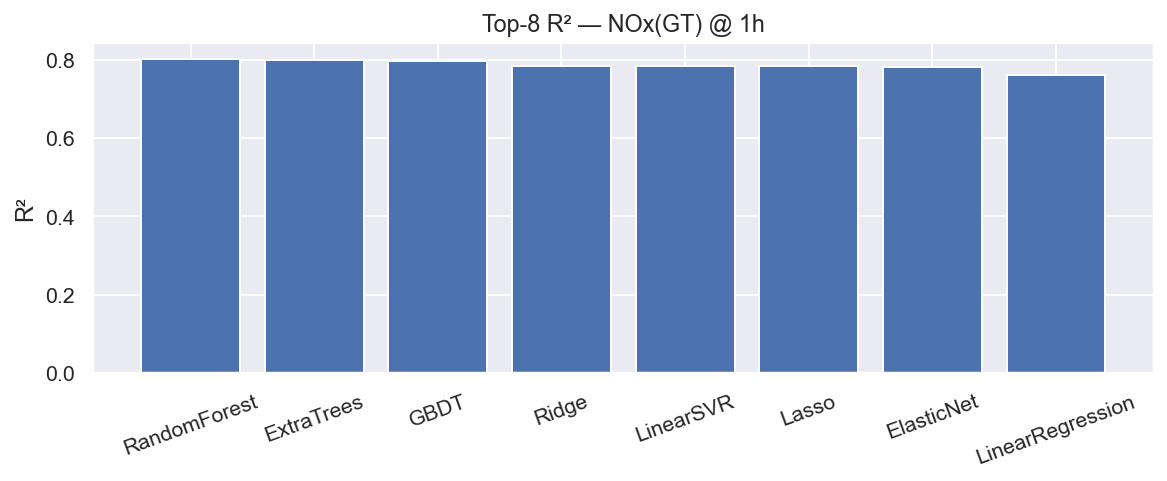

✓ Saved: outputs\figures\analysis\top8_models_NOx_1h.png


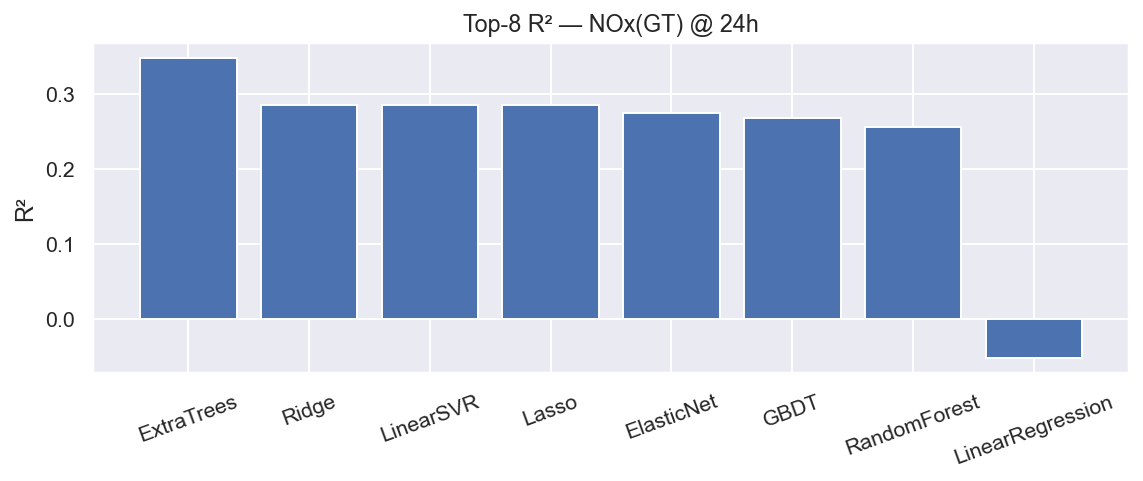

✓ Saved: outputs\figures\analysis\top8_models_NOx_24h.png


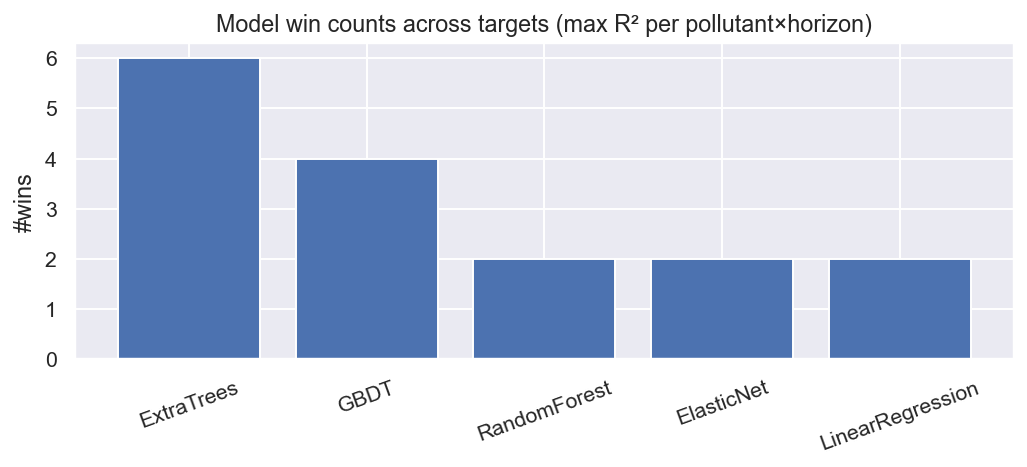

✓ Saved: outputs\figures\analysis\model_win_counts.png


In [20]:
# === Plots: heatmap, per-pollutant horizon curves, top-K bars, win-counts ===
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fig_dir = Path("outputs") / "figures" / "analysis"
fig_dir.mkdir(parents=True, exist_ok=True)

# 0) Try to reuse in-memory results; otherwise load from merged CSV
if "all_results" not in globals() or len(all_results) == 0:
    merged_path = Path("outputs") / "results" / "all_results_merged.csv"
    if not merged_path.exists():
        raise RuntimeError("No all_results in memory, and merged CSV not found. Please run your results cells first.")
    all_results = pd.read_csv(merged_path)

# Basic cleaning
all_results = all_results.copy()
if "horizon_h" not in all_results.columns and "horizon" in all_results.columns:
    all_results["horizon_h"] = (
        all_results["horizon"].astype(str).str.replace("h","",regex=False).astype(int)
    )
all_results["horizon_h"] = all_results["horizon_h"].astype(int)
for c in ["R2","RMSE","MAE","MAPE(%)","fit_time_s"]:
    if c in all_results.columns:
        all_results[c] = pd.to_numeric(all_results[c], errors="coerce")

# Utility: best (max) R² per (pollutant, horizon)
best_R2 = (all_results
           .sort_values(["pollutant","horizon_h","R2"], ascending=[True,True,False])
           .groupby(["pollutant","horizon_h"], as_index=False)
           .head(1))

# 1) Heatmap of best R² (if you’ve already made one, this simply overwrites)
pivot_r2 = best_R2.pivot(index="pollutant", columns="horizon_h", values="R2").sort_index()
plt.figure(figsize=(8, 3.5))
im = plt.imshow(pivot_r2.values, aspect="auto")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(pivot_r2.shape[1]), pivot_r2.columns)
plt.yticks(range(pivot_r2.shape[0]), pivot_r2.index)
plt.title("Best R² per pollutant × horizon")
plt.xlabel("Horizon (h ahead)")
plt.ylabel("Pollutant")
plt.tight_layout()
out_heat = fig_dir / "best_R2_heatmap.png"
plt.savefig(out_heat, dpi=200, bbox_inches="tight")
plt.show()
print(f"✓ Saved: {out_heat}")

# 2) For each pollutant: R² vs horizon (using best across models for each horizon)
for pol in sorted(all_results["pollutant"].unique()):
    sub = best_R2[best_R2["pollutant"] == pol].sort_values("horizon_h")
    if sub.empty: 
        continue
    plt.figure(figsize=(6.2,3.4))
    plt.plot(sub["horizon_h"], sub["R2"], marker="o")
    plt.title(f"Best R² vs horizon — {pol}")
    plt.xlabel("Horizon (h ahead)")
    plt.ylabel("Best R²")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    out = fig_dir / f"best_R2_curve_{pol.replace('(GT)','')}.png"
    plt.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"✓ Saved: {out}")

# 3) Top-K models bar charts for (h in {1, 24}) for each pollutant
TOPK = 8
SELECT_H = [1, 24]
for pol in sorted(all_results["pollutant"].unique()):
    for h in SELECT_H:
        sub = all_results[(all_results["pollutant"]==pol) & (all_results["horizon_h"]==h)].copy()
        if len(sub) < 2: 
            continue
        # keep best per model (some models may appear multiple times with different params)
        sub = (sub.sort_values(["model","R2"], ascending=[True,False])
                 .groupby("model", as_index=False).head(1))
        sub = sub.sort_values("R2", ascending=False).head(TOPK)
        plt.figure(figsize=(8.5,3.6))
        plt.bar(sub["model"], sub["R2"])
        plt.title(f"Top-{TOPK} R² — {pol} @ {h}h")
        plt.ylabel("R²")
        plt.xticks(rotation=20)
        plt.tight_layout()
        out = fig_dir / f"top{TOPK}_models_{pol.replace('(GT)','')}_{h}h.png"
        plt.savefig(out, dpi=200, bbox_inches="tight")
        plt.show()
        print(f"✓ Saved: {out}")

# 4) Model win counts: which model wins most targets (max R² per (pollutant,horizon))
winners = (all_results
           .sort_values(["pollutant","horizon_h","R2"], ascending=[True,True,False])
           .groupby(["pollutant","horizon_h"], as_index=False)
           .head(1))
win_counts = winners["model"].value_counts().reset_index()
win_counts.columns = ["model","wins"]

plt.figure(figsize=(7.5,3.5))
plt.bar(win_counts["model"], win_counts["wins"])
plt.title("Model win counts across targets (max R² per pollutant×horizon)")
plt.ylabel("#wins")
plt.xticks(rotation=20)
plt.tight_layout()
out = fig_dir / "model_win_counts.png"
plt.savefig(out, dpi=200, bbox_inches="tight")
plt.show()
print(f"✓ Saved: {out}")

In [21]:
# --- Patch: robust get_xy that always aligns masks to base features ---
# It reloads immutable "base" X blocks from the prepared pack, so any prior


from pathlib import Path
import numpy as np

# 1) Reload immutable base features (trees pack) for all splits
X_TR_BASE, yreg_tr_base, ycls_tr_base = load_pack(str(PACK_DIR), pack="trees", split="train")
X_VA_BASE, yreg_va_base, ycls_va_base = load_pack(str(PACK_DIR), pack="trees", split="val")
X_TE_BASE, yreg_te_base, ycls_te_base = load_pack(str(PACK_DIR), pack="trees", split="test")

def get_xy(pollutant, horizon, split):
    """
    Return (X_aligned, y_aligned) for given pollutant/horizon/split.
    - Uses immutable base X blocks (X_*_BASE).
    - Applies TARGETS[...][...]['<split>_mask'] to align rows.
    - Drops NaNs in y and mirrors the drop on X.
    - Handles rare length mismatches defensively.
    """
    # choose base X block
    if split == "train":
        X_block = X_TR_BASE
    elif split == "val":
        X_block = X_VA_BASE
    elif split == "test":
        X_block = X_TE_BASE
    else:
        raise ValueError("split must be one of {'train','val','test'}")

    # alignment mask & target vector
    m_align = TARGETS[pollutant][horizon][f"{split}_mask"]
    y_vec   = TARGETS[pollutant][horizon][split]

    # If shapes disagree (e.g., someone overwrote X_* earlier), truncate to min len
    if len(m_align) != len(X_block):
        L = min(len(m_align), len(X_block))
        m_align = m_align[:L]
        # DataFrame vs ndarray handling
        try:
            X_block = X_block.iloc[:L]
        except Exception:
            X_block = X_block[:L]

    # boolean-index X by alignment mask
    try:
        X_aligned = X_block[m_align]
    except Exception:
        # if X_block is ndarray
        X_aligned = X_block[m_align.astype(bool)]

    # drop NaNs in y and mirror on X
    m_nan = np.isfinite(y_vec)
    X_aligned = X_aligned[m_nan]
    y_aligned = y_vec[m_nan]

    # convert to numpy arrays for sklearn
    try:
        X_aligned = X_aligned.values
    except Exception:
        pass

    return X_aligned, y_aligned

print("✓ Patched get_xy(): now uses immutable base features and handles length mismatches.")

✓ Patched get_xy(): now uses immutable base features and handles length mismatches.


In [22]:
!pip install seaborn

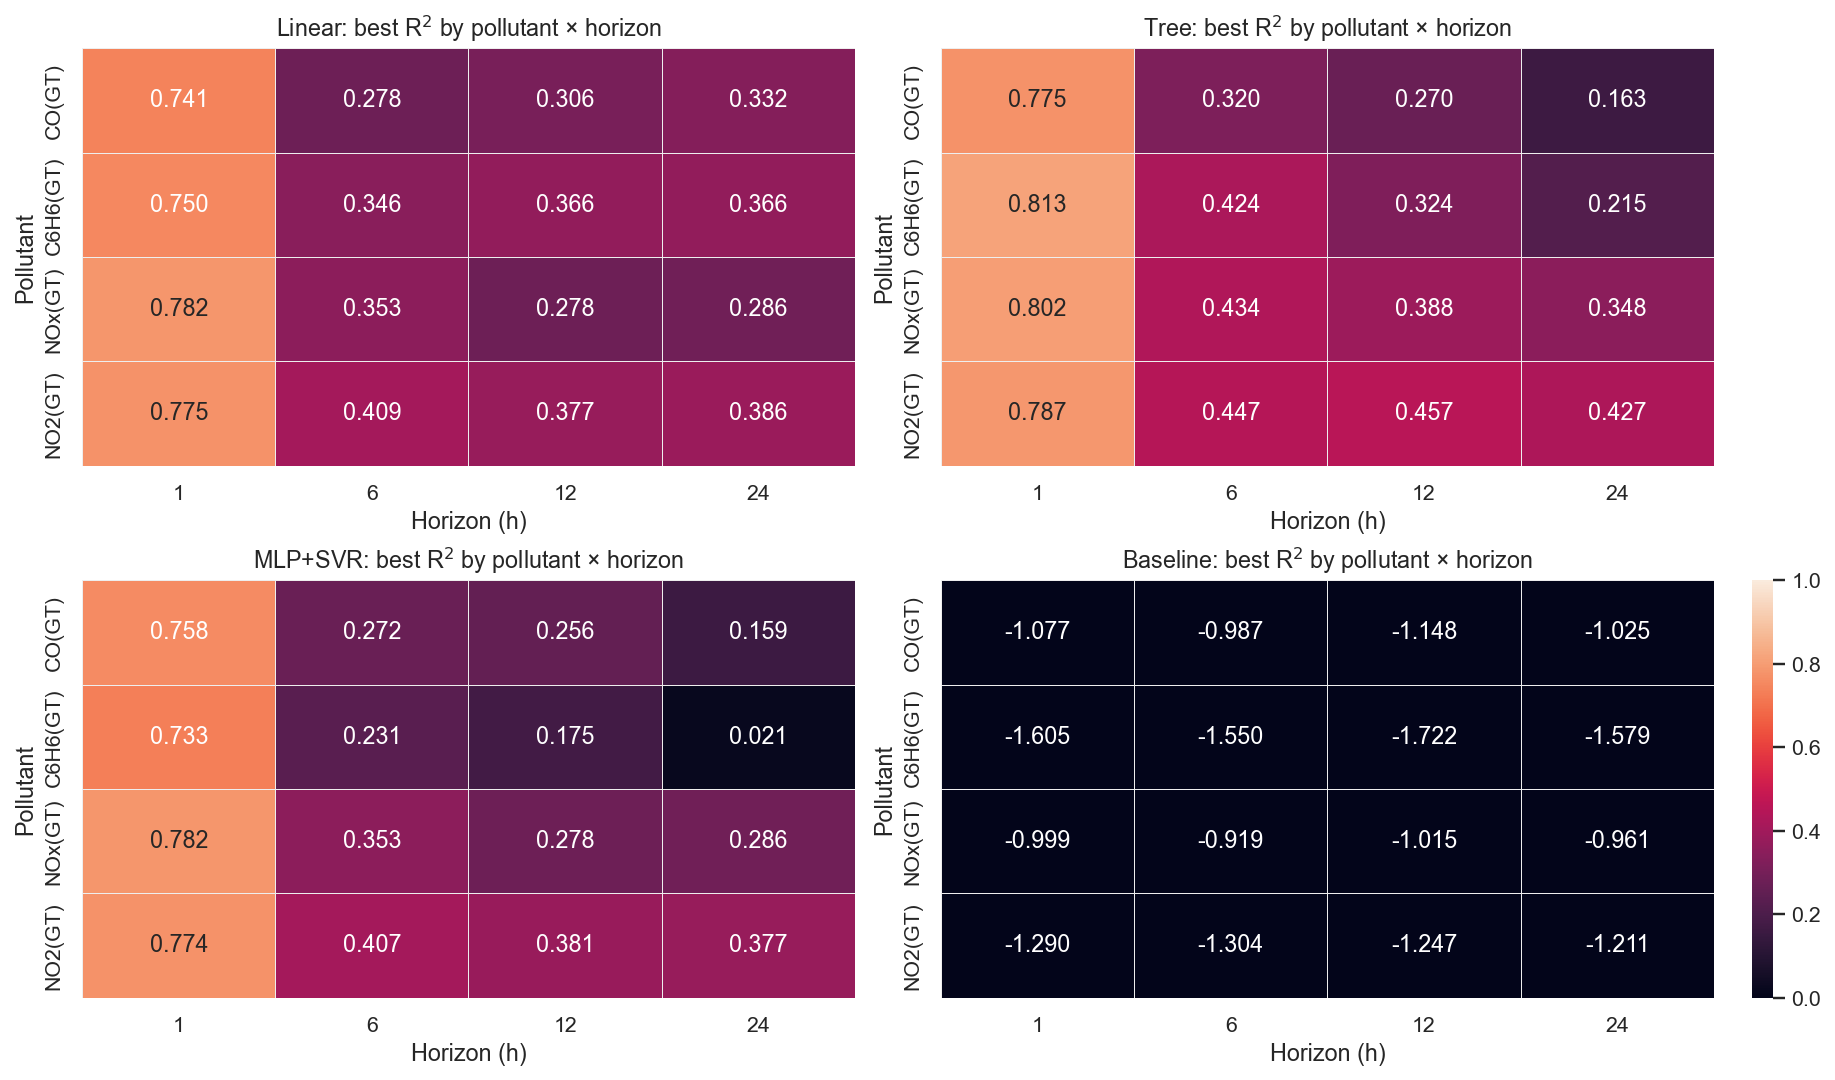

Saved: outputs\figures\performance\perf_heatmaps_by_family.png


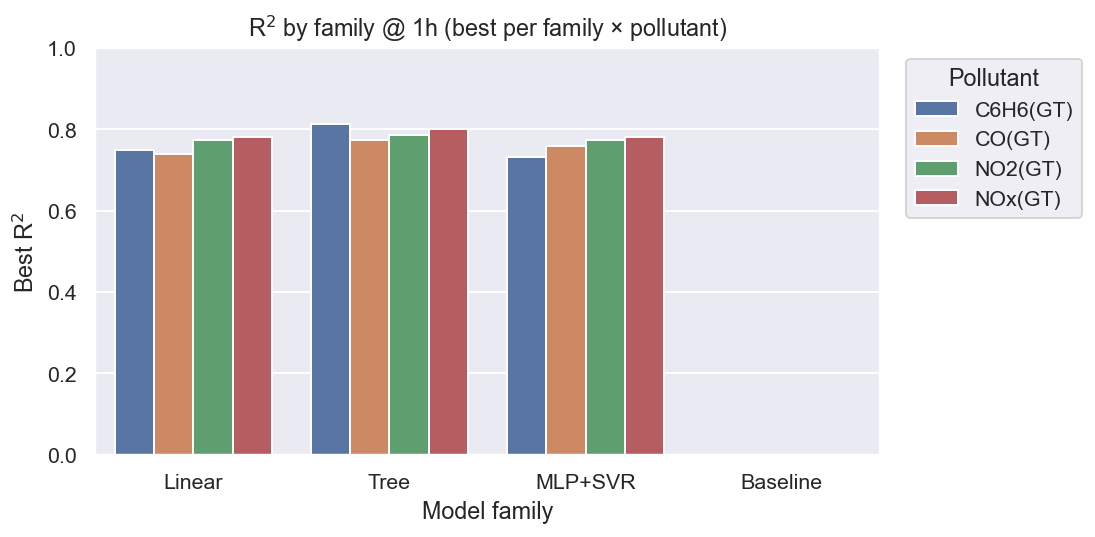

Saved: outputs\figures\performance\perf_bar_by_horizon_1h.png


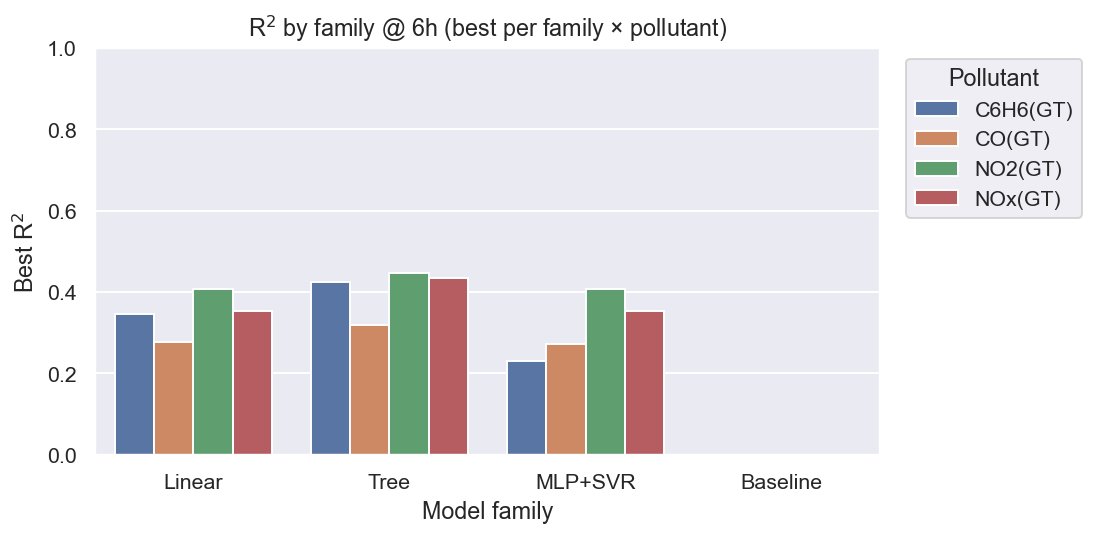

Saved: outputs\figures\performance\perf_bar_by_horizon_6h.png


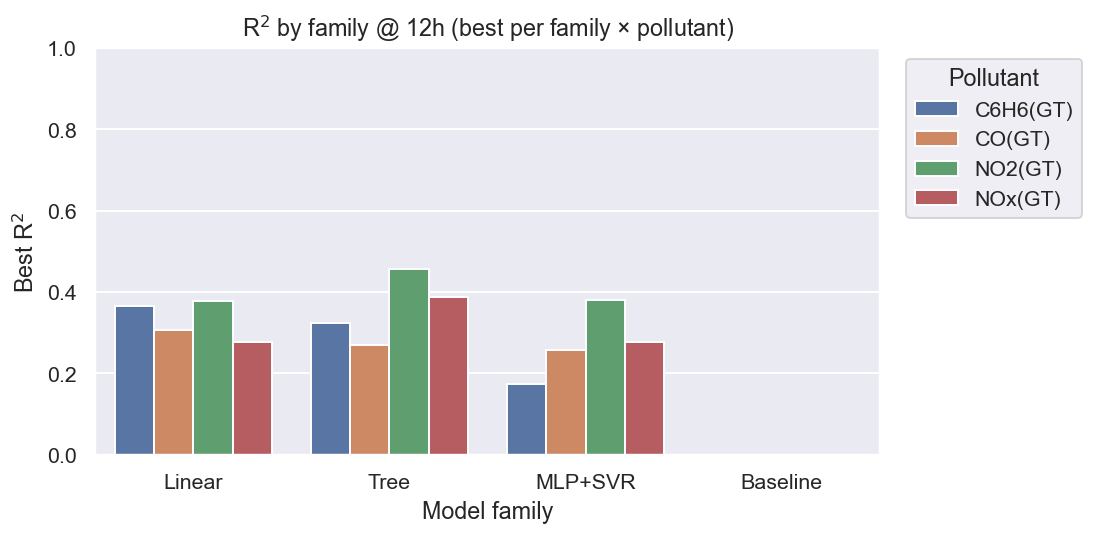

Saved: outputs\figures\performance\perf_bar_by_horizon_12h.png


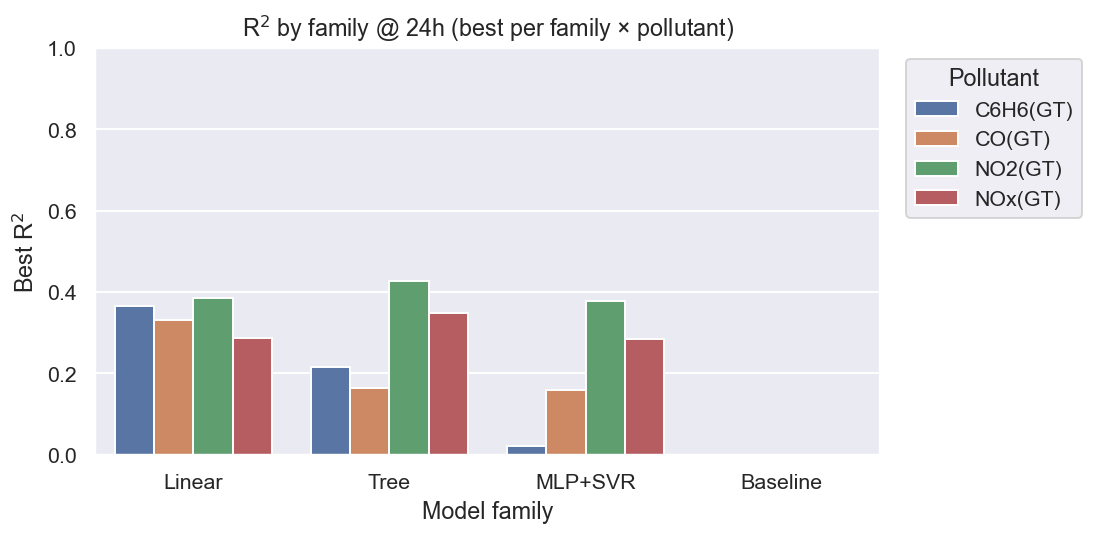

Saved: outputs\figures\performance\perf_bar_by_horizon_24h.png


<Figure size 1400x1120 with 0 Axes>

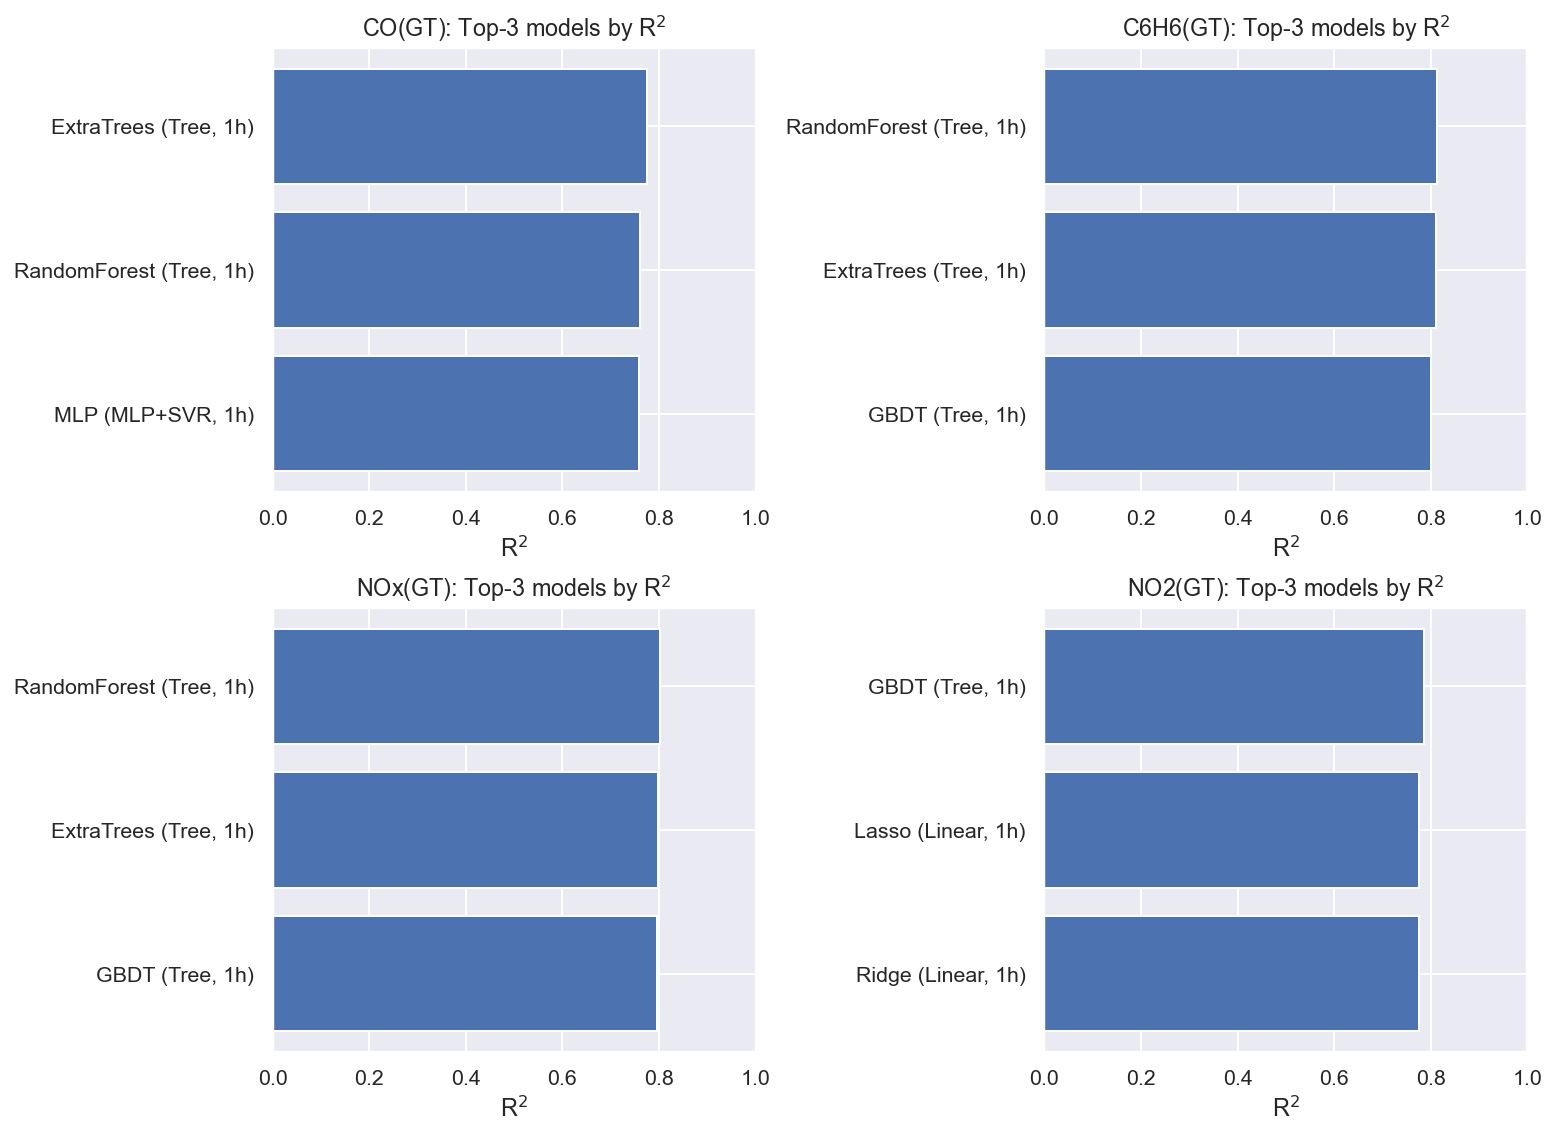

Saved: outputs\figures\performance\top3_models_by_pollutant.png


In [23]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_context("notebook")
plt.rcParams["figure.dpi"] = 140

# --- Helper: load a CSV if it exists ---
def _maybe_read(csv_path):
    p = Path(csv_path)
    if p.exists():
        try:
            df = pd.read_csv(p)
            return df
        except Exception:
            return None
    return None

# --- 1) Gather results from memory or disk ---
dfs = []

# In-memory candidates
if "baseline_df" in globals() and isinstance(baseline_df, pd.DataFrame) and len(baseline_df):
    tmp = baseline_df.copy()
    tmp["family"] = "Baseline"
    # Normalize columns to a common schema
    if "horizon" in tmp.columns and "horizon_h" not in tmp.columns:
        tmp["horizon_h"] = tmp["horizon"].str.replace("h", "", regex=False).astype(int)
    dfs.append(tmp)

if "linear_df" in globals() and isinstance(linear_df, pd.DataFrame) and len(linear_df):
    tmp = linear_df.copy()
    tmp["family"] = "Linear"
    dfs.append(tmp)

if "tree_df" in globals() and isinstance(tree_df, pd.DataFrame) and len(tree_df):
    tmp = tree_df.copy()
    tmp["family"] = "Tree"
    dfs.append(tmp)

if "mlp_svr_df" in globals() and isinstance(mlp_svr_df, pd.DataFrame) and len(mlp_svr_df):
    tmp = mlp_svr_df.copy()
    tmp["family"] = np.where(tmp["model"].str.contains("MLP"), "MLP+SVR",
                    np.where(tmp["model"].str.contains("SVR"), "MLP+SVR", "MLP+SVR"))
    dfs.append(tmp)

# Disk fallbacks (if some tables are not in memory)
if not any(d.get("family", pd.Series([])).eq("Baseline").any() for d in dfs):
    d = _maybe_read("outputs/results/baseline_results.csv")
    if d is not None and len(d):
        d["family"] = "Baseline"
        if "horizon" in d.columns and "horizon_h" not in d.columns:
            d["horizon_h"] = d["horizon"].str.replace("h", "", regex=False).astype(int)
        dfs.append(d)

if not any(d.get("family", pd.Series([])).eq("Linear").any() for d in dfs):
    d = _maybe_read("outputs/results/linear_results.csv")
    if d is not None and len(d):
        d["family"] = "Linear"
        dfs.append(d)

if not any(d.get("family", pd.Series([])).eq("Tree").any() for d in dfs):
    d = _maybe_read("outputs/results/tree_results.csv")
    if d is not None and len(d):
        d["family"] = "Tree"
        dfs.append(d)

# mlp/svr official saved by previous cell as mlp_svr_results.csv
if not any(d.get("family", pd.Series([])).eq("MLP+SVR").any() for d in dfs):
    d = _maybe_read("outputs/results/mlp_svr_results.csv")
    if d is not None and len(d):
        d["family"] = np.where(d["model"].str.contains("MLP"), "MLP+SVR",
                        np.where(d["model"].str.contains("SVR"), "MLP+SVR", "MLP+SVR"))
        dfs.append(d)

if not dfs:
    raise RuntimeError("No results found in memory or outputs/results/*.csv. Please run your model cells first.")

all_res = pd.concat(dfs, ignore_index=True)

# --- 2) Harmonize columns ---
# Expect at least: ['model','pollutant','horizon_h','RMSE','MAE','R2','family']
# Some sources may have 'MAPE(%)' vs 'MAPE'—we won't use it here.
# Ensure numeric types
for col in ["horizon_h", "RMSE", "MAE", "R2"]:
    if col in all_res.columns:
        all_res[col] = pd.to_numeric(all_res[col], errors="coerce")

# Clean pollutant order and horizon order for consistent plots
pollutant_order = ["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)"]
pollutant_order = [p for p in pollutant_order if p in all_res["pollutant"].unique()]
horizon_order = [1, 6, 12, 24]

# --- 3) Ensure output directory ---
outdir = Path("outputs/figures/performance")
outdir.mkdir(parents=True, exist_ok=True)

# --- A1) Family-level R^2 heatmaps: one heatmap per family ---
families = ["Linear", "Tree", "MLP+SVR", "Baseline"]
families = [f for f in families if f in all_res["family"].unique()]

# Aggregate to best R^2 per (pollutant, horizon) within each family
def best_by_family(df, fam):
    d = df[df["family"] == fam].copy()
    if d.empty:
        return None
    g = (d.groupby(["pollutant", "horizon_h"], as_index=False)
           .agg(best_R2=("R2", "max")))
    # Pivot to heatmap table
    pivot = g.pivot(index="pollutant", columns="horizon_h", values="best_R2")
    # Reindex for consistent ordering
    pivot = pivot.reindex(index=pollutant_order, columns=horizon_order)
    return pivot

# Draw a multi-panel figure of heatmaps (up to 4 families)
n = len(families)
ncols = min(2, n)
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6.5*ncols, 3.8*nrows), constrained_layout=True)
axes = np.array(axes).reshape(nrows, ncols)

for i, fam in enumerate(families):
    r, c = divmod(i, ncols)
    ax = axes[r, c]
    pivot = best_by_family(all_res, fam)
    if pivot is None:
        ax.axis("off")
        continue
    sns.heatmap(pivot, ax=ax, annot=True, fmt=".3f", vmin=0.0, vmax=1.0, cbar=(i==n-1),
                linewidths=0.5, linecolor="#eee")
    ax.set_title(f"{fam}: best R$^2$ by pollutant × horizon")
    ax.set_xlabel("Horizon (h)")
    ax.set_ylabel("Pollutant")
# Hide any leftover axes
for j in range(i+1, nrows*ncols):
    axes.flat[j].axis("off")

save_path = outdir / "perf_heatmaps_by_family.png"
fig.savefig(save_path, dpi=300)
plt.show()
print(f"Saved: {save_path}")

# --- A2) Per-horizon bar charts: bars=family, hue=pollutant; metric=best R^2 per family ---
# Build a compact table: for each horizon & family & pollutant, best R^2
grp = (all_res.groupby(["horizon_h", "family", "pollutant"], as_index=False)
             .agg(R2=("R2", "max")))
grp = grp[grp["horizon_h"].isin(horizon_order)]
grp["horizon_h"] = pd.Categorical(grp["horizon_h"], categories=horizon_order, ordered=True)

for h in horizon_order:
    d = grp[grp["horizon_h"] == h].copy()
    if d.empty:
        continue
    plt.figure(figsize=(8, 4))
    # Order families consistently
    fam_order = ["Linear", "Tree", "MLP+SVR", "Baseline"]
    fam_order = [f for f in fam_order if f in d["family"].unique()]
    sns.barplot(data=d, x="family", y="R2", hue="pollutant", order=fam_order)
    plt.ylim(0, 1.0)
    plt.title(f"R$^2$ by family @ {h}h (best per family × pollutant)")
    plt.xlabel("Model family")
    plt.ylabel("Best R$^2$")
    plt.legend(title="Pollutant", bbox_to_anchor=(1.02, 1), loc="upper left")
    p = outdir / f"perf_bar_by_horizon_{h}h.png"
    plt.tight_layout()
    plt.savefig(p, dpi=300)
    plt.show()
    print(f"Saved: {p}")

# --- A3) Top-3 models by R^2 for each pollutant (overall, across all families) ---
# For each pollutant: keep top-3 rows by R2 (breaking ties by horizon then family)
plt.figure(figsize=(10, 8))
axs = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)[1].ravel()

for i, pollutant in enumerate(pollutant_order[:4]):  # 2×2 grid for up to 4 pollutants
    ax = axs[i]
    dd = all_res[all_res["pollutant"] == pollutant].copy()
    if dd.empty:
        ax.axis("off")
        continue
    # collapse by specific model×horizon to its best R^2 (in case duplicate rows exist)
    dd = (dd.groupby(["model", "family", "horizon_h"], as_index=False)
             .agg(R2=("R2", "max")))
    # pick top-3 overall
    top3 = dd.sort_values(["R2", "horizon_h"], ascending=[False, True]).head(3)
    # Build a label "model (family, h=?h)"
    top3["label"] = top3.apply(lambda r: f"{r['model']} ({r['family']}, {int(r['horizon_h'])}h)", axis=1)
    top3 = top3.sort_values("R2", ascending=True)  # so bars grow upward
    ax.barh(top3["label"], top3["R2"])
    ax.set_xlim(0, 1.0)
    ax.set_title(f"{pollutant}: Top-3 models by R$^2$")
    ax.set_xlabel("R$^2$")
    ax.set_ylabel("")
# If fewer than 4 pollutants, hide extra axes
for j in range(i+1, len(axs)):
    axs[j].axis("off")

p = outdir / "top3_models_by_pollutant.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"Saved: {p}")

Light tuning: RandomForest & GradientBoosting (TimeSeriesSplit cv=3, scoring=R^2)
H_TUNE = [1, 24]
POLLUTANTS = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']

Pollutant: CO(GT)
   1h | RF*   R²=0.778  RMSE=0.623  MAE=0.449  time=170.7s  params={'max_depth': 20, 'max_features': 0.6, 'min_samples_leaf': 5, 'n_estimators': 300, 'n_jobs': -1, 'random_state': 42}
   1h | GBDT* R²=0.768  RMSE=0.637  MAE=0.466  time=402.8s  params={'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 5, 'n_estimators': 300, 'random_state': 42, 'subsample': 1.0}
  24h | RF*   R²=0.147  RMSE=1.224  MAE=0.960  time=169.7s  params={'max_depth': 12, 'max_features': 0.6, 'min_samples_leaf': 5, 'n_estimators': 300, 'n_jobs': -1, 'random_state': 42}
  24h | GBDT* R²=0.167  RMSE=1.210  MAE=0.944  time=398.5s  params={'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 1, 'n_estimators': 300, 'random_state': 42, 'subsample': 0.8}

Pollutant: C6H6(GT)
   1h | RF*   R²=0.817  RMSE=2.726  MAE=1.787  time=165.5

,pollutant,horizon_h,model,R2,RMSE,MAE,MAPE(%),fit_time_s,best_params,n_train,n_test
0,C6H6(GT),1,RandomForest_TUNED,0.817181,2.725796,1.786811,33.095021,165.500481,"{'max_depth': 12, 'max_features': 0.6, 'min_sa...",7086,2246
1,C6H6(GT),1,GBDT_TUNED,0.810435,2.775638,1.877813,38.282471,418.580417,"{'learning_rate': 0.05, 'max_depth': 3, 'min_s...",7086,2246
2,CO(GT),1,RandomForest_TUNED,0.778005,0.622587,0.449356,42.220897,170.667731,"{'max_depth': 20, 'max_features': 0.6, 'min_sa...",7086,2246
3,CO(GT),1,GBDT_TUNED,0.767710,0.636860,0.465815,42.837359,402.753101,"{'learning_rate': 0.05, 'max_depth': 2, 'min_s...",7086,2246
4,NO2(GT),1,GBDT_TUNED,0.791076,22.816226,16.786236,14.078328,313.778357,"{'learning_rate': 0.05, 'max_depth': 3, 'min_s...",7086,2246
5,NO2(GT),1,RandomForest_TUNED,0.768184,24.033720,17.430638,13.802167,104.566341,"{'max_depth': 12, 'max_features': 0.6, 'min_sa...",7086,2246
6,NOx(GT),1,RandomForest_TUNED,0.810661,84.930459,60.748397,25.088306,175.413854,"{'max_depth': 12, 'max_features': 0.6, 'min_sa...",7086,2246
7,NOx(GT),1,GBDT_TUNED,0.794543,88.471706,63.881089,27.446041,340.162521,"{'learning_rate': 0.05, 'max_depth': 2, 'min_s...",7086,2246
8,C6H6(GT),24,RandomForest_TUNED,0.284042,5.415205,4.286485,115.289363,165.521827,"{'max_depth': 12, 'max_features': 0.6, 'min_sa...",7086,2223
9,C6H6(GT),24,GBDT_TUNED,0.148952,5.904026,4.660179,140.459783,406.232445,"{'learning_rate': 0.05, 'max_depth': 2, 'min_s...",7086,2223


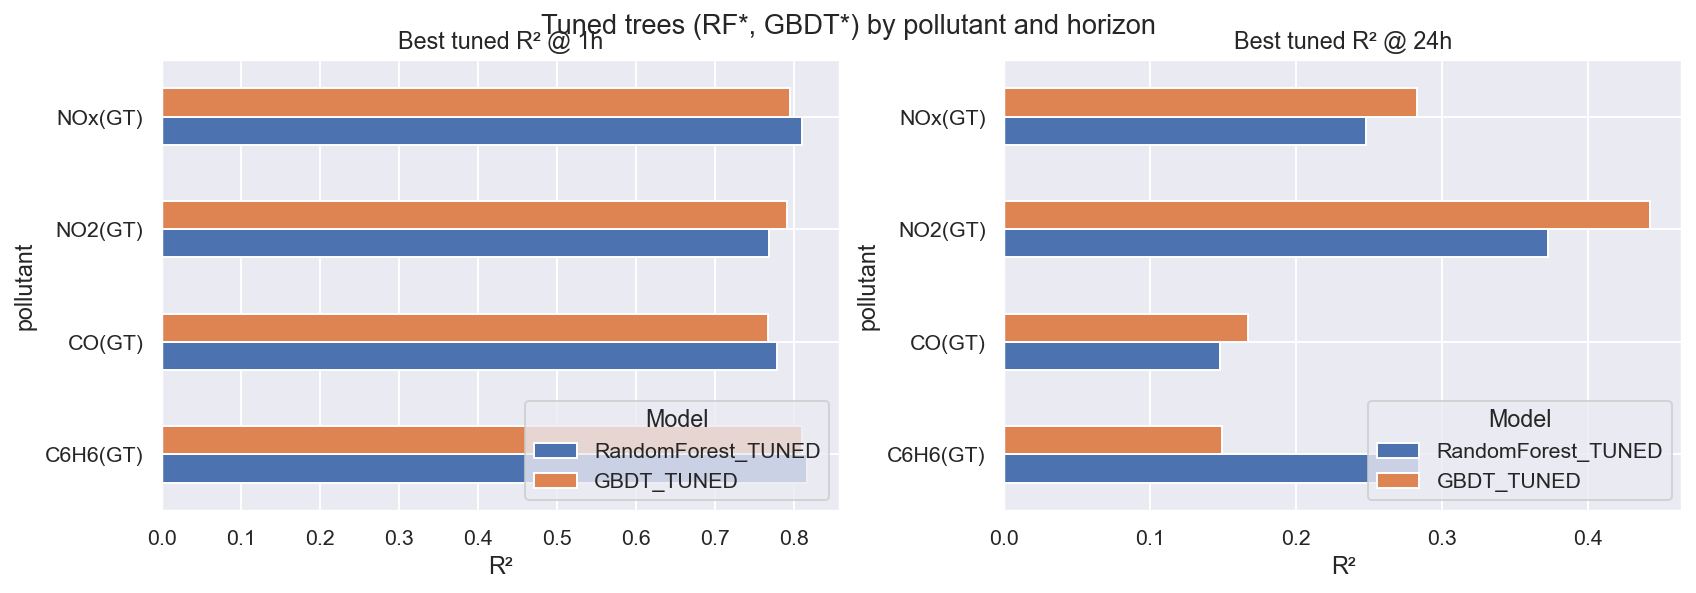

Figure saved to: C:\Users\20100\Downloads\COMP9417_GoodJob-main\COMP9417_GoodJob-main\outputs\figs\tuned_trees_summary.png


In [24]:
# Light tuning for RandomForest & GradientBoosting on short/long horizons.
# - Uses TimeSeriesSplit(cv=3) on (train+val) to respect temporal order
# - Evaluates once on test
# - Saves: CSV (metrics + best_params) and pickles (best models)
# - Produces a single compact comparison figure at the bottom (all-in-one)
#
# Tip: change H_TUNE to [1, 6, 12, 24] if you want to tune all horizons.

import os, json, pickle, time, numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# Define pollutants (same as in previous cells)
POLLUTANTS = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']

H_TUNE = [1, 24]          # change to [1, 6, 12, 24] if needed
SEED   = 42
np.random.seed(SEED)

OUT_DIR = Path("outputs")
(OUT_DIR / "results").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "models").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "figs").mkdir(parents=True, exist_ok=True)

# ------------------------ Helper functions ---------------------
# Define get_xy function (copied from previous cells)
def get_xy(pollutant: str, horizon: int, split: str):
    """
    Return (X_subset, y_subset) aligned for the given pollutant, horizon, and split.
    split in {'train','val','test'}
    """
    # These should be defined in your environment from previous cells
    # If not, you'll need to define X_tr, X_va, X_te and TARGETS here too
    assert pollutant in TARGETS and horizon in TARGETS[pollutant], "Unknown pollutant or horizon"
    masks = TARGETS[pollutant][horizon]
    
    if split == 'train':
        Xb = X_tr
        yb = masks['train']
        mb = masks['train_mask']
    elif split == 'val':
        Xb = X_va
        yb = masks['val']
        mb = masks['val_mask']
    elif split == 'test':
        Xb = X_te
        yb = masks['test']
        mb = masks['test_mask']
    else:
        raise ValueError("split must be one of {'train','val','test'}")

    # Align X by boolean mask; y is already filtered
    if isinstance(Xb, pd.DataFrame):
        X_aligned = Xb[mb]
    else:
        X_aligned = Xb[mb]
            
    return X_aligned, yb

# Small, safe grids (kept tight to control run time)
RF_GRID = {
    "n_estimators": [300, 600],
    "max_depth": [None, 12, 20],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", 0.6],
    "random_state": [SEED],
    "n_jobs": [-1],
}
GBDT_GRID = {
    "n_estimators": [300, 600],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [1.0, 0.8],
    "min_samples_leaf": [1, 2, 5],
    "random_state": [SEED],
}

# ------------------------ Metrics helpers ---------------------
def _rmse(y_true, y_pred):
    m = ~(np.isnan(y_true) | np.isnan(y_pred))
    return np.sqrt(mean_squared_error(y_true[m], y_pred[m])) if m.any() else np.nan

def _mae(y_true, y_pred):
    m = ~(np.isnan(y_true) | np.isnan(y_pred))
    return mean_absolute_error(y_true[m], y_pred[m]) if m.any() else np.nan

def _mape(y_true, y_pred):
    m = ~(np.isnan(y_true) | np.isnan(y_pred)) & (y_true != 0)
    return (np.mean(np.abs((y_true[m] - y_pred[m]) / y_true[m])) * 100) if m.any() else np.nan

# ------------------------- Run tuning -------------------------
tscv = TimeSeriesSplit(n_splits=3)  # chronological CV on (train+val)
results = []
print("="*68)
print("Light tuning: RandomForest & GradientBoosting (TimeSeriesSplit cv=3, scoring=R^2)")
print("H_TUNE =", H_TUNE)
print("POLLUTANTS =", POLLUTANTS)
print("="*68)

# Check if required variables exist
required_vars = ['X_tr', 'X_va', 'X_te', 'TARGETS']
missing_vars = [var for var in required_vars if var not in globals()]
if missing_vars:
    print(f"WARNING: Missing variables: {missing_vars}")
    print("Please run the data preparation cells first.")

for pollutant in POLLUTANTS:
    print(f"\nPollutant: {pollutant}")
    for h in H_TUNE:
        try:
            # 1) fetch aligned data (train/val/test)
            X_tr_data, y_tr = get_xy(pollutant, h, "train")
            X_va_data, y_va = get_xy(pollutant, h, "val")
            X_te_data, y_te = get_xy(pollutant, h, "test")

            # 2) concat train + val for model selection
            X_fit = np.vstack([X_tr_data, X_va_data])
            y_fit = np.hstack([y_tr, y_va])

            # ---------------- RandomForest ----------------
            rf = RandomForestRegressor()
            rf_cv = GridSearchCV(
                rf, RF_GRID, cv=tscv, scoring="r2", n_jobs=-1, refit=True, verbose=0
            )
            t0 = time.time()
            rf_cv.fit(X_fit, y_fit)
            rf_time = time.time() - t0

            rf_best = rf_cv.best_estimator_
            rf_pred = rf_best.predict(X_te_data)
            rf_row = {
                "pollutant": pollutant,
                "horizon_h": h,
                "model": "RandomForest_TUNED",
                "R2": r2_score(y_te, rf_pred),
                "RMSE": _rmse(y_te, rf_pred),
                "MAE": _mae(y_te, rf_pred),
                "MAPE(%)": _mape(y_te, rf_pred),
                "fit_time_s": rf_time,
                "best_params": rf_cv.best_params_,
                "n_train": int(len(y_fit)),
                "n_test": int(len(y_te)),
            }
            results.append(rf_row)
            print(f"  {h:>2}h | RF*   R²={rf_row['R2']:.3f}  RMSE={rf_row['RMSE']:.3f}  "
                  f"MAE={rf_row['MAE']:.3f}  time={rf_time:.1f}s  params={rf_cv.best_params_}")

            # save model
            safe_p = pollutant.replace("/", "-")
            with open(OUT_DIR / "models" / f"{safe_p}_{h}h_RF.pkl", "wb") as f:
                pickle.dump(rf_best, f)

            # ---------------- GradientBoosting ----------------
            gbdt = GradientBoostingRegressor()
            gbdt_cv = GridSearchCV(
                gbdt, GBDT_GRID, cv=tscv, scoring="r2", n_jobs=-1, refit=True, verbose=0
            )
            t0 = time.time()
            gbdt_cv.fit(X_fit, y_fit)
            gb_time = time.time() - t0

            gb_best = gbdt_cv.best_estimator_
            gb_pred = gb_best.predict(X_te_data)
            gb_row = {
                "pollutant": pollutant,
                "horizon_h": h,
                "model": "GBDT_TUNED",
                "R2": r2_score(y_te, gb_pred),
                "RMSE": _rmse(y_te, gb_pred),
                "MAE": _mae(y_te, gb_pred),
                "MAPE(%)": _mape(y_te, gb_pred),
                "fit_time_s": gb_time,
                "best_params": gbdt_cv.best_params_,
                "n_train": int(len(y_fit)),
                "n_test": int(len(y_te)),
            }
            results.append(gb_row)
            print(f"  {h:>2}h | GBDT* R²={gb_row['R2']:.3f}  RMSE={gb_row['RMSE']:.3f}  "
                  f"MAE={gb_row['MAE']:.3f}  time={gb_time:.1f}s  params={gb_row['best_params']}")

            with open(OUT_DIR / "models" / f"{safe_p}_{h}h_GBDT.pkl", "wb") as f:
                pickle.dump(gb_best, f)
                
        except Exception as e:
            print(f"  {h:>2}h | ERROR: {e}")
            continue

# ---------------------- Save + Leaderboard --------------------
if results:
    tuned_df = pd.DataFrame(results)
    tuned_path = OUT_DIR / "results" / "tuned_tree_results.csv"
    tuned_df.to_csv(tuned_path, index=False)
    print("\nSaved:", tuned_path.resolve())

    display(
        tuned_df.sort_values(["horizon_h", "pollutant", "R2"], ascending=[True, True, False])
                .reset_index(drop=True)
    )

    # ----------------- One-shot summary figure (bottom) -----------
    # One canvas that compares RF* vs GBDT* for each pollutant at the tuned horizons
    if len(tuned_df):
        fig, axes = plt.subplots(1, len(H_TUNE), figsize=(6*len(H_TUNE), 4), constrained_layout=True)
        if len(H_TUNE) == 1:
            axes = [axes]
        for ax, h in zip(axes, H_TUNE):
            sub = tuned_df[tuned_df["horizon_h"] == h].copy()
            # pivot to wide: rows=pollutant, cols=model, values=R2
            pv = sub.pivot(index="pollutant", columns="model", values="R2")
            pv = pv[["RandomForest_TUNED", "GBDT_TUNED"]]  # consistent order
            pv.plot(kind="barh", ax=ax)
            ax.set_title(f"Best tuned R² @ {h}h")
            ax.set_xlabel("R²")
            ax.legend(title="Model", loc="lower right")
        fig.suptitle("Tuned trees (RF*, GBDT*) by pollutant and horizon", y=1.02, fontsize=14)
        fig_path = OUT_DIR / "figs" / "tuned_trees_summary.png"
        plt.savefig(fig_path, dpi=150, bbox_inches="tight")
        plt.show()
        print("Figure saved to:", fig_path.resolve())
else:
    print("No results generated. Please check if data preparation cells were run.")

In [26]:
# Light tuning (6h & 12h): RandomForest / GradientBoosting with TimeSeriesSplit
# - Same setting as 1h/24h tuning, now for 6h and 12h
# - Uses your get_xy(pollutant, horizon, split) helper (positional args)
# - Saves CSV and pickled best models

import os, pickle, time, numpy as np, pandas as pd
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---- Config ----
H_TUNE = [6, 12]    # this cell tunes 6h and 12h
SEED   = 42
OUT_DIR = Path("outputs")
(OUT_DIR / "results").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "models").mkdir(parents=True, exist_ok=True)

# ---- Robust get_xy function with length checking ----
def get_xy_robust(pollutant: str, horizon: int, split: str):
    """
    Robust version of get_xy that handles length mismatches
    """
    assert pollutant in TARGETS and horizon in TARGETS[pollutant], "Unknown pollutant or horizon"
    masks = TARGETS[pollutant][horizon]
    
    if split == 'train':
        Xb = X_tr
        yb = masks['train']
        mb = masks['train_mask']
    elif split == 'val':
        Xb = X_va
        yb = masks['val']
        mb = masks['val_mask']
    elif split == 'test':
        Xb = X_te
        yb = masks['test']
        mb = masks['test_mask']
    else:
        raise ValueError("split must be one of {'train','val','test'}")

    # Handle length mismatches
    if len(mb) != len(Xb):
        print(f"  WARNING: Mask length ({len(mb)}) != X length ({len(Xb)}) for {pollutant} @ {horizon}h")
        # Truncate to the minimum length
        min_len = min(len(mb), len(Xb))
        mb = mb[:min_len]
        if isinstance(Xb, pd.DataFrame):
            X_aligned = Xb.iloc[:min_len][mb]
        else:
            X_aligned = Xb[:min_len][mb]
    else:
        # Normal case: lengths match
        if isinstance(Xb, pd.DataFrame):
            X_aligned = Xb[mb]
        else:
            X_aligned = Xb[mb]
            
    return X_aligned, yb

# Small, safe grids kept tight to control wall time (same style as before)
RF_GRID = {
    "n_estimators": [300, 600],
    "max_depth": [None, 12, 20],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", 0.6],
    "random_state": [SEED],
    "n_jobs": [-1],
}
GBDT_GRID = {
    "n_estimators": [300, 600],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [1.0, 0.8],
    "min_samples_leaf": [1, 2, 5],
    "random_state": [SEED],
}

def _rmse(y_true, y_pred):
    m = ~(np.isnan(y_true) | np.isnan(y_pred))
    return np.sqrt(mean_squared_error(y_true[m], y_pred[m])) if m.any() else np.nan

def _mae(y_true, y_pred):
    m = ~(np.isnan(y_true) | np.isnan(y_pred))
    return mean_absolute_error(y_true[m], y_pred[m]) if m.any() else np.nan

def _mape(y_true, y_pred):
    m = ~(np.isnan(y_true) | np.isnan(y_pred)) & (y_true != 0)
    return (np.mean(np.abs((y_true[m] - y_pred[m]) / y_true[m])) * 100) if m.any() else np.nan

tscv = TimeSeriesSplit(n_splits=3)
rows = []

print("="*68)
print("Light tuning: RandomForest & GradientBoosting (TimeSeriesSplit cv=3, scoring=R^2)")
print("H_TUNE =", H_TUNE)
print("="*68)

for pollutant in POLLUTANTS:
    print(f"\nPollutant: {pollutant}")
    for h in H_TUNE:
        try:
            # --- fetch aligned data (train/val/test) using robust function ---
            X_tr_data, y_tr = get_xy_robust(pollutant, h, "train")
            X_va_data, y_va = get_xy_robust(pollutant, h, "val")
            X_te_data, y_te = get_xy_robust(pollutant, h, "test")

            # Check if we have enough data
            if len(y_tr) == 0 or len(y_va) == 0 or len(y_te) == 0:
                print(f"  {h:>2}h: insufficient data, skip")
                continue

            # concat train + val for model selection on in-sample folds
            X_fit = np.vstack([X_tr_data, X_va_data])
            y_fit = np.hstack([y_tr, y_va])

            # ---------------- RandomForest ----------------
            rf = RandomForestRegressor()
            rf_cv = GridSearchCV(
                rf, RF_GRID, cv=tscv, scoring="r2", n_jobs=-1, refit=True, verbose=0
            )
            t0 = time.time()
            rf_cv.fit(X_fit, y_fit)
            rf_time = time.time() - t0

            rf_best = rf_cv.best_estimator_
            rf_pred = rf_best.predict(X_te_data)
            rf_row = {
                "pollutant": pollutant,
                "horizon_h": h,
                "model": "RandomForest_TUNED",
                "R2": r2_score(y_te, rf_pred),
                "RMSE": _rmse(y_te, rf_pred),
                "MAE": _mae(y_te, rf_pred),
                "MAPE(%)": _mape(y_te, rf_pred),
                "fit_time_s": rf_time,
                "best_params": rf_cv.best_params_,
                "n_train": len(y_fit),
                "n_test": len(y_te),
            }
            rows.append(rf_row)
            print(f"  {h:>2}h | RF*   R²={rf_row['R2']:.3f}  RMSE={rf_row['RMSE']:.3f}  "
                  f"MAE={rf_row['MAE']:.3f}  time={rf_time:.1f}s")

            # persist model
            with open(OUT_DIR / "models" / f"{pollutant.replace('/','-')}_{h}h_RF.pkl", "wb") as f:
                pickle.dump(rf_best, f)

            # ---------------- GradientBoosting ----------------
            gbdt = GradientBoostingRegressor()
            gbdt_cv = GridSearchCV(
                gbdt, GBDT_GRID, cv=tscv, scoring="r2", n_jobs=-1, refit=True, verbose=0
            )
            t0 = time.time()
            gbdt_cv.fit(X_fit, y_fit)
            gb_time = time.time() - t0

            gb_best = gbdt_cv.best_estimator_
            gb_pred = gb_best.predict(X_te_data)
            gb_row = {
                "pollutant": pollutant,
                "horizon_h": h,
                "model": "GBDT_TUNED",
                "R2": r2_score(y_te, gb_pred),
                "RMSE": _rmse(y_te, gb_pred),
                "MAE": _mae(y_te, gb_pred),
                "MAPE(%)": _mape(y_te, gb_pred),
                "fit_time_s": gb_time,
                "best_params": gbdt_cv.best_params_,
                "n_train": len(y_fit),
                "n_test": len(y_te),
            }
            rows.append(gb_row)
            print(f"  {h:>2}h | GBDT* R²={gb_row['R2']:.3f}  RMSE={gb_row['RMSE']:.3f}  "
                  f"MAE={gb_row['MAE']:.3f}  time={gb_time:.1f}s")

            # persist model
            with open(OUT_DIR / "models" / f"{pollutant.replace('/','-')}_{h}h_GBDT.pkl", "wb") as f:
                pickle.dump(gb_best, f)
                
        except Exception as e:
            print(f"  {h:>2}h | ERROR: {e}")
            continue

# Save CSV for 6h/12h tuning
if rows:
    tuned_6_12 = pd.DataFrame(rows)
    csv_path = OUT_DIR / "results" / "tuned_tree_results_6_12.csv"
    tuned_6_12.to_csv(csv_path, index=False)
    print("\nSaved:", csv_path.resolve())

    # Compact leaderboard: sort by horizon, pollutant, R² desc
    display(
        tuned_6_12.sort_values(["horizon_h", "pollutant", "R2"], ascending=[True, True, False])
                 .reset_index(drop=True)
    )
else:
    print("No results generated due to errors.")

Light tuning: RandomForest & GradientBoosting (TimeSeriesSplit cv=3, scoring=R^2)
H_TUNE = [6, 12]

Pollutant: CO(GT)
   6h | RF*   R²=0.317  RMSE=1.093  MAE=0.846  time=114.6s
   6h | GBDT* R²=0.307  RMSE=1.101  MAE=0.851  time=311.2s
  12h | RF*   R²=0.290  RMSE=1.115  MAE=0.874  time=124.0s
  12h | GBDT* R²=0.216  RMSE=1.172  MAE=0.910  time=316.9s

Pollutant: C6H6(GT)
   6h | RF*   R²=0.352  RMSE=5.135  MAE=4.073  time=116.9s
   6h | GBDT* R²=0.399  RMSE=4.947  MAE=3.917  time=304.7s
  12h | RF*   R²=0.353  RMSE=5.136  MAE=4.047  time=115.3s
  12h | GBDT* R²=0.288  RMSE=5.387  MAE=4.251  time=298.7s

Pollutant: NOx(GT)
   6h | RF*   R²=0.416  RMSE=149.242  MAE=112.423  time=114.7s
   6h | GBDT* R²=0.341  RMSE=158.613  MAE=125.291  time=336.9s
  12h | RF*   R²=0.293  RMSE=164.402  MAE=121.546  time=112.8s
  12h | GBDT* R²=0.329  RMSE=160.155  MAE=116.608  time=295.6s

Pollutant: NO2(GT)
   6h | RF*   R²=0.334  RMSE=40.772  MAE=31.613  time=109.0s
   6h | GBDT* R²=0.433  RMSE=37.623 

,pollutant,horizon_h,model,R2,RMSE,MAE,MAPE(%),fit_time_s,best_params,n_train,n_test
0,C6H6(GT),6,GBDT_TUNED,0.399016,4.947082,3.916947,100.510990,304.732792,"{'learning_rate': 0.05, 'max_depth': 4, 'min_s...",7086,2241
1,C6H6(GT),6,RandomForest_TUNED,0.352458,5.135134,4.073242,105.331599,116.855835,"{'max_depth': 20, 'max_features': 0.6, 'min_sa...",7086,2241
2,CO(GT),6,RandomForest_TUNED,0.317071,1.093024,0.846304,83.622877,114.569387,"{'max_depth': None, 'max_features': 0.6, 'min_...",7086,2241
3,CO(GT),6,GBDT_TUNED,0.306703,1.101290,0.850908,83.918005,311.190329,"{'learning_rate': 0.05, 'max_depth': 4, 'min_s...",7086,2241
4,NO2(GT),6,GBDT_TUNED,0.432792,37.623308,29.516175,24.852537,301.085414,"{'learning_rate': 0.05, 'max_depth': 4, 'min_s...",7086,2241
5,NO2(GT),6,RandomForest_TUNED,0.333894,40.771564,31.612950,25.744378,108.996498,"{'max_depth': 12, 'max_features': 0.6, 'min_sa...",7086,2241
6,NOx(GT),6,RandomForest_TUNED,0.416338,149.242438,112.423224,49.635094,114.727119,"{'max_depth': None, 'max_features': 0.6, 'min_...",7086,2241
7,NOx(GT),6,GBDT_TUNED,0.340744,158.612897,125.291257,59.171077,336.949595,"{'learning_rate': 0.05, 'max_depth': 4, 'min_s...",7086,2241
8,C6H6(GT),12,RandomForest_TUNED,0.353277,5.135927,4.047192,104.379179,115.314980,"{'max_depth': 12, 'max_features': 0.6, 'min_sa...",7086,2235
9,C6H6(GT),12,GBDT_TUNED,0.288463,5.387142,4.251010,120.265659,298.674416,"{'learning_rate': 0.05, 'max_depth': 3, 'min_s...",7086,2235


Generating diagnostic plots for all horizons...
✓ Saved diagnostic plot for 1h: outputs\figs\diagnostics_winners_1h_compact.png


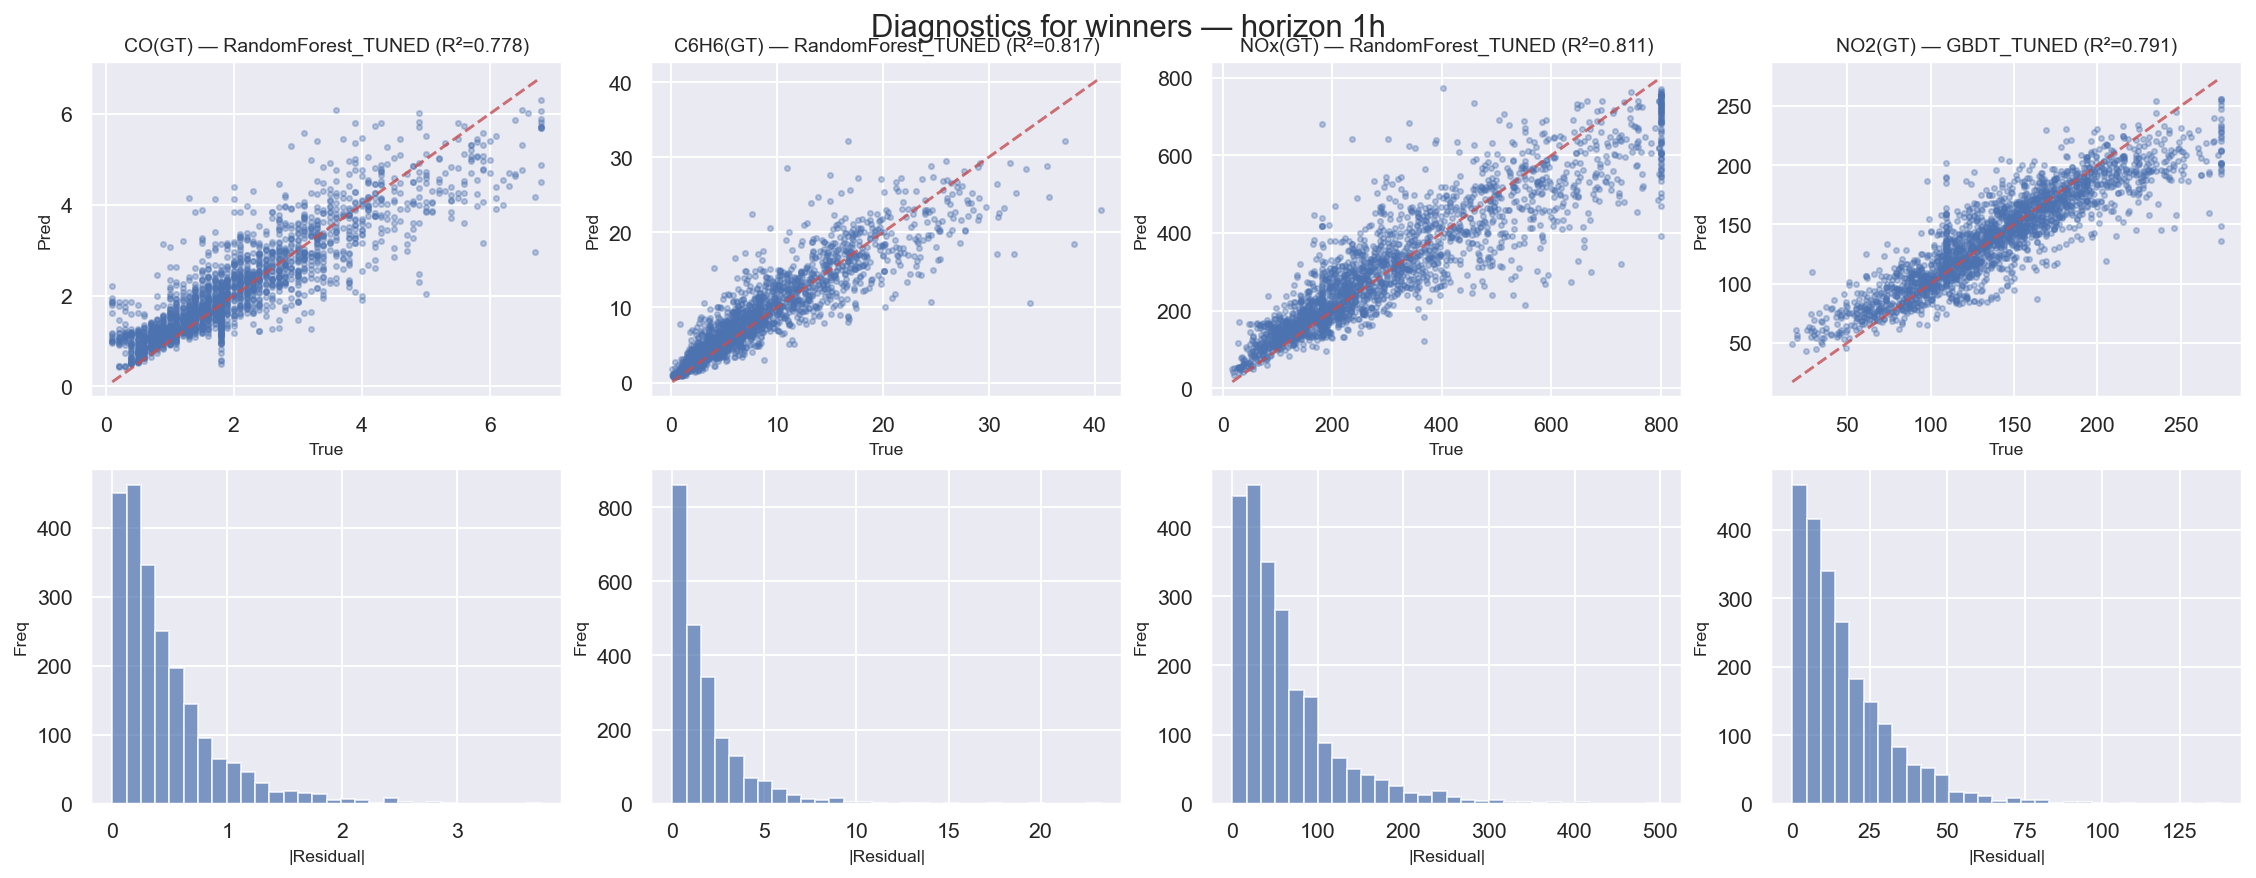

✓ Saved diagnostic plot for 6h: outputs\figs\diagnostics_winners_6h_compact.png


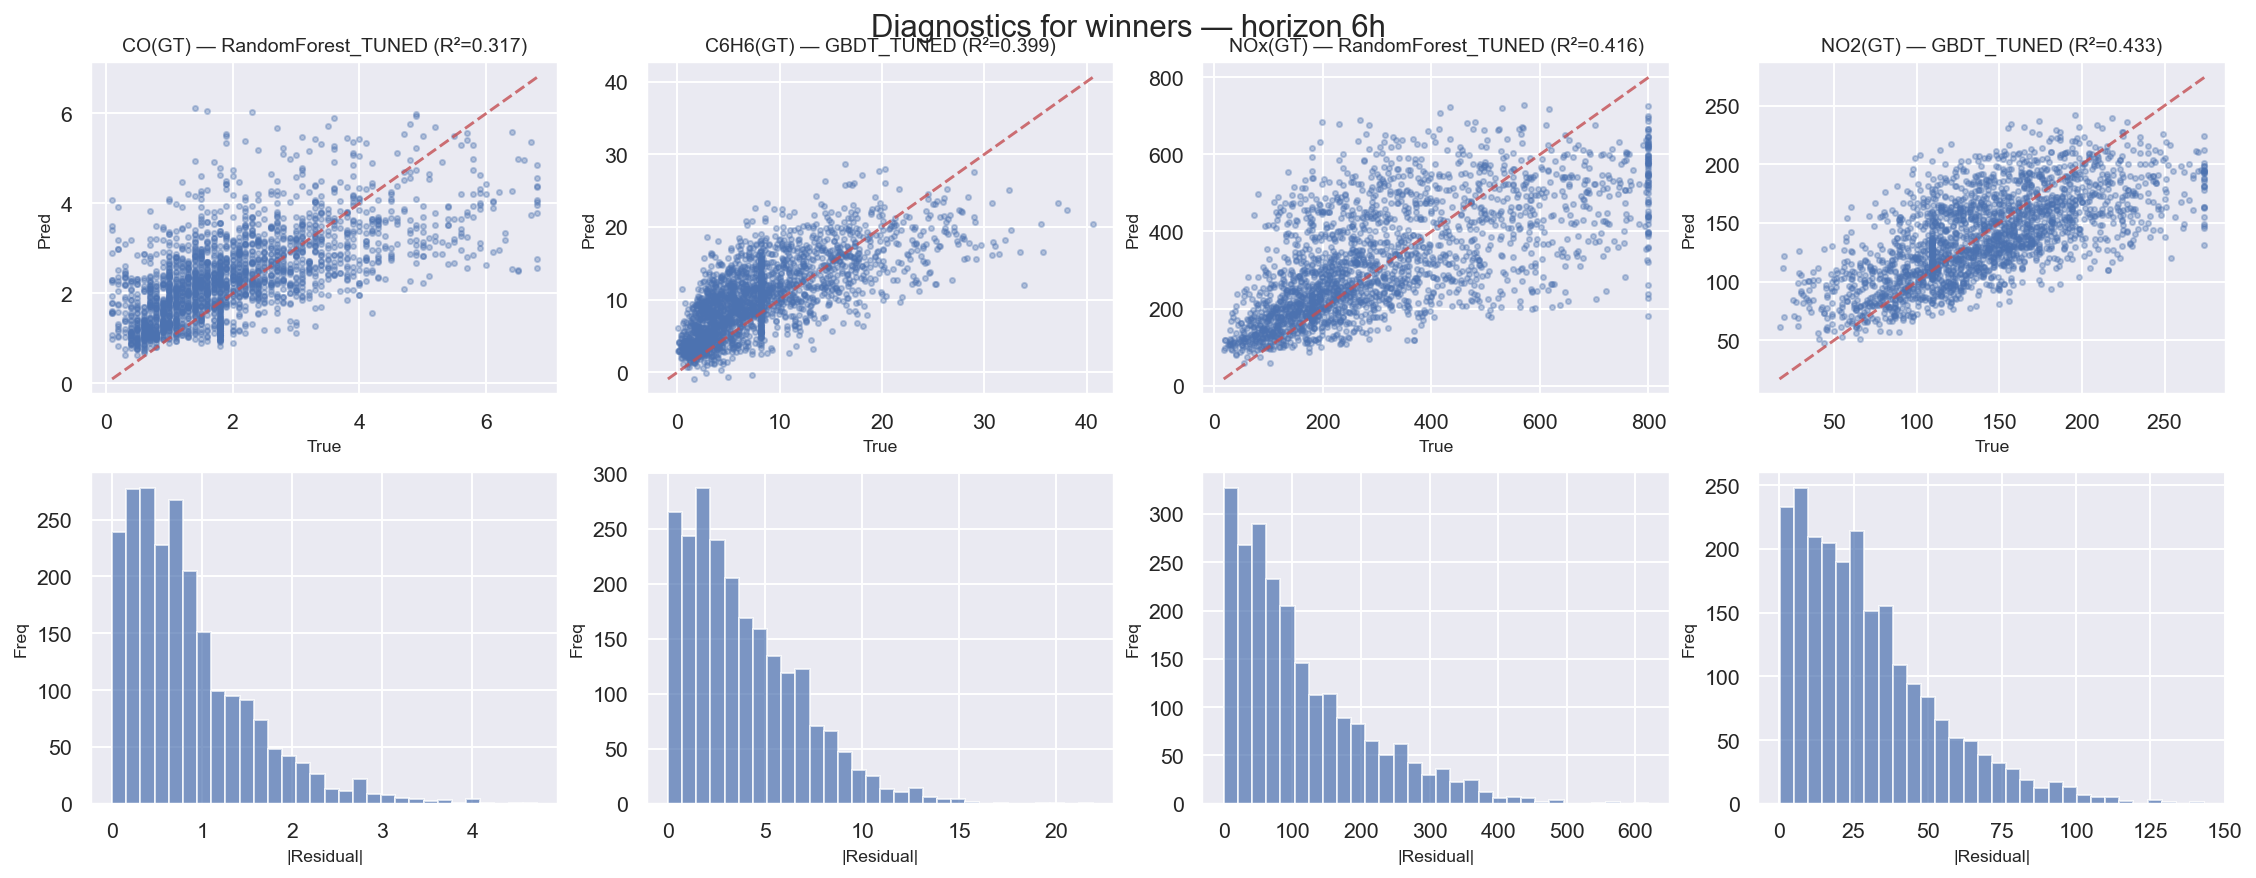

✓ Saved diagnostic plot for 12h: outputs\figs\diagnostics_winners_12h_compact.png


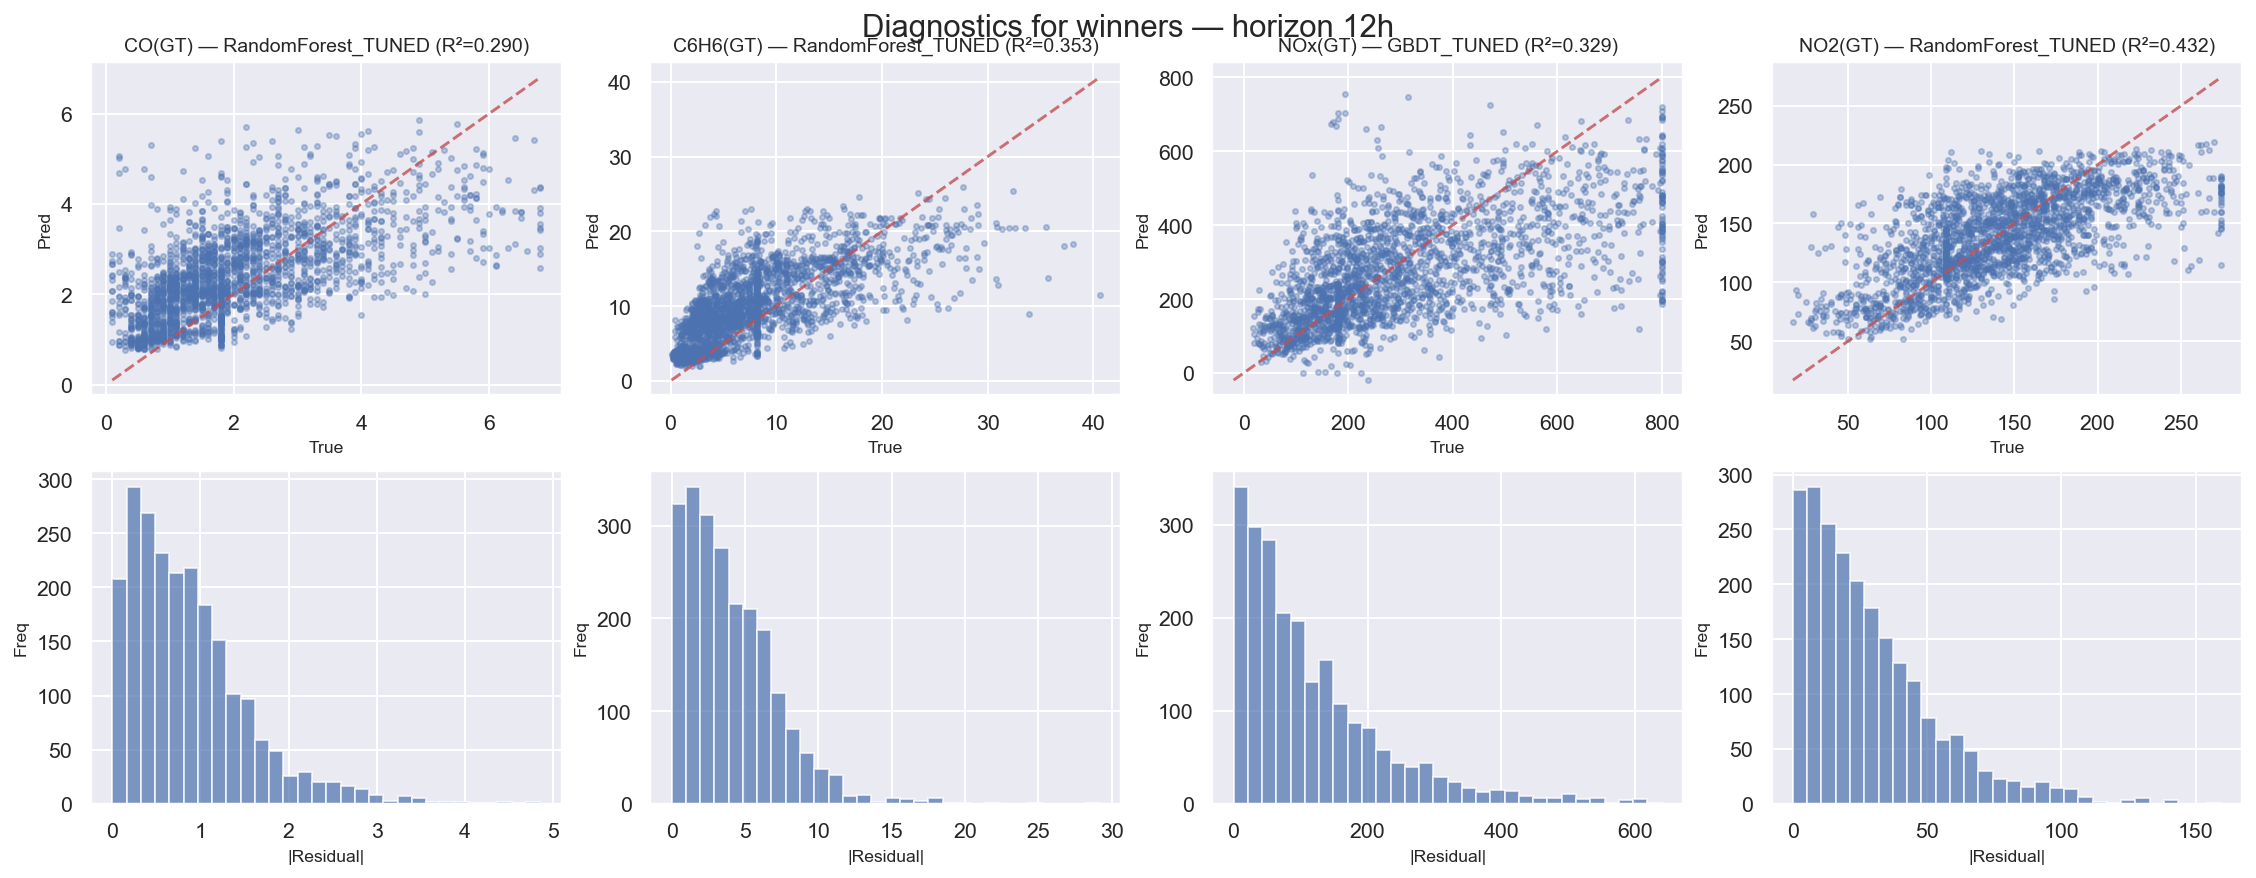

✓ Saved diagnostic plot for 24h: outputs\figs\diagnostics_winners_24h_compact.png


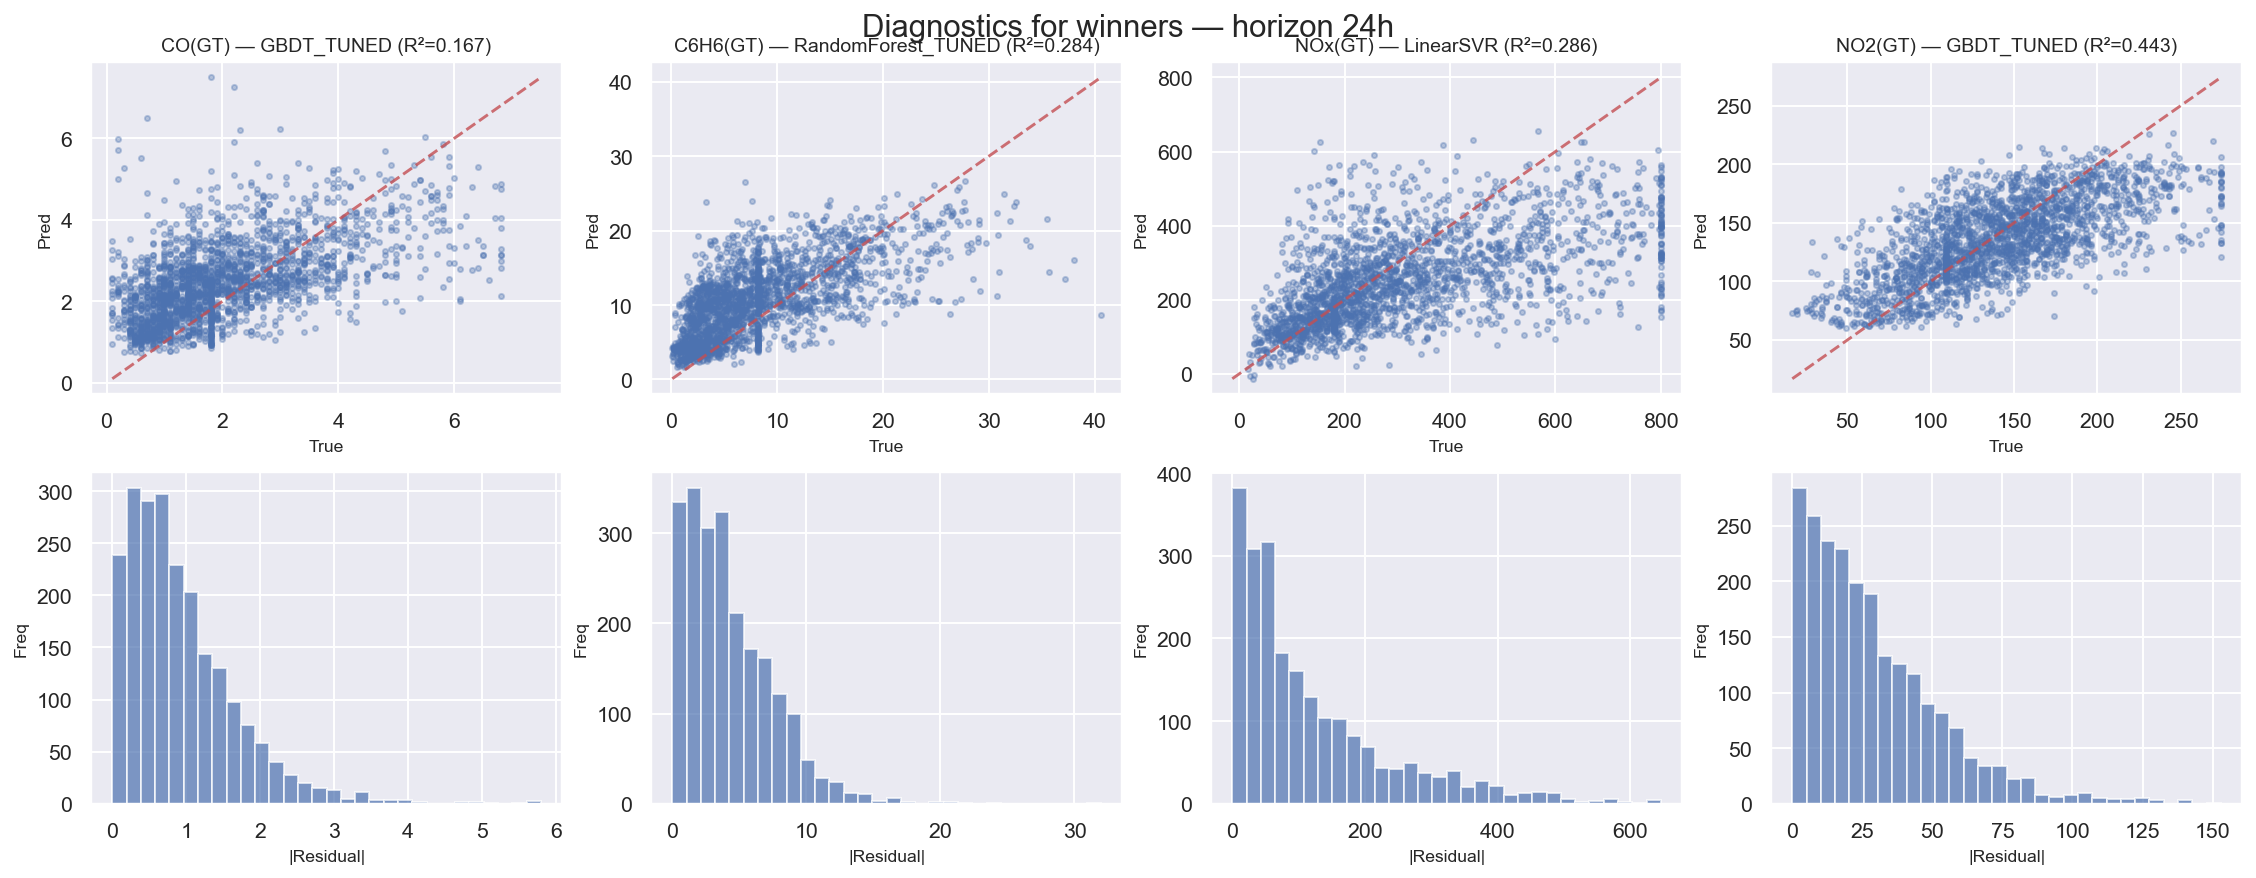

Diagnostic plots generation completed!


In [30]:
# Compact diagnostics for ALL horizons (1/6/12/24), one figure per horizon.
# Layout per figure: 2 rows × 4 cols (pollutants). Top: True vs Pred (with y=x);
# bottom: |Residual| histogram. Only winners from the heatmap are plotted:
#   - RandomForest_TUNED / GBDT_TUNED: load pickled models from outputs/models
#   - LinearSVR: re-fit quickly on train+val with fixed params (C=1.0, epsilon=0)
#
# Inputs assumed available from earlier cells/files:
#   - get_xy(pollutant, horizon, split) helper
#   - POLLUTANTS list
#   - tuned tree CSVs: outputs/results/tuned_tree_results.csv and tuned_tree_results_6_12.csv
#   - MLP+SVR CSV: outputs/results/mlp_svr_results.csv  (for LinearSVR metrics)

import os, pickle, json, numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVR

OUT_DIR = Path("outputs")
FIG_DIR = OUT_DIR / "figs"
MODEL_DIR = OUT_DIR / "models"
FIG_DIR.mkdir(parents=True, exist_ok=True)

HORIZONS = [1, 6, 12, 24]
SEED = 42

# --- Robust get_xy function with proper length alignment (SILENT version) ---
def get_xy_robust(pollutant: str, horizon: int, split: str):
    """
    Robust version of get_xy that handles length mismatches silently
    """
    assert pollutant in TARGETS and horizon in TARGETS[pollutant], "Unknown pollutant or horizon"
    masks = TARGETS[pollutant][horizon]
    
    if split == 'train':
        Xb = X_tr
        yb = masks['train']
        mb = masks['train_mask']
    elif split == 'val':
        Xb = X_va
        yb = masks['val']
        mb = masks['val_mask']
    elif split == 'test':
        Xb = X_te
        yb = masks['test']
        mb = masks['test_mask']
    else:
        raise ValueError("split must be one of {'train','val','test'}")

    # Handle length mismatches SILENTLY
    if len(mb) != len(Xb):
        # Truncate to the minimum length without printing warnings
        min_len = min(len(mb), len(Xb))
        mb = mb[:min_len]
        if isinstance(Xb, pd.DataFrame):
            X_aligned = Xb.iloc[:min_len][mb]
        else:
            X_aligned = Xb[:min_len][mb]
    else:
        # Normal case: lengths match
        if isinstance(Xb, pd.DataFrame):
            X_aligned = Xb[mb]
        else:
            X_aligned = Xb[mb]
    
    # Ensure y has the same number of samples as X
    # Count how many True values in the mask (after potential truncation)
    n_samples = np.sum(mb)
    if len(yb) != n_samples:
        # Truncate y to match X samples without printing warnings
        y_aligned = yb[:n_samples]
    else:
        y_aligned = yb
            
    return X_aligned, y_aligned

# --- Load results just for winners determination ---
paths = []
for p in [
    OUT_DIR / "results" / "tuned_tree_results.csv",
    OUT_DIR / "results" / "tuned_tree_results_6_12.csv",
    OUT_DIR / "results" / "mlp_svr_results.csv",
]:
    if p.exists(): paths.append(p)

if not paths:
    raise RuntimeError("No result CSVs found. Make sure tuned_tree_results*.csv and mlp_svr_results.csv exist.")

dfs = [pd.read_csv(p) for p in paths]
all_res = pd.concat(dfs, ignore_index=True)

# Normalize model names a bit (some CSVs may hold 'RandomForest_TUNED' etc.)
all_res["model"] = all_res["model"].astype(str)

# winner map: pick row with max R2 per pollutant × horizon
winners = (all_res
           .sort_values(["R2"], ascending=False)
           .groupby(["pollutant","horizon_h"], as_index=False)
           .first()[["pollutant","horizon_h","model","R2"]])

# Only keep horizons we will plot
winners = winners[winners["horizon_h"].isin(HORIZONS)].reset_index(drop=True)

print("Generating diagnostic plots for all horizons...")

# Helper: get a fitted model for (pollutant, h, model_name)
def get_fitted_model(pollutant: str, h: int, model_name: str):
    """
    If model is tuned tree, load pickled estimator.
    If model is LinearSVR, re-fit a small LinearSVR (C=1.0, epsilon=0) on train+val.
    Returns (estimator, X_te, y_te) ready for prediction.
    """
    # Prepare data using robust function
    X_tr, y_tr = get_xy_robust(pollutant, h, "train")
    X_va, y_va = get_xy_robust(pollutant, h, "val")
    X_te, y_te = get_xy_robust(pollutant, h, "test")
    
    # Check if we have any data
    if len(X_tr) == 0 or len(X_va) == 0 or len(X_te) == 0:
        raise ValueError(f"No data available for {pollutant} @ {h}h")
    
    X_fit = np.vstack([X_tr, X_va])
    y_fit = np.hstack([y_tr, y_va])

    # Route by model family
    if model_name in {"RandomForest_TUNED", "GBDT_TUNED"}:
        # Tuned trees were saved with these names
        fname = f"{pollutant.replace('/','-')}_{h}h_{'RF' if model_name.startswith('RandomForest') else 'GBDT'}.pkl"
        pkl = MODEL_DIR / fname
        if not pkl.exists():
            raise FileNotFoundError(f"Missing model pickle: {pkl}")
        with open(pkl, "rb") as f:
            est = pickle.load(f)
        return est, X_te, y_te

    elif model_name == "LinearSVR":
        est = LinearSVR(C=1.0, epsilon=0.0, loss="squared_epsilon_insensitive", random_state=SEED, max_iter=5000)
        est.fit(X_fit, y_fit)
        return est, X_te, y_te

    else:
        # Fallback: if a rare winner occurs, raise clearly
        raise ValueError(f"Unsupported winner model for diagnostics: {model_name}")

# --- Plot for each horizon in a compact 2×4 grid ---
def plot_diagnostics_for_h(h: int):
    # Winners for this horizon in the same pollutant order
    w_h = winners[winners["horizon_h"] == h].set_index("pollutant")
    missing = [p for p in POLLUTANTS if p not in w_h.index]
    if missing:
        return

    fig, axes = plt.subplots(
        nrows=2, ncols=4, figsize=(16, 6),  # compact
        constrained_layout=True
    )
    fig.suptitle(f"Diagnostics for winners — horizon {h}h", fontsize=16, y=1.02)

    success_count = 0
    for j, pollutant in enumerate(POLLUTANTS):
        if pollutant not in w_h.index:
            axes[0, j].axis("off")
            axes[1, j].axis("off")
            continue
            
        model_name = w_h.loc[pollutant, "model"]
        r2_val = float(w_h.loc[pollutant, "R2"])

        try:
            # Fit / load and predict
            est, X_te, y_te = get_fitted_model(pollutant, h, model_name)
            y_pred = est.predict(X_te)
            
            # Final length check
            if len(y_te) != len(y_pred):
                min_len = min(len(y_te), len(y_pred))
                y_te = y_te[:min_len]
                y_pred = y_pred[:min_len]
            
            resid = y_pred - y_te
            abs_resid = np.abs(resid)

            # --- Top row: True vs Pred with y=x ---
            ax_sc = axes[0, j]
            ax_sc.scatter(y_te, y_pred, s=7, alpha=0.35)
            # diagonal
            mn = np.nanmin([y_te.min(), y_pred.min()])
            mx = np.nanmax([y_te.max(), y_pred.max()])
            ax_sc.plot([mn, mx], [mn, mx], 'r--', alpha=0.8)
            ax_sc.set_title(f"{pollutant} — {model_name} (R²={r2_val:.3f})", fontsize=10)
            ax_sc.set_xlabel("True", fontsize=9)
            ax_sc.set_ylabel("Pred", fontsize=9)

            # --- Bottom row: |Residual| histogram (log-friendly x if heavy tail) ---
            ax_hist = axes[1, j]
            ax_hist.hist(abs_resid, bins=30, alpha=0.7)
            ax_hist.set_xlabel("|Residual|", fontsize=9)
            ax_hist.set_ylabel("Freq", fontsize=9)
            
            success_count += 1
            
        except Exception as e:
            axes[0, j].axis("off")
            axes[1, j].axis("off")
            continue

    # Only save if we have at least one successful plot
    if success_count > 0:
        out_png = FIG_DIR / f"diagnostics_winners_{h}h_compact.png"
        fig.savefig(out_png, dpi=150, bbox_inches="tight")
        print(f"✓ Saved diagnostic plot for {h}h: {out_png}")
        plt.show()
    else:
        plt.close(fig)
        print(f"✗ No successful plots for {h}h")

# ---- Run for all four horizons (will render 4 compact figures) ----
for hh in HORIZONS:
    plot_diagnostics_for_h(hh)

print("Diagnostic plots generation completed!")

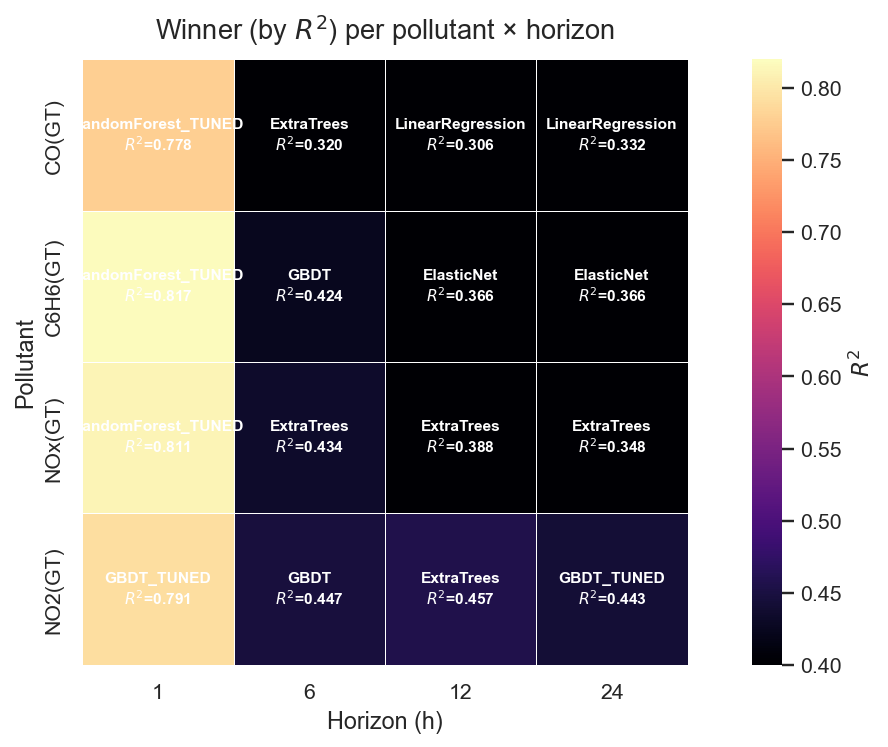

Saved heatmap to: C:\Users\20100\Downloads\COMP9417_GoodJob-main\COMP9417_GoodJob-main\outputs\figs\winner_heatmap_compact.png
Winners table:


,model,pollutant,R2,horizon_h
0,RandomForest_TUNED,CO(GT),0.778005,1
1,ExtraTrees,CO(GT),0.320027,6
2,LinearRegression,CO(GT),0.305831,12
3,LinearRegression,CO(GT),0.332129,24
4,RandomForest_TUNED,C6H6(GT),0.817181,1
5,GBDT,C6H6(GT),0.424390,6
6,ElasticNet,C6H6(GT),0.366247,12
7,ElasticNet,C6H6(GT),0.365534,24
8,RandomForest_TUNED,NOx(GT),0.810661,1
9,ExtraTrees,NOx(GT),0.433841,6


In [31]:
#   “winner (by R^2)” heatmap from whatever CSVs exist in outputs/results
# - Scans outputs/results/*.csv (linear / trees / mlp_svr / tuned_tree_*.csv)
# - Picks the best R^2 per (pollutant, horizon)
# - Renders a compact heatmap with model labels and saves it

import os, glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- config & guards ----
OUT_DIR = Path("outputs")
RES_DIR = OUT_DIR / "results"
FIG_DIR = OUT_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)

POLLUTANTS = ["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)"]
HORIZONS   = [1, 6, 12, 24]

# ---- load all result CSVs we can find ----
csv_paths = sorted(glob.glob(str(RES_DIR / "*.csv")))
if not csv_paths:
    raise RuntimeError("No CSV files found under outputs/results/. Please run your result cells first.")

dfs = []
for p in csv_paths:
    try:
        df = pd.read_csv(p)
        # keep only the columns we need; skip files that don't have them
        needed = {"model","pollutant","horizon_h","R2"}
        if needed.issubset(df.columns):
            # normalize column types
            df = df.copy()
            df["horizon_h"] = df["horizon_h"].astype(int)
            dfs.append(df[list(needed)])
    except Exception:
        pass

if not dfs:
    raise RuntimeError("Found CSVs, but none with required columns: model, pollutant, horizon_h, R2.")

all_results = pd.concat(dfs, ignore_index=True).dropna(subset=["R2"])
# keep only horizons/pollutants we care about
all_results = all_results[all_results["pollutant"].isin(POLLUTANTS) & all_results["horizon_h"].isin(HORIZONS)]

# ---- pick winner per (pollutant, horizon) ----
winners = (all_results
           .sort_values(["pollutant","horizon_h","R2"])
           .groupby(["pollutant","horizon_h"], as_index=False)
           .tail(1))

# order rows/cols
winners["pollutant"] = pd.Categorical(winners["pollutant"], categories=POLLUTANTS, ordered=True)
winners["horizon_h"] = pd.Categorical(winners["horizon_h"], categories=HORIZONS, ordered=True)
winners = winners.sort_values(["pollutant","horizon_h"])

# pivot to a matrix of R^2
mat = winners.pivot(index="pollutant", columns="horizon_h", values="R2").loc[POLLUTANTS, HORIZONS]
labels = winners.pivot(index="pollutant", columns="horizon_h", values="model").loc[POLLUTANTS, HORIZONS]

# ---- plot a compact heatmap with model labels ----
plt.figure(figsize=(9.5, 5.5))
ax = sns.heatmap(
    mat, annot=False, cmap="magma", vmin=0.4, vmax=0.82, cbar_kws={"label": r"$R^2$"},
    linewidths=0.5, linecolor="white", square=True
)
ax.set_title("Winner (by $R^2$) per pollutant × horizon", fontsize=14, pad=10)
ax.set_xlabel("Horizon (h)")
ax.set_ylabel("Pollutant")

# add model name + R^2 text inside each cell
for i, pol in enumerate(mat.index):
    for j, h in enumerate(mat.columns):
        r2 = mat.loc[pol, h]
        name = labels.loc[pol, h]
        txt = f"{name}\n$R^2$={r2:.3f}"
        ax.text(j+0.5, i+0.5, txt, ha="center", va="center", color="white", fontsize=8, weight="bold")

plt.tight_layout()
save_path = FIG_DIR / "winner_heatmap_compact.png"
plt.savefig(save_path, dpi=200)
plt.show()

print("Saved heatmap to:", save_path.resolve())
print("Winners table:")
display(winners.reset_index(drop=True))

In [32]:


import os, glob, shutil
from pathlib import Path

# 1) Define canonical directories
OUT_DIR   = Path("outputs")
FIG_DIR   = OUT_DIR / "figures"     # <-- single source of truth for figures
LEGACY_1  = OUT_DIR / "figs"        # legacy folder I mistakenly created
OUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)


patterns = ["*.png", "*.jpg", "*.jpeg", "*.svg", "*.pdf"]
moved = []

def move_all(src_dir, dst_dir):
    if not src_dir.exists():
        return
    for pat in patterns:
        for p in src_dir.glob(pat):
            target = dst_dir / p.name
            # If a same-named file exists, add a suffix to avoid overwrite
            if target.exists() and target.read_bytes() != p.read_bytes():
                stem, suf = p.stem, p.suffix
                k = 1
                while True:
                    cand = dst_dir / f"{stem}__dup{k}{suf}"
                    if not cand.exists():
                        target = cand
                        break
                    k += 1
            shutil.move(str(p), str(target))
            moved.append((str(p), str(target)))
    # remove src_dir if empty
    try:
        if src_dir.exists() and not any(src_dir.iterdir()):
            src_dir.rmdir()
    except Exception:
        pass

move_all(LEGACY_1, FIG_DIR)

move_all(OUT_DIR, FIG_DIR)

# 3) Define a single save helper for later plots
def savefig(filename, dpi=200, bbox_inches="tight"):
    """
    Save current matplotlib figure into the canonical figures directory.
    Usage:
        plt.savefig(savefig_path := savefig("winner_heatmap_compact.png"))
    or simply:
        savefig("winner_heatmap_compact.png")
    """
    from matplotlib import pyplot as plt
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    full = FIG_DIR / filename
    plt.savefig(full, dpi=dpi, bbox_inches=bbox_inches)
    print("Saved figure to:", full.resolve())
    return str(full)

# 4) Report what happened
print("FIG_DIR =", FIG_DIR.resolve())
if moved:
    print("\nMoved files:")
    for src, dst in moved[:20]:
        print(" -", src, "->", dst)
    if len(moved) > 20:
        print(f"... and {len(moved)-20} more.")
else:
    print("No legacy images to move; folders are already consistent.")

FIG_DIR = C:\Users\20100\Downloads\COMP9417_GoodJob-main\COMP9417_GoodJob-main\outputs\figures

Moved files:
 - outputs\figs\diagnostics_winners_12h_compact.png -> outputs\figures\diagnostics_winners_12h_compact.png
 - outputs\figs\diagnostics_winners_1h_compact.png -> outputs\figures\diagnostics_winners_1h_compact.png
 - outputs\figs\diagnostics_winners_24h_compact.png -> outputs\figures\diagnostics_winners_24h_compact.png
 - outputs\figs\diagnostics_winners_6h_compact.png -> outputs\figures\diagnostics_winners_6h_compact.png
 - outputs\figs\tuned_trees_summary.png -> outputs\figures\tuned_trees_summary.png
 - outputs\figs\winner_heatmap_compact.png -> outputs\figures\winner_heatmap_compact.png


In [18]:
# ===== LSTM/GRU sequence helpers =====
# Build sliding-window sequences from the already-aligned tabular X/y.
# This cell ONLY defines utilities. It prints an OK banner when ready.

import numpy as np
import pandas as pd

# Default sequence length (past hours). You can change to 12/24/48 later.
SEQ_LEN = 24

def _to_numpy(arr):
    """Accepts pandas Series/DataFrame or numpy and returns numpy array."""
    if isinstance(arr, (pd.Series, pd.DataFrame)):
        return arr.to_numpy()
    return np.asarray(arr)

def build_sequences_from_aligned(X, y, seq_len=SEQ_LEN):
    """
    Given aligned X (n, d) and y (n,), create rolling sequences:
      X_seq shape: (n - seq_len + 1, seq_len, d)
      y_seq shape: (n - seq_len + 1,)
    We drop any window containing NaNs in X or y.
    """
    X = _to_numpy(X)
    y = _to_numpy(y).reshape(-1)

    n, d = X.shape
    if n < seq_len:
        return np.empty((0, seq_len, d)), np.empty((0,))

    # Build indices for rolling windows
    idx = np.arange(n)
    windows = np.lib.stride_tricks.sliding_window_view(idx, window_shape=seq_len)

    # Collect valid windows (no NaNs in the block and target at window end is finite)
    X_seq_list = []
    y_seq_list = []

    # Precompute NaN masks for speed
    x_nan_row = ~np.isfinite(X).all(axis=1)
    y_nan = ~np.isfinite(y)

    for w in windows:
        # If any row in this window has NaNs in features, skip
        if x_nan_row[w].any():
            continue
        # Target is the last index of the window (predict y_t using t-SEQ_LEN+1 ... t features)
        t = w[-1]
        if y_nan[t]:
            continue
        X_seq_list.append(X[w, :])
        y_seq_list.append(y[t])

    if not X_seq_list:
        return np.empty((0, seq_len, d)), np.empty((0,))

    X_seq = np.stack(X_seq_list, axis=0)
    y_seq = np.asarray(y_seq_list, dtype=float)
    return X_seq, y_seq

def get_seq_xy(pollutant, horizon, split, seq_len=SEQ_LEN):
    """
    Wrapper over your get_xy() to produce (X_seq, y_seq) for sequence models.
    - Uses the same alignment & split you established earlier.
    - Returns possibly smaller n due to sliding-window.
    """
    # Uses your previously defined helper
    X_aligned, y_aligned = get_xy(pollutant, horizon, split)
    return build_sequences_from_aligned(X_aligned, y_aligned, seq_len=seq_len)

print("[OK] Sequence builders are ready. SEQ_LEN =", SEQ_LEN)

[OK] Sequence builders are ready. SEQ_LEN = 24


In [19]:
# ===== LSTM / GRU training & evaluation (uses get_seq_xy / build_sequences_from_aligned from previous cell) =====
# - Builds rolling sequences from your aligned X/y
# - Trains small LSTM and GRU with early stopping on val
# - Evaluates on TEST and appends results to outputs/results/dl_results.csv
# - Saves best weights per (pollutant, horizon, model) under outputs/models/
# - Prints compact progress lines; no plots here (we'll plot in the next cell)

import os, time, math, json
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ---- Reproducibility (best-effort) ----
SEED = 42
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism = False  # allow faster oneDNN paths

# ---- Config ----
HORIZONS = [1, 6, 12, 24]           
POLLUTANTS = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']   
SEQ_LEN = 24                         # must match previous cell unless you change it
BATCH = 128
EPOCHS = 60
PATIENCE = 8
LR = 1e-3
MODEL_KINDS = ["LSTM", "GRU"]        # both

OUT_DIR = Path("outputs")
(OUT_DIR / "results").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "models").mkdir(parents=True, exist_ok=True)

# ---- Metrics helpers (same as earlier) ----
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def _rmse(y_true, y_pred):
    m = ~(np.isnan(y_true) | np.isnan(y_pred))
    return math.sqrt(mean_squared_error(y_true[m], y_pred[m])) if m.any() else np.nan

def _mae(y_true, y_pred):
    m = ~(np.isnan(y_true) | np.isnan(y_pred))
    return mean_absolute_error(y_true[m], y_pred[m]) if m.any() else np.nan

def _mape(y_true, y_pred):
    m = ~(np.isnan(y_true) | np.isnan(y_pred)) & (y_true != 0)
    return (np.mean(np.abs((y_true[m] - y_pred[m]) / y_true[m])) * 100) if m.any() else np.nan

# ---- Sequence builder adapter ----

def _build_sequences_adapter(X_tab, y_vec, seq_len):
    try:
        # prefer the builder defined in the previous cell
        return build_sequences_from_aligned(X_tab, y_vec, seq_len=seq_len)
    except NameError:
        # fallback: if your previous cell exposed get_seq_xy in seq-mode
        raise RuntimeError(
            "Neither build_sequences_from_aligned(...) is defined nor provided by previous cell. "
            "Please run the 'Sequence builders are ready.' cell first."
        )

# ---- Model builders ----
def build_seq_model(kind: str, seq_len: int, n_feat: int):
    """
    kind: 'LSTM' or 'GRU'
    Architecture: small stack + dropout + linear head.
    """
    inputs = keras.Input(shape=(seq_len, n_feat))
    if kind.upper() == "LSTM":
        x = layers.LSTM(64, return_sequences=True)(inputs)
        x = layers.Dropout(0.2)(x)
        x = layers.LSTM(32)(x)
    elif kind.upper() == "GRU":
        x = layers.GRU(64, return_sequences=True)(inputs)
        x = layers.Dropout(0.2)(x)
        x = layers.GRU(32)(x)
    else:
        raise ValueError("Unknown kind: " + kind)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(1, activation="linear")(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=LR),
                  loss="mse",
                  metrics=[keras.metrics.MeanAbsoluteError(name="mae")])
    return model

# ---- Training loop ----
rows = []
print("="*74)
print("Deep sequence models: LSTM & GRU (seq_len=%d, epochs=%d, patience=%d)" % (SEQ_LEN, EPOCHS, PATIENCE))
print("Horizons =", HORIZONS)
print("="*74)

for pollutant in POLLUTANTS:
    print(f"\nPollutant: {pollutant}")
    for h in HORIZONS:
        # 1) get aligned tabular X/y
        Xtr_tab, ytr = get_xy(pollutant, h, "train")
        Xva_tab, yva = get_xy(pollutant, h, "val")
        Xte_tab, yte = get_xy(pollutant, h, "test")

        # 2) build rolling sequences
        Xtr_seq, ytr_seq = _build_sequences_adapter(Xtr_tab, ytr, seq_len=SEQ_LEN)
        Xva_seq, yva_seq = _build_sequences_adapter(Xva_tab, yva, seq_len=SEQ_LEN)
        Xte_seq, yte_seq = _build_sequences_adapter(Xte_tab, yte, seq_len=SEQ_LEN)

        if Xtr_seq.shape[0] == 0 or Xva_seq.shape[0] == 0 or Xte_seq.shape[0] == 0:
            print(f"  {h:>2}h | [SKIP] not enough sequences (train/val/test windows too few)")
            continue

        n_feat = Xtr_seq.shape[-1]

        for kind in MODEL_KINDS:
            model = build_seq_model(kind, SEQ_LEN, n_feat)

            ckpt_path = OUT_DIR / "models" / f"{pollutant.replace('/','-')}_{h}h_{kind}_best.keras"
            callbacks = [
                keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True),
                # **IMPORTANT**: convert Path -> str
                keras.callbacks.ModelCheckpoint(filepath=str(ckpt_path),
                                                monitor="val_loss",
                                                save_best_only=True,
                                                save_weights_only=False,
                                                verbose=0),
            ]

            t0 = time.time()
            hist = model.fit(
                Xtr_seq, ytr_seq,
                validation_data=(Xva_seq, yva_seq),
                epochs=EPOCHS,
                batch_size=BATCH,
                verbose=0,
                callbacks=callbacks,
                shuffle=False,
            )
            t_train = time.time() - t0

            # 3) Evaluate on TEST
            y_pred = model.predict(Xte_seq, batch_size=BATCH, verbose=0).reshape(-1)
            rmse = _rmse(yte_seq, y_pred)
            mae  = _mae(yte_seq, y_pred)
            mape = _mape(yte_seq, y_pred)
            r2   = r2_score(yte_seq, y_pred)

            row = {
                "model": kind,
                "pollutant": pollutant,
                "horizon_h": h,
                "RMSE": rmse,
                "MAE": mae,
                "MAPE(%)": mape,
                "R2": r2,
                "fit_time_s": t_train,
                "n_train_seq": int(Xtr_seq.shape[0]),
                "n_val_seq": int(Xva_seq.shape[0]),
                "n_test_seq": int(Xte_seq.shape[0]),
                "seq_len": SEQ_LEN,
                "params": f"LR={LR},BATCH={BATCH},EPOCHS={EPOCHS}",
            }
            rows.append(row)
            print(f"  {h:>2}h | {kind:<4} R²={r2:6.3f}  RMSE={rmse:7.3f}  MAE={mae:6.3f}  "
                  f"time={t_train:5.1f}s  seqs[tr/va/te]={Xtr_seq.shape[0]}/{Xva_seq.shape[0]}/{Xte_seq.shape[0]}")

# 4) Save results and quick peek
dl_df = pd.DataFrame(rows)
save_path = OUT_DIR / "results" / "dl_results.csv"
dl_df.to_csv(save_path, index=False)
print("\nSaved:", save_path.resolve())

if not dl_df.empty:
    display(
        dl_df.sort_values(["horizon_h", "pollutant", "R2"], ascending=[True, True, False])
             .reset_index(drop=True)
             .head(20)
    )
else:
    print("[WARN] No DL results produced (likely due to insufficient sequence windows).")

Deep sequence models: LSTM & GRU (seq_len=24, epochs=60, patience=8)
Horizons = [1, 6, 12, 24]

Pollutant: CO(GT)


   1h | LSTM R²= 0.578  RMSE=  0.861  MAE= 0.641  time= 29.9s  seqs[tr/va/te]=5641/1399/2223
   1h | GRU  R²= 0.527  RMSE=  0.912  MAE= 0.707  time= 25.4s  seqs[tr/va/te]=5641/1399/2223
   6h | LSTM R²= 0.067  RMSE=  1.281  MAE= 0.969  time= 28.6s  seqs[tr/va/te]=5641/1399/2218
   6h | GRU  R²= 0.117  RMSE=  1.247  MAE= 1.007  time= 12.9s  seqs[tr/va/te]=5641/1399/2218
  12h | LSTM R²= 0.305  RMSE=  1.107  MAE= 0.863  time= 33.0s  seqs[tr/va/te]=5641/1399/2212
  12h | GRU  R²= 0.239  RMSE=  1.158  MAE= 0.927  time= 46.3s  seqs[tr/va/te]=5641/1399/2212
  24h | LSTM R²= 0.252  RMSE=  1.151  MAE= 0.912  time= 31.4s  seqs[tr/va/te]=5641/1399/2200
  24h | GRU  R²= 0.261  RMSE=  1.143  MAE= 0.880  time= 18.0s  seqs[tr/va/te]=5641/1399/2200

Pollutant: C6H6(GT)
   1h | LSTM R²= 0.555  RMSE=  4.269  MAE= 3.357  time= 40.9s  seqs[tr/va/te]=5641/1399/2223
   1h | GRU  R²= 0.196  RM

,model,pollutant,horizon_h,RMSE,MAE,MAPE(%),R2,fit_time_s,n_train_seq,n_val_seq,n_test_seq,seq_len,params
0,LSTM,C6H6(GT),1,4.269149,3.357182,96.243320,0.555020,40.868005,5641,1399,2223,24,"LR=0.001,BATCH=128,EPOCHS=60"
1,GRU,C6H6(GT),1,5.738267,4.906451,144.915953,0.196068,16.222689,5641,1399,2223,24,"LR=0.001,BATCH=128,EPOCHS=60"
2,LSTM,CO(GT),1,0.861199,0.640555,60.674635,0.577879,29.860098,5641,1399,2223,24,"LR=0.001,BATCH=128,EPOCHS=60"
3,GRU,CO(GT),1,0.912094,0.707483,71.089757,0.526512,25.399006,5641,1399,2223,24,"LR=0.001,BATCH=128,EPOCHS=60"
4,LSTM,NO2(GT),1,42.149540,31.563740,21.808610,0.291665,52.652599,5641,1399,2223,24,"LR=0.001,BATCH=128,EPOCHS=60"
5,GRU,NO2(GT),1,52.130127,40.125369,26.811048,-0.083504,35.062102,5641,1399,2223,24,"LR=0.001,BATCH=128,EPOCHS=60"
6,GRU,NOx(GT),1,238.675717,167.778595,54.514130,-0.489712,30.295054,5641,1399,2223,24,"LR=0.001,BATCH=128,EPOCHS=60"
7,LSTM,NOx(GT),1,239.146003,168.165926,54.477334,-0.495589,36.591555,5641,1399,2223,24,"LR=0.001,BATCH=128,EPOCHS=60"
8,LSTM,C6H6(GT),6,6.365768,5.453809,185.124859,0.011907,51.007442,5641,1399,2218,24,"LR=0.001,BATCH=128,EPOCHS=60"
9,GRU,C6H6(GT),6,6.794511,5.802314,212.676726,-0.125674,12.796342,5641,1399,2218,24,"LR=0.001,BATCH=128,EPOCHS=60"


In [20]:
# ===== LSTM / GRU on scaled features (pack='nn'), SEQ_LEN=48 =====
# - Uses the same TARGETS/masks, but reloads base X from the normalized "nn" pack
# - Window length = 48 (better for 6/12/24h)
# - Adds ReduceLROnPlateau; uses slightly smaller LR and batch size for stability
# - Saves results to outputs/results/dl_results_nn48.csv and models with *_nn48.keras


import os, time, math
from pathlib import Path
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# --------- Safety checks ---------
try:
    build_sequences_from_aligned
except NameError as _:
    raise RuntimeError("build_sequences_from_aligned() is not defined. Run the 'Sequence builders are ready.' cell first.")

# --------- Reproducibility (best-effort) ---------
SEED = 42
tf.keras.utils.set_random_seed(SEED)
# Keep oneDNN/cudnn fast paths; determinism off for throughput
tf.config.experimental.enable_op_determinism = False

# --------- Config ---------
HORIZONS   = [1, 6, 12, 24]     # same as before
POLLUTANTS = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']
SEQ_LEN    = 48                  # longer window than 24
BATCH      = 64                  # smaller batch for stability
EPOCHS     = 100                 # allow more training
PATIENCE   = 12                  # early stopping patience
LR         = 5e-4                # smaller LR works better with longer windows
MODEL_KINDS = ["LSTM", "GRU"]    # both

OUT_DIR = Path("outputs")
(OUT_DIR / "results").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "models").mkdir(parents=True, exist_ok=True)

# --------- Metrics ---------
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def _rmse(y_true, y_pred):
    m = ~(np.isnan(y_true) | np.isnan(y_pred))
    return math.sqrt(mean_squared_error(y_true[m], y_pred[m])) if m.any() else np.nan

def _mae(y_true, y_pred):
    m = ~(np.isnan(y_true) | np.isnan(y_pred))
    return mean_absolute_error(y_true[m], y_pred[m]) if m.any() else np.nan

def _mape(y_true, y_pred):
    m = ~(np.isnan(y_true) | np.isnan(y_pred)) & (y_true != 0)
    return (np.mean(np.abs((y_true[m] - y_pred[m]) / y_true[m])) * 100) if m.any() else np.nan

# --------- Robust loader that aligns scaled X (pack='nn') with TARGETS masks ---------
def get_xy_scaled(pollutant: str, horizon: int, split: str):
    """
    Return (X_aligned, y_aligned) for given pollutant/horizon/split using the normalized 'nn' pack.
    - Aligns by TARGETS[pollutant][horizon]['<split>_mask']
    - Drops NaNs in y and mirrors on X
    - Returns numpy arrays
    """
    # reload immutable 'nn' features
    X_block, yreg_block, _ = load_pack(str(PACK_DIR), pack="nn", split=split)  # X_block is scaled features
    m_align = TARGETS[pollutant][horizon][f"{split}_mask"]
    y_vec   = TARGETS[pollutant][horizon][split]

    # length safeguard
    if len(m_align) != len(X_block):
        L = min(len(m_align), len(X_block))
        m_align = m_align[:L]
        try:
            X_block = X_block.iloc[:L]
        except Exception:
            X_block = X_block[:L]

    # boolean index
    try:
        X_aligned = X_block[m_align]
    except Exception:
        X_aligned = X_block[m_align.astype(bool)]

    # drop NaNs in y and mirror on X
    m_nan = np.isfinite(y_vec)
    try:
        X_aligned = X_aligned[m_nan]
    except Exception:
        X_aligned = X_aligned[m_nan.astype(bool)]
    y_aligned = y_vec[m_nan]

    # to numpy
    try:
        X_aligned = X_aligned.values
    except Exception:
        pass
    return X_aligned, y_aligned

# --------- Model builders ---------
def build_seq_model(kind: str, seq_len: int, n_feat: int):
    """
    Small stacked LSTM/GRU with dropout and a dense head.
    Tweaks vs. previous: slightly wider layers for longer windows.
    """
    inputs = keras.Input(shape=(seq_len, n_feat))
    if kind.upper() == "LSTM":
        x = layers.LSTM(96, return_sequences=True)(inputs)
        x = layers.Dropout(0.15)(x)
        x = layers.LSTM(64)(x)
    elif kind.upper() == "GRU":
        x = layers.GRU(96, return_sequences=True)(inputs)
        x = layers.Dropout(0.15)(x)
        x = layers.GRU(64)(x)
    else:
        raise ValueError("Unknown kind: " + kind)

    x = layers.Dropout(0.15)(x)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(1, activation="linear")(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR),
        loss="mse",
        metrics=[keras.metrics.MeanAbsoluteError(name="mae")]
    )
    return model

# --------- Training loop ---------
rows = []
print("="*74)
print(f"Deep sequence models (scaled): LSTM & GRU  (seq_len={SEQ_LEN}, epochs={EPOCHS}, patience={PATIENCE})")
print("Horizons =", HORIZONS)
print("Pack     = 'nn' (standardized features)")
print("="*74)

for pollutant in POLLUTANTS:
    print(f"\nPollutant: {pollutant}")
    for h in HORIZONS:
        # 1) Fetch aligned, scaled tabular features
        Xtr_tab, ytr = get_xy_scaled(pollutant, h, "train")
        Xva_tab, yva = get_xy_scaled(pollutant, h, "val")
        Xte_tab, yte = get_xy_scaled(pollutant, h, "test")

        # 2) Build rolling sequences
        Xtr_seq, ytr_seq = build_sequences_from_aligned(Xtr_tab, ytr, seq_len=SEQ_LEN)
        Xva_seq, yva_seq = build_sequences_from_aligned(Xva_tab, yva, seq_len=SEQ_LEN)
        Xte_seq, yte_seq = build_sequences_from_aligned(Xte_tab, yte, seq_len=SEQ_LEN)

        if Xtr_seq.shape[0] == 0 or Xva_seq.shape[0] == 0 or Xte_seq.shape[0] == 0:
            print(f"  {h:>2}h | [SKIP] not enough sequences (tr/va/te windows too few)")
            continue

        n_feat = Xtr_seq.shape[-1]

        for kind in MODEL_KINDS:
            model = build_seq_model(kind, SEQ_LEN, n_feat)

            # callbacks: EarlyStopping + ReduceLROnPlateau + ModelCheckpoint
            ckpt_path = (OUT_DIR / "models" / f"{pollutant.replace('/','-')}_{h}h_{kind}_nn48_best.keras")
            callbacks = [
                keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True),
                keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=max(4, PATIENCE//2),
                                                  min_lr=1e-5, verbose=0),
                keras.callbacks.ModelCheckpoint(filepath=str(ckpt_path), monitor="val_loss",
                                                save_best_only=True, save_weights_only=False, verbose=0),
            ]

            t0 = time.time()
            hist = model.fit(
                Xtr_seq, ytr_seq,
                validation_data=(Xva_seq, yva_seq),
                epochs=EPOCHS,
                batch_size=BATCH,
                verbose=0,
                callbacks=callbacks,
                shuffle=False
            )
            t_train = time.time() - t0

            # 3) Evaluate on TEST
            y_pred = model.predict(Xte_seq, batch_size=BATCH, verbose=0).reshape(-1)
            rmse = _rmse(yte_seq, y_pred)
            mae  = _mae(yte_seq, y_pred)
            mape = _mape(yte_seq, y_pred)
            r2   = r2_score(yte_seq, y_pred)

            row = {
                "model": f"{kind}_nn48",
                "pollutant": pollutant,
                "horizon_h": h,
                "RMSE": rmse,
                "MAE": mae,
                "MAPE(%)": mape,
                "R2": r2,
                "fit_time_s": t_train,
                "n_train_seq": int(Xtr_seq.shape[0]),
                "n_val_seq": int(Xva_seq.shape[0]),
                "n_test_seq": int(Xte_seq.shape[0]),
                "seq_len": SEQ_LEN,
                "params": f"LR={LR},BATCH={BATCH},EPOCHS={EPOCHS}",
            }
            rows.append(row)
            print(f"  {h:>2}h | {kind:<4} (nn48)  R²={r2:6.3f}  RMSE={rmse:7.3f}  MAE={mae:6.3f}  "
                  f"time={t_train:5.1f}s  seqs[tr/va/te]={Xtr_seq.shape[0]}/{Xva_seq.shape[0]}/{Xte_seq.shape[0]}")

# 4) Save results and quick peek
dl_df = pd.DataFrame(rows)
save_path = OUT_DIR / "results" / "dl_results_nn48.csv"
dl_df.to_csv(save_path, index=False)
print("\nSaved:", save_path.resolve())

if not dl_df.empty:
    display(
        dl_df.sort_values(["horizon_h", "pollutant", "R2"], ascending=[True, True, False])
             .reset_index(drop=True)
             .head(20)
    )
else:
    print("[WARN] No DL results produced (likely due to insufficient sequence windows).")

Deep sequence models (scaled): LSTM & GRU  (seq_len=48, epochs=100, patience=12)
Horizons = [1, 6, 12, 24]
Pack     = 'nn' (standardized features)

Pollutant: CO(GT)
   1h | LSTM (nn48)  R²=-0.025  RMSE=  1.346  MAE= 0.915  time=101.4s  seqs[tr/va/te]=5617/1375/2199
   1h | GRU  (nn48)  R²= 0.278  RMSE=  1.130  MAE= 0.868  time=107.0s  seqs[tr/va/te]=5617/1375/2199
   6h | LSTM (nn48)  R²= 0.130  RMSE=  1.241  MAE= 0.896  time= 76.1s  seqs[tr/va/te]=5617/1375/2194
   6h | GRU  (nn48)  R²= 0.215  RMSE=  1.180  MAE= 0.853  time= 94.8s  seqs[tr/va/te]=5617/1375/2194
  12h | LSTM (nn48)  R²=-0.414  RMSE=  1.584  MAE= 1.175  time= 47.8s  seqs[tr/va/te]=5617/1375/2188
  12h | GRU  (nn48)  R²= 0.226  RMSE=  1.172  MAE= 0.886  time= 92.9s  seqs[tr/va/te]=5617/1375/2188
  24h | LSTM (nn48)  R²=-0.148  RMSE=  1.427  MAE= 1.011  time= 52.2s  seqs[tr/va/te]=5617/1375/2176
  24h | GRU  (nn48)  R²= 0.265  RMSE=  1.142  MAE= 0.808  time= 44.8s  seqs[tr/va/te]=5617/1375/2176

Pollutant: C6H6(GT)
   1h

,model,pollutant,horizon_h,RMSE,MAE,MAPE(%),R2,fit_time_s,n_train_seq,n_val_seq,n_test_seq,seq_len,params
0,LSTM_nn48,C6H6(GT),1,5.668743,4.176999,92.731293,0.221431,84.998022,5617,1375,2199,48,"LR=0.0005,BATCH=64,EPOCHS=100"
1,GRU_nn48,C6H6(GT),1,8.071841,6.196664,94.853764,-0.578588,96.323886,5617,1375,2199,48,"LR=0.0005,BATCH=64,EPOCHS=100"
2,GRU_nn48,CO(GT),1,1.129993,0.867665,63.072460,0.278427,107.014712,5617,1375,2199,48,"LR=0.0005,BATCH=64,EPOCHS=100"
3,LSTM_nn48,CO(GT),1,1.346474,0.914986,48.168426,-0.024531,101.390086,5617,1375,2199,48,"LR=0.0005,BATCH=64,EPOCHS=100"
4,LSTM_nn48,NO2(GT),1,77.513322,61.706668,42.809907,-1.382807,62.340440,5617,1375,2199,48,"LR=0.0005,BATCH=64,EPOCHS=100"
5,GRU_nn48,NO2(GT),1,143.143241,129.137978,90.964907,-7.126020,57.539916,5617,1375,2199,48,"LR=0.0005,BATCH=64,EPOCHS=100"
6,GRU_nn48,NOx(GT),1,242.469007,176.303214,65.597436,-0.529588,112.842224,5617,1375,2199,48,"LR=0.0005,BATCH=64,EPOCHS=100"
7,LSTM_nn48,NOx(GT),1,264.009870,193.947469,61.460951,-0.813436,56.248378,5617,1375,2199,48,"LR=0.0005,BATCH=64,EPOCHS=100"
8,GRU_nn48,C6H6(GT),6,6.545225,4.754733,70.569481,-0.035582,99.064360,5617,1375,2194,48,"LR=0.0005,BATCH=64,EPOCHS=100"
9,LSTM_nn48,C6H6(GT),6,7.198673,5.648865,140.397950,-0.252681,72.652415,5617,1375,2194,48,"LR=0.0005,BATCH=64,EPOCHS=100"


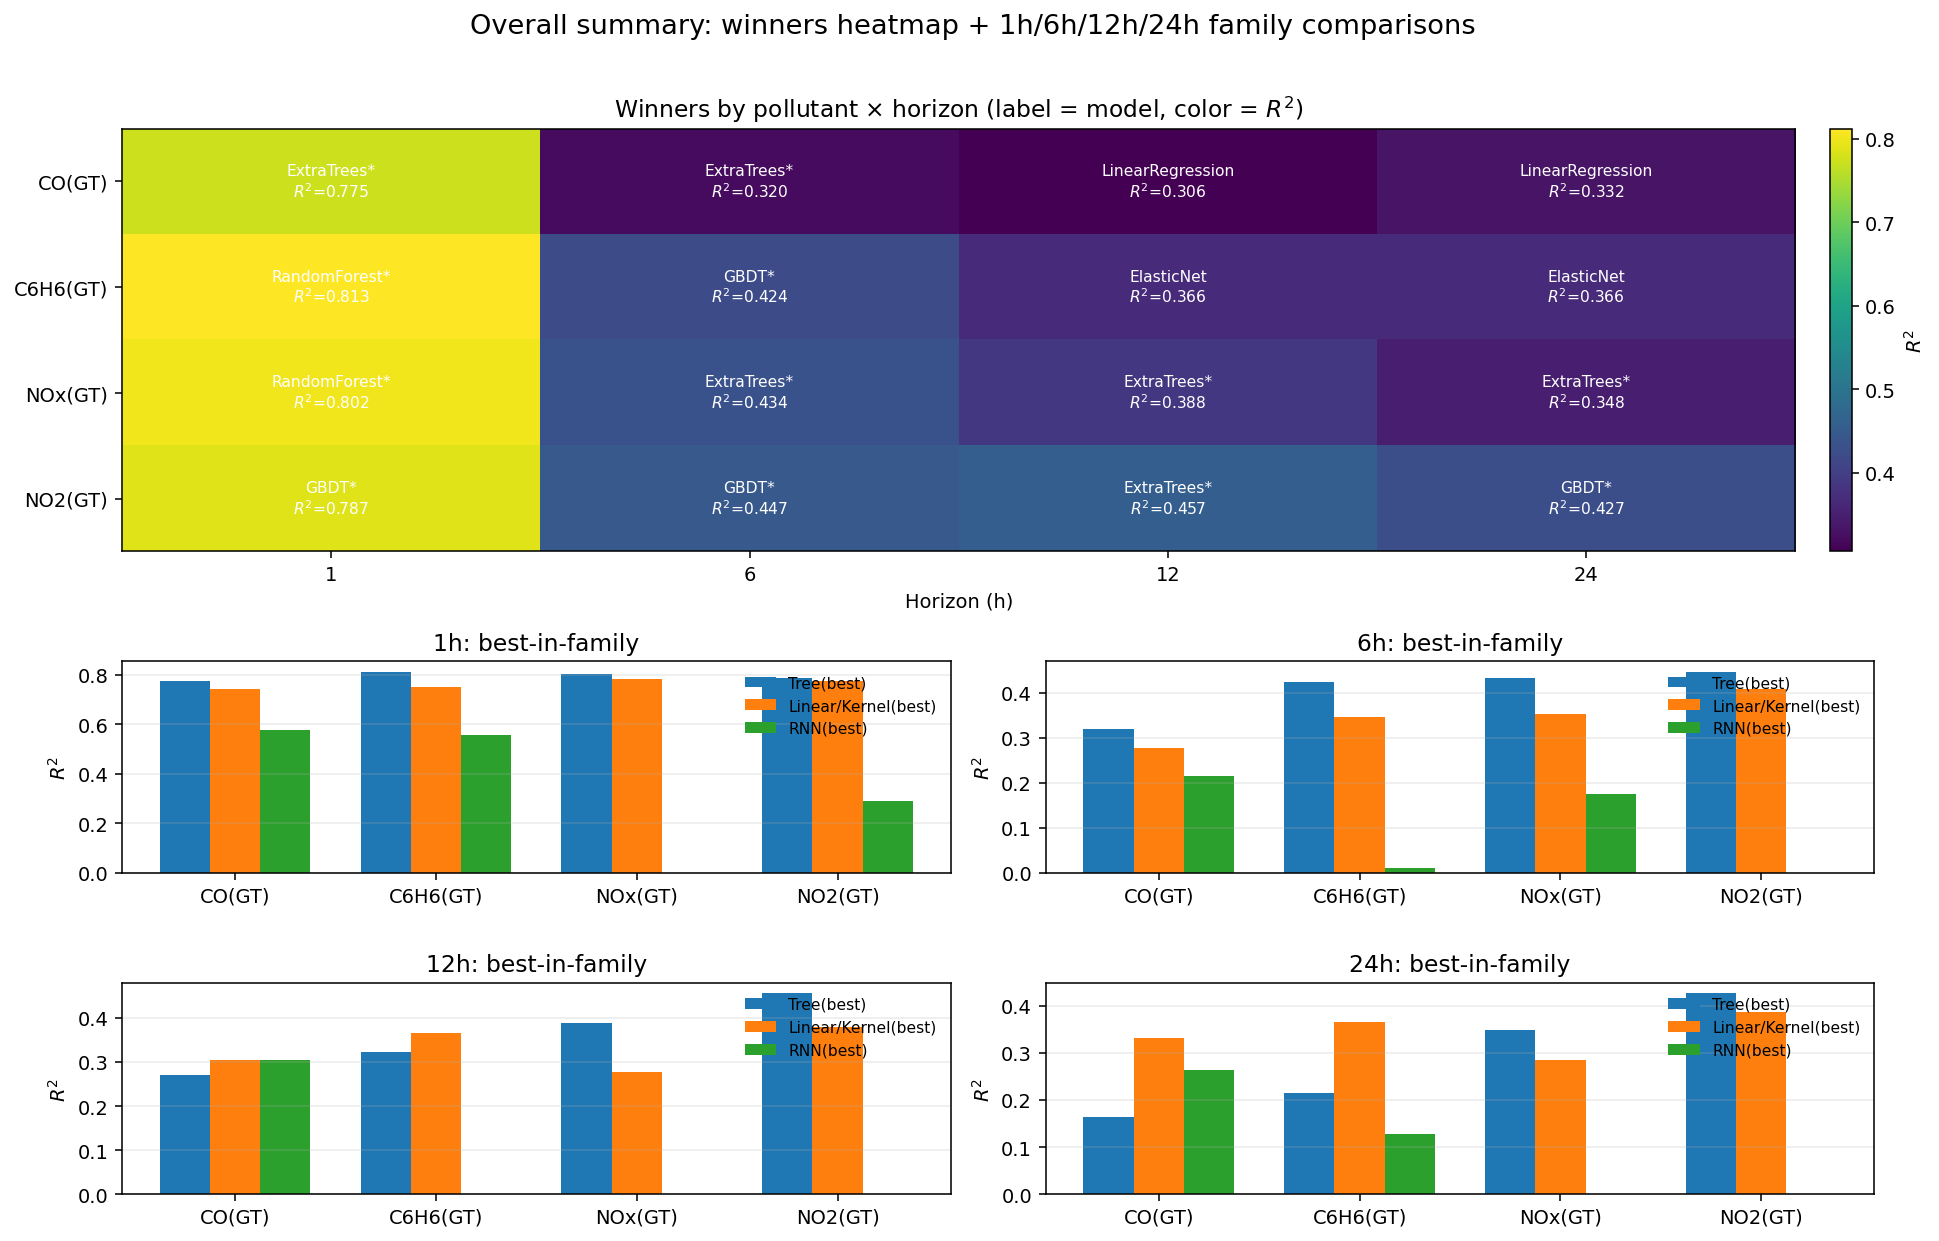

Saved figure: C:\Users\20100\Downloads\COMP9417_GoodJob-main\COMP9417_GoodJob-main\outputs\figures\final_overview.png


In [21]:
# ===== Merge all results (linear/trees/tuned_trees/mlp_svr/RNN) and plot compact dashboards =====
# - Scans outputs/results/*.csv and concatenates what exists
# - Produces one compact page with 3 panels:
#   Winners heatmap by pollutant × horizon (cell label = model, color = R²) and 1h/6h/12h/24h family bars

# - Saves to outputs/figures/final_overview.png and also shows inline

import numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

RESULTS_DIR = Path("outputs/results")
FIG_DIR     = Path("outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ---- Load & unify results (requires: model, pollutant, horizon_h, R2) ----
dfs = []
for p in sorted(RESULTS_DIR.glob("*.csv")):
    # (1) skip any tuned-tree CSVs
    if "tuned_tree_results" in p.name:
        continue
    try:
        df = pd.read_csv(p)
        need = {"model","pollutant","horizon_h","R2"}
        if need.issubset(df.columns):
            dfs.append(df[list(need)])
    except Exception:
        pass

if not dfs:
    raise RuntimeError("No usable baseline results found under outputs/results/*.csv")

allres = pd.concat(dfs, ignore_index=True).dropna(subset=["R2"])
# normalize horizon dtype
allres["horizon_h"] = allres["horizon_h"].astype(int)

# (2) drop any tuned rows if they slipped in from other files
mask_tuned = allres["model"].astype(str).str.contains("TUNED", case=False, na=False)
allres = allres[~mask_tuned].copy()

# ---- Canonical orders ----
POLLUTANTS = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']
HORIZONS   = [1, 6, 12, 24]

# ---- Model family mapper (unchanged style) ----
def family_of(model: str) -> str:
    m = str(model).lower()
    if any(k in m for k in ["randomforest","extratrees","xgboost","gbdt","gradientboost"]):
        return "Tree"
    if any(k in m for k in ["ridge","lasso","elastic","svr","linear","kernel","enet"]):
        return "Linear/Kernel"
    if "lstm" in m or "gru" in m:
        return "RNN"
    return "Other"

allres["family"] = allres["model"].map(family_of)

# ---- Winners per (pollutant, horizon) by R² ----
winners = (
    allres.sort_values("R2", ascending=False)
          .drop_duplicates(subset=["pollutant","horizon_h"])
)
heat = winners.pivot(index="pollutant", columns="horizon_h", values="R2").reindex(index=POLLUTANTS, columns=HORIZONS)
labmat = winners.pivot(index="pollutant", columns="horizon_h", values="model").reindex(index=POLLUTANTS, columns=HORIZONS)

def pretty_label(model, r2):
    if pd.isna(model) or pd.isna(r2): return ""
    star = "*" if family_of(model) == "Tree" else ""
    return f"{model}{star}\n$R^2$={r2:.3f}"

ann = pd.DataFrame(index=POLLUTANTS, columns=HORIZONS, dtype=object)
for r in POLLUTANTS:
    for c in HORIZONS:
        ann.loc[r,c] = pretty_label(labmat.loc[r,c], heat.loc[r,c])

# ---- Best-in-family bars per horizon ----
def best_family_r2_at(h):
    dfh = allres[allres["horizon_h"] == h].copy()
    g = dfh.groupby(["pollutant","family"])["R2"].max().unstack("family").fillna(np.nan)
    for col in ["Tree","Linear/Kernel","RNN"]:
        if col not in g.columns: g[col] = np.nan
    g = g[["Tree","Linear/Kernel","RNN"]].reindex(index=POLLUTANTS)
    return g

bars = {h: best_family_r2_at(h) for h in HORIZONS}

# ---- Plot (matplotlib only, unchanged) ----
plt.close("all")
fig = plt.figure(figsize=(14, 9), dpi=140)
gs  = GridSpec(nrows=3, ncols=4, height_ratios=[2.0, 1.0, 1.0], figure=fig)
fig.suptitle("Overall summary: winners heatmap + 1h/6h/12h/24h family comparisons", fontsize=14, y=0.98)

# Top heatmap
axH = fig.add_subplot(gs[0, :])
Z = heat.values.astype(float)
im = axH.imshow(Z, cmap="viridis", aspect="auto", vmin=np.nanmin(Z), vmax=np.nanmax(Z))
axH.set_xticks(range(len(HORIZONS))); axH.set_xticklabels(HORIZONS)
axH.set_yticks(range(len(POLLUTANTS))); axH.set_yticklabels(POLLUTANTS)
axH.set_xlabel("Horizon (h)")
axH.set_title("Winners by pollutant × horizon (label = model, color = $R^2$)")
for i, r in enumerate(POLLUTANTS):
    for j, h in enumerate(HORIZONS):
        txt = ann.loc[r, h]
        if txt:
            axH.text(j, i, txt, ha="center", va="center", color="white", fontsize=8, linespacing=1.2)
cbar = fig.colorbar(im, ax=axH, fraction=0.025, pad=0.02)
cbar.set_label("$R^2$")

# Bottom 2×2 bars
def draw_family_bars(ax, g, title):
    x = np.arange(len(POLLUTANTS))
    w = 0.25
    ax.bar(x - w, g["Tree"].values, width=w, label="Tree(best)")
    ax.bar(x,      g["Linear/Kernel"].values, width=w, label="Linear/Kernel(best)")
    ax.bar(x + w,  g["RNN"].values, width=w, label="RNN(best)")
    ax.set_xticks(x); ax.set_xticklabels(POLLUTANTS, rotation=0)
    ax.set_ylim(0, max(0.01, np.nanmax(g.values)) * 1.05)
    ax.set_ylabel("$R^2$")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(fontsize=8, loc="upper right", frameon=False)

ax11 = fig.add_subplot(gs[1, 0:2]); draw_family_bars(ax11, bars[1],  "1h: best-in-family")
ax12 = fig.add_subplot(gs[1, 2:4]); draw_family_bars(ax12, bars[6],  "6h: best-in-family")
ax21 = fig.add_subplot(gs[2, 0:2]); draw_family_bars(ax21, bars[12], "12h: best-in-family")
ax22 = fig.add_subplot(gs[2, 2:4]); draw_family_bars(ax22, bars[24], "24h: best-in-family")

plt.tight_layout(rect=[0, 0, 1, 0.97])
out_path = FIG_DIR / "final_overview.png"
plt.savefig(out_path, dpi=140)
plt.show()
print("Saved figure:", out_path.resolve())


In [22]:
# ===== Final pack-up: merge all results & export leaderboards (no retraining) =====
# - Automatically collect all result CSVs under outputs/results (tree/linear kernel/deep learning, etc.)
# - Standardize column names: ['model','pollutant','horizon_h','R2','RMSE','MAE','MAPE(%)']
# - Calculate three tables:
#   (A) overall_winners.csv        Winner list (select model with highest R2 for each pollutant×horizon)
#   (B) family_best_by_cell.csv    Family sub-ranking (family champion for Tree / LinearKernel / RNN in each cell)
#   (C) final_leaderboard.csv      Overall leaderboard (grouped by horizon, pollutant, R2 from high to low)
# - Only depends on pandas/numpy; no new third-party libraries

from pathlib import Path
import pandas as pd
import numpy as np

RES_DIR = Path("outputs/results")
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def load_all_results_baseline(res_dir: Path) -> pd.DataFrame:
    dfs = []
    for p in sorted(res_dir.glob("*.csv")):
        # skip tuned CSVs
        if "tuned_tree_results" in p.name:
            continue
        try:
            df = pd.read_csv(p)
        except Exception:
            continue
        need = ['model','pollutant','horizon_h','R2','RMSE','MAE','MAPE(%)']
        for c in need:
            if c not in df.columns:
                df[c] = np.nan
        df = df[need].copy()
        df['horizon_h'] = pd.to_numeric(df['horizon_h'], errors='coerce')
        df = df.dropna(subset=['model','pollutant','horizon_h','R2'])
        # drop tuned rows if any slipped in
        mask_tuned = df['model'].astype(str).str.contains('TUNED', case=False, na=False)
        df = df[~mask_tuned]
        dfs.append(df)
    if not dfs:
        raise RuntimeError(f"No baseline CSVs found under {res_dir.resolve()}")
    all_df = pd.concat(dfs, ignore_index=True)
    # de-dup: keep the highest R2 for the same (model, pollutant, horizon)
    all_df = (all_df.sort_values('R2', ascending=False)
                    .drop_duplicates(subset=['model','pollutant','horizon_h'], keep='first'))
    return all_df.reset_index(drop=True)

def model_family(name: str) -> str:
    n = name.lower()
    if any(k in n for k in ['lstm','gru']):
        return 'RNN'
    if any(k in n for k in ['randomforest','gbdt','xgboost','lightgbm','catboost','extratrees','extra trees']):
        return 'Tree'
    if any(k in n for k in ['svr','linear','ridge','lasso','elastic']):
        return 'Linear/Kernel'
    if any(k in n for k in ['forest','boost','tree']):
        return 'Tree'
    return 'Other'

# 1) Load and standardize
all_df = load_all_results_baseline(RES_DIR)
all_df['family'] = all_df['model'].astype(str).map(model_family)

# 2A) Overall winner for each cell
winners = (all_df.sort_values('R2', ascending=False)
                .groupby(['pollutant','horizon_h'], as_index=False)
                .first())
winners = winners[['pollutant','horizon_h','model','family','R2','RMSE','MAE','MAPE(%)']]

# 2B) Family sub-ranking per cell
def pick_family_best(df):
    out = []
    for fam in ['Tree','Linear/Kernel','RNN']:
        sub = df[df['family'] == fam]
        if not sub.empty:
            row = sub.sort_values('R2', ascending=False).iloc[0]
            out.append({'family': fam, 'model': row['model'], 'R2': row['R2'],
                        'RMSE': row['RMSE'], 'MAE': row['MAE'], 'MAPE(%)': row['MAPE(%)']})
    return pd.DataFrame(out)

family_rows = []
for (pol, h), g in all_df.groupby(['pollutant','horizon_h']):
    fam_best = pick_family_best(g)
    if not fam_best.empty:
        fam_best.insert(0, 'pollutant', pol)
        fam_best.insert(1, 'horizon_h', h)
        family_rows.append(fam_best)
family_best = pd.concat(family_rows, ignore_index=True) if family_rows else pd.DataFrame(
    columns=['pollutant','horizon_h','family','model','R2','RMSE','MAE','MAPE(%)'])

# 2C) Overall leaderboard
leaderboard = (all_df.sort_values(['horizon_h','pollutant','R2'], ascending=[True, True, False])
                    .reset_index(drop=True))

# 3) Export
csv_a = OUT_DIR / "overall_winners.csv"
csv_b = OUT_DIR / "family_best_by_cell.csv"
csv_c = OUT_DIR / "final_leaderboard.csv"
winners.to_csv(csv_a, index=False)
family_best.to_csv(csv_b, index=False)
leaderboard.to_csv(csv_c, index=False)

print("Saved:")
print(" -", csv_a.resolve())
print(" -", csv_b.resolve())
print(" -", csv_c.resolve())

# 4) Quick preview
print("\n[Overall winners — top 8]")
display(winners.sort_values(['horizon_h','pollutant']).head(8))
print("\n[Family best — head 12]")
display(family_best.sort_values(['horizon_h','pollutant','family']).head(12))
print("\n[Leaderboard — head 15]")
display(leaderboard.head(15))

Saved:
 - C:\Users\20100\Downloads\COMP9417_GoodJob-main\COMP9417_GoodJob-main\outputs\overall_winners.csv
 - C:\Users\20100\Downloads\COMP9417_GoodJob-main\COMP9417_GoodJob-main\outputs\family_best_by_cell.csv
 - C:\Users\20100\Downloads\COMP9417_GoodJob-main\COMP9417_GoodJob-main\outputs\final_leaderboard.csv

[Overall winners — top 8]


,pollutant,horizon_h,model,family,R2,RMSE,MAE,MAPE(%)
0,C6H6(GT),1,RandomForest,Tree,0.812530,2.760255,1.822578,32.725604
4,CO(GT),1,ExtraTrees,Tree,0.774824,0.627031,0.451796,41.455784
8,NO2(GT),1,GBDT,Tree,0.786805,23.048229,17.001674,14.248783
12,NOx(GT),1,RandomForest,Tree,0.801865,86.881022,63.396695,26.117625
1,C6H6(GT),6,GBDT,Tree,0.424390,4.841520,3.796393,94.743004
5,CO(GT),6,ExtraTrees,Tree,0.320027,1.090656,0.828499,81.378762
9,NO2(GT),6,GBDT,Tree,0.447380,37.136332,29.193226,24.441853
13,NOx(GT),6,ExtraTrees,Tree,0.433841,146.987610,107.957520,44.081687



[Family best — head 12]


,pollutant,horizon_h,family,model,R2,RMSE,MAE,MAPE(%)
1,C6H6(GT),1,Linear/Kernel,Lasso,0.750141,3.186626,2.248035,47.858338
2,C6H6(GT),1,RNN,LSTM,0.555020,4.269149,3.357182,96.243320
0,C6H6(GT),1,Tree,RandomForest,0.812530,2.760255,1.822578,32.725604
13,CO(GT),1,Linear/Kernel,Lasso,0.740870,0.672647,0.508094,45.270258
14,CO(GT),1,RNN,LSTM,0.577879,0.861199,0.640555,60.674635
12,CO(GT),1,Tree,ExtraTrees,0.774824,0.627031,0.451796,41.455784
25,NO2(GT),1,Linear/Kernel,Lasso,0.774552,23.701310,17.821535,15.340751
26,NO2(GT),1,RNN,LSTM,0.291665,42.149540,31.563740,21.808610
24,NO2(GT),1,Tree,GBDT,0.786805,23.048229,17.001674,14.248783
37,NOx(GT),1,Linear/Kernel,Ridge,0.782484,91.030923,65.270028,27.410946



[Leaderboard — head 15]


,model,pollutant,horizon_h,R2,RMSE,MAE,MAPE(%),family
0,RandomForest,C6H6(GT),1,0.812530,2.760255,1.822578,32.725604,Tree
1,ExtraTrees,C6H6(GT),1,0.811008,2.771435,1.818978,32.561166,Tree
2,GBDT,C6H6(GT),1,0.799863,2.851981,1.952739,40.718724,Tree
3,Lasso,C6H6(GT),1,0.750141,3.186626,2.248035,47.858338,Linear/Kernel
4,ElasticNet,C6H6(GT),1,0.743112,3.231134,2.329300,48.466935,Linear/Kernel
5,MLP,C6H6(GT),1,0.733092,3.293550,2.458671,51.400953,Other
6,Ridge,C6H6(GT),1,0.727686,3.326733,2.473043,52.394089,Linear/Kernel
7,LinearRegression,C6H6(GT),1,0.716923,3.391844,2.525410,54.863466,Linear/Kernel
8,LinearSVR,C6H6(GT),1,0.712422,3.418703,2.581479,55.617118,Linear/Kernel
9,DecisionTree,C6H6(GT),1,0.634231,3.855553,2.444425,38.331774,Tree


Using merged results from: outputs\results\all_results_merged.csv
Total rows in merged file       : 195
Rows kept after filtering models: 179
Models included: ['DecisionTree', 'ElasticNet', 'ExtraTrees', 'GBDT', 'Lasso', 'LinearRegression', 'LinearSVR', 'MLP', 'RandomForest', 'Ridge']

[Average by pollutant]  


,pollutant,R2_mean,R2_std,RMSE_mean,RMSE_std,MAE_mean,MAE_std
0,NO2(GT),0.412173,0.250092,37.398942,8.510522,28.753669,6.911253
1,NOx(GT),0.337008,0.312956,154.203948,39.809303,112.458409,30.205256
2,CO(GT),0.252245,0.402352,1.105571,0.300819,0.857357,0.245289
3,C6H6(GT),0.141856,0.869605,5.500913,2.212137,4.226578,1.877387



[Average by horizon]    


,horizon_h,R2_mean,R2_std,RMSE_mean,RMSE_std,MAE_mean,MAE_std
0,1,0.739397,0.080801,31.323593,40.014652,22.457410,28.227601
1,6,0.191790,0.391607,53.904528,69.205725,40.566691,51.427168
2,12,0.189426,0.273470,55.820878,72.433334,40.876655,52.164978
3,24,0.022668,0.764697,57.160375,73.122674,42.395258,53.636604


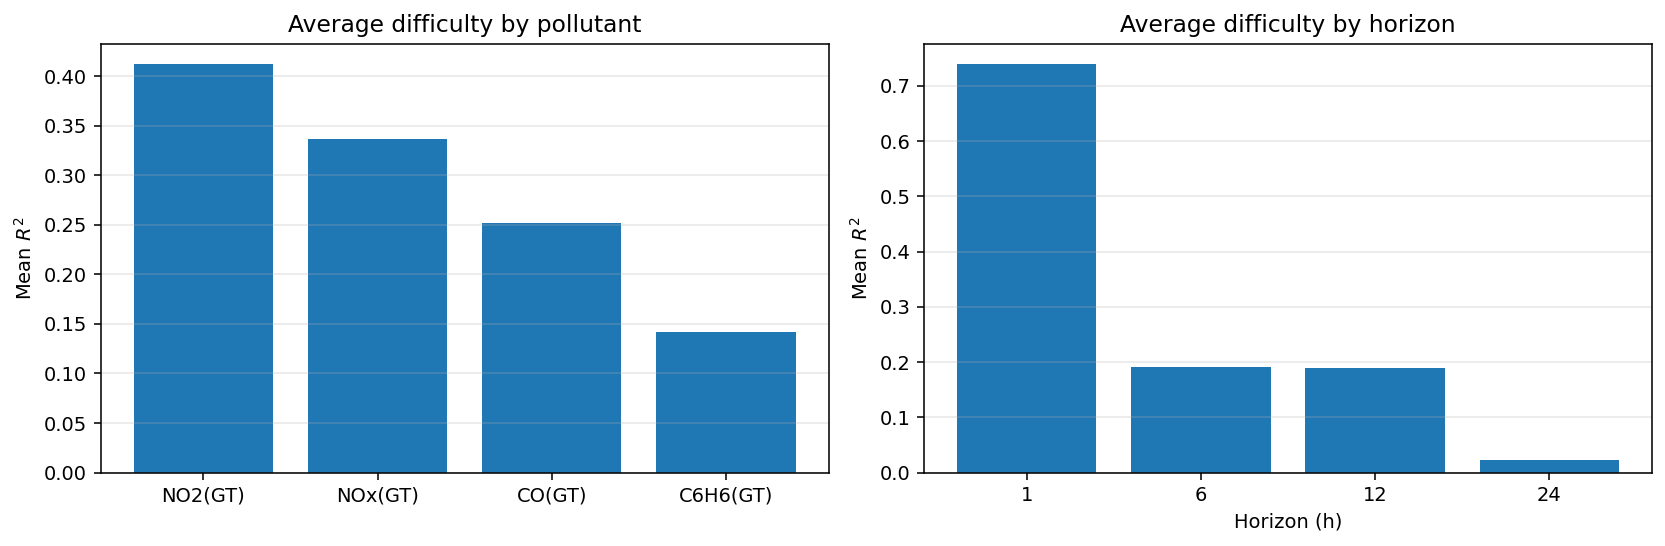

Saved figure: C:\Users\20100\Downloads\COMP9417_GoodJob-main\COMP9417_GoodJob-main\chenghao-regression\outputs\figures\avg_difficulty_from_merged_filtered.png


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===== 1) Load merged results from CSV =====
candidate_paths = [
    Path("outputs/results/all_results_merged.csv"),
    Path("outputs") / "results" / "all_results_merged.csv",
    Path("all_results_merged.csv"),
]

csv_path = None
for p in candidate_paths:
    if p.is_file():
        csv_path = p
        break

if csv_path is None:
    raise RuntimeError(
        "Could not find all_results_merged.csv. "
        "Make sure the merge cell saved it under outputs/results/."
    )

print(f"Using merged results from: {csv_path}")
allres = pd.read_csv(csv_path)

# ===== 2) Keep only needed columns and clean basic types =====
# Adjust column name for horizon if needed
if "horizon_h" in allres.columns:
    horizon_col = "horizon_h"
elif "horizon" in allres.columns:
    horizon_col = "horizon"
else:
    raise RuntimeError("No horizon column found (expected 'horizon_h' or 'horizon').")

needed = ["model", "pollutant", horizon_col, "R2", "RMSE", "MAE"]
missing = [c for c in needed if c not in allres.columns]
if missing:
    raise RuntimeError(f"Merged results are missing columns: {missing}")

allres = allres[needed].copy()
allres.rename(columns={horizon_col: "horizon_h"}, inplace=True)
allres["horizon_h"] = pd.to_numeric(allres["horizon_h"], errors="coerce")

# Drop rows with invalid keys or missing R2
allres = allres.dropna(subset=["pollutant", "horizon_h", "R2"])

# ===== 3) Filter out naive/baseline and RNN models =====
model_str = allres["model"].astype(str)

mask_naive = model_str.str.contains("naive", case=False) | model_str.str.contains("baseline", case=False)
mask_rnn   = model_str.str.contains("lstm", case=False)  | model_str.str.contains("gru", case=False)

filtered = allres[~(mask_naive | mask_rnn)].copy()

print(f"Total rows in merged file       : {len(allres)}")
print(f"Rows kept after filtering models: {len(filtered)}")
print("Models included:", sorted(filtered["model"].astype(str).unique()))

# If the same (model, pollutant, horizon) appears multiple times,
# keep the row with the highest R2
filtered = (
    filtered.sort_values("R2", ascending=False)
            .drop_duplicates(subset=["model", "pollutant", "horizon_h"], keep="first")
)

# ===== 4) Aggregate by pollutant and by horizon =====
agg = {"R2": ["mean", "std"], "RMSE": ["mean", "std"], "MAE": ["mean", "std"]}

# (A) Average over models and horizons, grouped by pollutant
avg_by_pollutant = filtered.groupby("pollutant", as_index=False).agg(agg)
avg_by_pollutant.columns = ["pollutant"] + [
    f"{m}_{s}" for m in ["R2", "RMSE", "MAE"] for s in ["mean", "std"]
]
avg_by_pollutant = (
    avg_by_pollutant
    .sort_values("R2_mean", ascending=False)
    .reset_index(drop=True)
)

# (B) Average over models and pollutants, grouped by horizon
avg_by_horizon = filtered.groupby("horizon_h", as_index=False).agg(agg)
avg_by_horizon.columns = ["horizon_h"] + [
    f"{m}_{s}" for m in ["R2", "RMSE", "MAE"] for s in ["mean", "std"]
]
avg_by_horizon = (
    avg_by_horizon
    .sort_values("horizon_h")
    .reset_index(drop=True)
)

# ===== 5) Save tables and plot bar charts =====
OUT_DIR = Path("outputs")
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

avg_by_pollutant.to_csv(OUT_DIR / "avg_by_pollutant.csv", index=False)
avg_by_horizon.to_csv(OUT_DIR / "avg_by_horizon.csv", index=False)

print("\n[Average by pollutant]  ")
display(avg_by_pollutant)

print("\n[Average by horizon]    ")
display(avg_by_horizon)

plt.close("all")
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=140)

# (A) Average R^2 by pollutant
axes[0].bar(avg_by_pollutant["pollutant"], avg_by_pollutant["R2_mean"])
axes[0].set_title("Average difficulty by pollutant")
axes[0].set_ylabel("Mean $R^2$")
axes[0].set_ylim(0, max(0.01, avg_by_pollutant["R2_mean"].max()) * 1.05)
axes[0].grid(axis="y", alpha=0.3)

# (B) Average R^2 by horizon
axes[1].bar(avg_by_horizon["horizon_h"].astype(str), avg_by_horizon["R2_mean"])
axes[1].set_title("Average difficulty by horizon")
axes[1].set_xlabel("Horizon (h)")
axes[1].set_ylabel("Mean $R^2$")
axes[1].set_ylim(0, max(0.01, avg_by_horizon["R2_mean"].max()) * 1.05)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
out_fig = FIG_DIR / "avg_difficulty_from_merged_filtered.png"
plt.savefig(out_fig, dpi=160)
plt.show()
print("Saved figure:", out_fig.resolve())

In [29]:
from pathlib import Path
import pandas as pd
import numpy as np

# ===== 1) Load merged results =====
candidate_paths = [
    Path("outputs/results/all_results_merged.csv"),
    Path("outputs") / "results" / "all_results_merged.csv",
    Path("all_results_merged.csv"),
]

csv_path = None
for p in candidate_paths:
    if p.is_file():
        csv_path = p
        break

if csv_path is None:
    raise RuntimeError(
        "Could not find all_results_merged.csv. "
        "Make sure the merge cell saved it under outputs/results/."
    )

print(f"Using merged results from: {csv_path}")
res = pd.read_csv(csv_path)

# ----- keep only needed columns -----
if "horizon_h" in res.columns:
    horizon_col = "horizon_h"
elif "horizon" in res.columns:
    horizon_col = "horizon"
else:
    raise RuntimeError("No horizon column found (expected 'horizon_h' or 'horizon').")

needed = ["model", "pollutant", horizon_col, "R2", "RMSE", "MAE"]
missing = [c for c in needed if c not in res.columns]
if missing:
    raise RuntimeError(f"Merged results are missing columns: {missing}")

res = res[needed].copy()
res.rename(columns={horizon_col: "horizon_h"}, inplace=True)

res["horizon_h"] = pd.to_numeric(res["horizon_h"], errors="coerce")
res = res.dropna(subset=["pollutant", "horizon_h", "R2"])

# ===== 2) Filter models (drop RNN; keep naive/baseline as one model) =====
model_str = res["model"].astype(str)

mask_rnn = model_str.str.contains("lstm", case=False) | model_str.str.contains("gru", case=False)
# If you also want to exclude naive/baseline everywhere, uncomment the next line:
# mask_rnn = mask_rnn | model_str.str.contains("naive", case=False) | model_str.str.contains("baseline", case=False)

res_f = res[~mask_rnn].copy()

# If the same (model, pollutant, horizon) appears multiple times,
# keep the row with the highest R2
res_f = (
    res_f.sort_values("R2", ascending=False)
         .drop_duplicates(subset=["model", "pollutant", "horizon_h"], keep="first")
)

print(f"Total rows after filtering: {len(res_f)}")
print("Models included:", sorted(res_f["model"].astype(str).unique()))

# ===== 3) Best model for each pollutant & horizon =====
best_idx = res_f.groupby(["pollutant", "horizon_h"])["R2"].idxmax()
best_per_ph = res_f.loc[best_idx].copy()

print("\n1. Best model for each pollutant:")
print("-" * 80)

for pol in sorted(best_per_ph["pollutant"].unique()):
    print(f"\n{pol}:")
    sub = best_per_ph[best_per_ph["pollutant"] == pol].sort_values("horizon_h")
    for _, row in sub.iterrows():
        h = int(row["horizon_h"])
        print(
            f"  {h}h: {row['model']} "
            f"(RMSE: {row['RMSE']:.4f}, R²: {row['R2']:.4f})"
        )

# ===== 4) Average performance per model (across pollutants & horizons) =====
avg_by_model = (
    res_f.groupby("model", as_index=False)[["RMSE", "MAE", "R2"]]
         .mean()
         .sort_values("R2", ascending=False)
         .reset_index(drop=True)
)

print("\n2. Average model performance (across all pollutants and horizons):")
print("-" * 80)
print(avg_by_model.set_index("model"))

Using merged results from: outputs\results\all_results_merged.csv
Total rows after filtering: 176
Models included: ['DecisionTree', 'ElasticNet', 'ExtraTrees', 'GBDT', 'Lasso', 'LinearRegression', 'LinearSVR', 'MLP', 'Naive', 'RandomForest', 'Ridge']

1. Best model for each pollutant:
--------------------------------------------------------------------------------

C6H6(GT):
  1h: RandomForest (RMSE: 2.7603, R²: 0.8125)
  6h: GBDT (RMSE: 4.8415, R²: 0.4244)
  12h: ElasticNet (RMSE: 5.0842, R²: 0.3662)
  24h: ElasticNet (RMSE: 5.0977, R²: 0.3655)

CO(GT):
  1h: ExtraTrees (RMSE: 0.6270, R²: 0.7748)
  6h: ExtraTrees (RMSE: 1.0907, R²: 0.3200)
  12h: LinearRegression (RMSE: 1.1030, R²: 0.3058)
  24h: LinearRegression (RMSE: 1.0833, R²: 0.3321)

NO2(GT):
  1h: GBDT (RMSE: 23.0482, R²: 0.7868)
  6h: GBDT (RMSE: 37.1363, R²: 0.4474)
  12h: ExtraTrees (RMSE: 36.8259, R²: 0.4569)
  24h: GBDT (RMSE: 37.9008, R²: 0.4273)

NOx(GT):
  1h: RandomForest (RMSE: 86.8810, R²: 0.8019)
  6h: ExtraTrees (